In [ ]:
# ══════════════════════════════════════════════════════════════
# P2M — STREAMLIT APP + SYNTHETIC DATA
# Notebook dédié : application dashboard + données synthétiques
# Prérequis : modèles entraînés dans P2M_Finale.ipynb
#             et sauvegardés sur Drive
# ══════════════════════════════════════════════════════════════

# ── 1. Installer les dépendances ──────────────────────────────
!pip install streamlit pyngrok xgboost lightgbm torch -q

# ── 2. Monter Drive ───────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ── 3. Vérifier que les modèles sont bien présents ────────────
import os

DRIVE_ROOT = '/content/drive/MyDrive'
DRIVE_P2M  = '/content/drive/MyDrive/P2M_Models'

fichiers_requis = {
    'Isolation Forest'   : f'{DRIVE_P2M}/isolation_forest.pkl',
    'Random Forest'      : f'{DRIVE_P2M}/random_forest.pkl',
    'XGBoost DCR'        : f'{DRIVE_ROOT}/xgboost_dcr_v3.json',
    'XGBoost Thrp DL'    : f'{DRIVE_P2M}/Thrp_DLUL_v2/xgb_DL.json',
    'XGBoost Thrp UL'    : f'{DRIVE_P2M}/Thrp_DLUL_v2/xgb_UL.json',
    'LightGBM RRC'       : f'{DRIVE_ROOT}/lightgbm_rrc_sr_v2.pkl',
    'Autoencoder LSTM'   : f'{DRIVE_P2M}/Autoencoder_LSTM/lstm_ae.pth',
    'df_alerting_complet': f'{DRIVE_P2M}/Alerting/df_alerting_complet.csv',
    'cell_alert_summary' : f'{DRIVE_P2M}/Alerting/cell_alert_summary.csv',
    'cell_health_scores' : f'{DRIVE_P2M}/HealthScore/cell_health_scores.csv',
}

print("═" * 55)
print("  VÉRIFICATION DES MODÈLES SUR DRIVE")
print("═" * 55)
all_ok = True
for nom, path in fichiers_requis.items():
    ok   = os.path.exists(path)
    size = os.path.getsize(path)/1024/1024 if ok else 0
    print(f"  {'✅' if ok else '❌'} {nom:25s} {size:.1f} Mo")
    if not ok: all_ok = False

print(f"\n{'✅ Tous les modèles sont prêts !' if all_ok else '❌ Des modèles manquent — vérifie P2M_Finale.ipynb'}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
═══════════════════════════════════════════════════════
  VÉRIFICATION DES MODÈLES SUR DRIVE
═══════════════════════════════════════════════════════
  ✅ Isolation Forest          1.1 Mo
  ✅ Random Forest             121.7 Mo
  ✅ XGBoost DCR               0.5 Mo
  ✅ XGBoost Thrp DL           1.7 Mo
  ✅ XGBoost Thrp UL           2.1 Mo
  ✅ LightGBM RRC              2.1 Mo
  ✅ Autoencoder LSTM          0.5 Mo
  ✅ df_alerting_complet       420.5 Mo
  ✅ cell_alert_summary        1.3 Mo
  ✅ cell_health_scores        3.2 Mo

✅ Tous les modèles sont prêts !


In [ ]:
# ── Imports utilisés dans tout le notebook ────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, json, os, shutil, time
import torch
import torch.nn as nn
import xgboost as xgb
from sklearn.metrics import (precision_score, recall_score,
                             f1_score, confusion_matrix)
import warnings
warnings.filterwarnings('ignore')

# ── Constantes globales ───────────────────────────────────────
DRIVE_ROOT  = '/content/drive/MyDrive'
DRIVE_P2M   = '/content/drive/MyDrive/P2M_Models'
DRIVE_THRP  = f'{DRIVE_P2M}/Thrp_DLUL_v2'
DRIVE_AE    = f'{DRIVE_P2M}/Autoencoder_LSTM'
DRIVE_SYNTH = f'{DRIVE_P2M}/Synthetic'
APP_BASE    = '/content/p2m_network_app'
APP_DATA    = f'{APP_BASE}/data'

KPI_COLS = [
    'KPI_RRC_SR','KPI_DCR','KPI_ERAB_SR',
    'KPI_Thrp_DL_Mbps','KPI_Thrp_UL_Mbps',
    'KPI_HOSR','KPI_HOSR_InterFreq',
    'KPI_HOSR_InterRAT','Cell_Availability','CSFB_SR'
]

os.makedirs(DRIVE_SYNTH, exist_ok=True)
os.makedirs(APP_DATA,    exist_ok=True)

print("✅ Imports et constantes OK")

✅ Imports et constantes OK


In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL SYN-1 — GÉNÉRATEUR SYNTHÉTIQUE RÉSEAU TUNISIEN
# Sites réels, villes tunisiennes, patterns trafic réalistes
# ══════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np

np.random.seed(42)

# ── Configuration réseau tunisien ─────────────────────────────
OPERATEUR  = 'OOR'   # Ooredoo Tunisie (changer en TT_ ou ORG_ si besoin)
START_DATE = '2025-06-01'
N_HOURS    = 168     # 7 jours

# ── Sites par ville tunisienne ────────────────────────────────
SITES = {
    # (ville, site_name, type_zone, nb_cellules)
    'Tunis': [
        ('TUN_CENTRE',      'urbain_dense', 3),
        ('TUN_BARDO',       'urbain',       3),
        ('TUN_LAC2',        'urbain_dense', 3),
        ('TUN_ARIANA',      'urbain',       3),
        ('TUN_MENZAH',      'residentiel',  2),
    ],
    'Sfax': [
        ('SFX_CENTRE',      'urbain',       3),
        ('SFX_SAKIET',      'urbain',       2),
        ('SFX_ROUTE_TUNIS', 'axe_routier',  2),
    ],
    'Sousse': [
        ('SOU_CENTRE',      'urbain',       3),
        ('SOU_CORNICHE',    'touristique',  3),
        ('SOU_KHEZAMA',     'residentiel',  2),
    ],
    'Monastir': [
        ('MON_AEROPORT',    'aeroport',     2),
        ('MON_CENTRE',      'urbain',       2),
    ],
    'Nabeul': [
        ('NAB_HAMMAMET',    'touristique',  3),
        ('NAB_CENTRE',      'urbain',       2),
    ],
    'Bizerte': [
        ('BIZ_CENTRE',      'urbain',       2),
        ('BIZ_PORT',        'industriel',   2),
    ],
    'Gabes': [
        ('GAB_CENTRE',      'urbain',       2),
        ('GAB_ZONE_IND',    'industriel',   2),
    ],
    'Kairouan': [
        ('KAI_CENTRE',      'urbain',       2),
        ('KAI_NORD',        'residentiel',  2),
    ],
}

# ── Profils KPI par type de zone ──────────────────────────────
# (mu_RRC, mu_DCR, mu_ERAB, mu_ThrpDL, mu_ThrpUL, mu_HOSR)
PROFILS_ZONE = {
    'urbain_dense' : (99.2, 0.15, 99.1, 12.0, 2.5, 99.5),
    'urbain'       : (99.5, 0.08, 99.4, 15.0, 3.0, 99.7),
    'residentiel'  : (99.7, 0.04, 99.6, 18.0, 4.0, 99.8),
    'touristique'  : (99.3, 0.12, 99.2, 14.0, 3.0, 99.6),
    'aeroport'     : (99.6, 0.06, 99.5, 20.0, 5.0, 99.8),
    'axe_routier'  : (98.5, 0.25, 98.3, 10.0, 2.0, 97.0),
    'industriel'   : (99.0, 0.10, 98.9, 11.0, 2.2, 99.2),
}

# ── Pattern trafic tunisien (facteur multiplicatif/heure) ─────
# Heure creuse nuit, rush matin 8h, rush soir 18h-21h, pic ramadan 22h-2h
def get_trafic_factor(hour, month=6):
    # Ramadan (approximation juin pour l'exemple)
    ramadan = (month == 3)
    if ramadan:
        if 0 <= hour < 3:    return 1.4   # Suhur — pic nuit
        elif 3 <= hour < 6:  return 0.6
        elif 6 <= hour < 9:  return 0.8
        elif 9 <= hour < 12: return 1.0
        elif 12 <= hour < 15:return 0.9
        elif 15 <= hour < 18:return 1.1
        elif 18 <= hour < 21:return 1.5   # Iftar — pic majeur
        elif 21 <= hour < 24:return 1.6
    else:
        # Journée normale
        if 0 <= hour < 6:    return 0.3
        elif 6 <= hour < 8:  return 0.7
        elif 8 <= hour < 12: return 1.2   # rush matin
        elif 12 <= hour < 14:return 1.1   # déjeuner
        elif 14 <= hour < 17:return 1.0
        elif 17 <= hour < 20:return 1.3   # rush soir
        elif 20 <= hour < 23:return 1.2   # prime time
        else:                return 0.5
    return 1.0

# ── Incidents injectés (scénarios tunisiens réalistes) ────────
# (site, cellule_idx, h_debut, h_fin, type_incident, cause)
INCIDENTS = [
    # Tunis Centre — congestion heure de pointe vendredi soir
    ('TUN_CENTRE', 1,  89,  96, 'Congestion_Radio',      'Rush vendredi soir Tunis'),
    ('TUN_CENTRE', 2,  89,  96, 'Congestion_Radio',      'Rush vendredi soir Tunis'),
    # Lac2 — problème fibre backhaul
    ('TUN_LAC2',   1,  24,  31, 'Problème_Cœur_Réseau',  'Coupure fibre backhaul'),
    # Axe routier Sfax-Tunis — handover raté camions
    ('SFX_ROUTE_TUNIS', 1, 48, 60, 'Echec_Handover',     'Mobilité haute vitesse'),
    # Sousse Corniche — surcharge touristique été
    ('SOU_CORNICHE', 1, 72,  96, 'Congestion_Radio',     'Afflux touristes côte'),
    ('SOU_CORNICHE', 2, 72,  96, 'Congestion_Radio',     'Afflux touristes côte'),
    # Monastir Aéroport — outage partiel alimentation
    ('MON_AEROPORT', 1, 36,  42, 'Risque_Outage',        'Micro-coupure électrique'),
    # Hammamet — interférence équipement voisin
    ('NAB_HAMMAMET', 2, 60,  75, 'Interférence_Radio',   'Interférence équipement'),
    # Bizerte Port — zone industrielle bruit RF
    ('BIZ_PORT',     1, 100, 115, 'Interférence_Radio',  'Bruit RF zone portuaire'),
    # Gabes Zone industrielle — dégradation ERAB
    ('GAB_ZONE_IND', 1, 120, 132, 'Problème_Cœur_Réseau','SGW surchargé'),
    # Kairouan — HO inter-RAT 2G/4G
    ('KAI_CENTRE',   1, 80,  92, 'Echec_Handover',       'HO inter-RAT 2G/4G'),
    # Ariana — congestion match foot
    ('TUN_ARIANA',   1, 140, 147, 'Congestion_Radio',    'Match Espérance Tunis'),
]

# ══════════════════════════════════════════════════════════════
# GÉNÉRATION
# ══════════════════════════════════════════════════════════════
def kpis_normaux(n, profil, trafic_factors):
    mu_rrc, mu_dcr, mu_erab, mu_dl, mu_ul, mu_hosr = profil
    kpis = {}
    for h in range(n):
        tf = trafic_factors[h]
        # Plus de trafic → légère dégradation DCR, débit variable
        kpis.setdefault('KPI_RRC_SR',        []).append(
            np.clip(np.random.normal(mu_rrc - 0.1*(tf-1), 0.2), 95, 100))
        kpis.setdefault('KPI_DCR',           []).append(
            np.clip(np.random.normal(mu_dcr * tf, 0.03), 0, 2))
        kpis.setdefault('KPI_ERAB_SR',       []).append(
            np.clip(np.random.normal(mu_erab - 0.1*(tf-1), 0.25), 95, 100))
        kpis.setdefault('KPI_Thrp_DL_Mbps',  []).append(
            np.clip(np.random.normal(mu_dl / tf, 2), 1, 40))
        kpis.setdefault('KPI_Thrp_UL_Mbps',  []).append(
            np.clip(np.random.normal(mu_ul / tf, 0.5), 0.2, 10))
        kpis.setdefault('KPI_HOSR',          []).append(
            np.clip(np.random.normal(mu_hosr, 0.15), 95, 100))
        kpis.setdefault('KPI_HOSR_InterFreq',[]).append(
            np.clip(np.random.normal(mu_hosr - 0.3, 0.2), 93, 100))
        kpis.setdefault('KPI_HOSR_InterRAT', []).append(
            np.clip(np.random.normal(97.5, 0.5), 92, 100))
        kpis.setdefault('Cell_Availability', []).append(
            np.clip(np.random.normal(99.9, 0.05), 99, 100))
        kpis.setdefault('CSFB_SR',           []).append(
            np.clip(np.random.normal(98.5, 0.4), 96, 100))
    return {k: np.array(v) for k, v in kpis.items()}

def degrader(kpis, inc_type, h, intensite):
    k = {key: val[h] for key, val in kpis.items()}
    if inc_type == 'Congestion_Radio':
        k['KPI_DCR']          += np.random.normal(4.0*intensite, 0.4)
        k['KPI_Thrp_DL_Mbps'] -= np.random.normal(7.0*intensite, 1.0)
        k['KPI_Thrp_UL_Mbps'] -= np.random.normal(1.5*intensite, 0.2)
        k['KPI_ERAB_SR']      -= np.random.normal(1.5*intensite, 0.2)
    elif inc_type == 'Echec_Handover':
        k['KPI_HOSR']          -= np.random.normal(12.0*intensite, 2.0)
        k['KPI_HOSR_InterFreq']-= np.random.normal(14.0*intensite, 2.5)
        k['KPI_HOSR_InterRAT'] -= np.random.normal(10.0*intensite, 2.0)
        k['KPI_DCR']           += np.random.normal(2.0*intensite, 0.3)
    elif inc_type == 'Problème_Cœur_Réseau':
        k['KPI_ERAB_SR']      -= np.random.normal(6.0*intensite, 0.8)
        k['KPI_Thrp_DL_Mbps'] -= np.random.normal(5.0*intensite, 0.8)
        k['KPI_DCR']          += np.random.normal(1.0*intensite, 0.2)
    elif inc_type == 'Risque_Outage':
        k['Cell_Availability'] -= np.random.normal(7.0*intensite, 1.0)
        k['KPI_RRC_SR']        -= np.random.normal(8.0*intensite, 1.5)
        k['KPI_DCR']           += np.random.normal(6.0*intensite, 0.8)
        k['KPI_Thrp_DL_Mbps']  -= np.random.normal(10.0*intensite, 1.5)
    elif inc_type == 'Interférence_Radio':
        k['KPI_RRC_SR']        -= np.random.normal(5.0*intensite, 0.8)
        k['KPI_HOSR_InterFreq']-= np.random.normal(6.0*intensite, 1.0)

    # Clip réaliste
    clips = {
        'KPI_RRC_SR':(80,100),'KPI_DCR':(0,20),'KPI_ERAB_SR':(80,100),
        'KPI_Thrp_DL_Mbps':(0.1,40),'KPI_Thrp_UL_Mbps':(0.1,10),
        'KPI_HOSR':(65,100),'KPI_HOSR_InterFreq':(65,100),
        'KPI_HOSR_InterRAT':(65,100),'Cell_Availability':(80,100),'CSFB_SR':(85,100),
    }
    for col,(lo,hi) in clips.items():
        k[col] = np.clip(k[col], lo, hi)
    return k

# ── Génération principale ─────────────────────────────────────
print("⏳ Génération dataset synthétique tunisien...")
timestamps      = pd.date_range(start=START_DATE, periods=N_HOURS, freq='h')
trafic_factors  = [get_trafic_factor(ts.hour, ts.month) for ts in timestamps]
rows = []

for ville, sites_ville in SITES.items():
    for (site_name, zone_type, n_cells) in sites_ville:
        profil = PROFILS_ZONE[zone_type]

        for c_idx in range(1, n_cells + 1):
            cell_name     = f'{site_name}_e{c_idx}'
            function_name = f'{site_name}_L'

            # KPIs normaux
            kpis = kpis_normaux(N_HOURS, profil, trafic_factors)

            # Injecter incidents
            for (site, cidx, h_s, h_e, inc_type, cause) in INCIDENTS:
                if site == site_name and cidx == c_idx:
                    n_inc = h_e - h_s
                    for h in range(h_s, min(h_e, N_HOURS)):
                        progress = (h - h_s) / max(n_inc - 1, 1)
                        if progress < 0.25:   intensite = progress / 0.25
                        elif progress > 0.75: intensite = (1-progress) / 0.25
                        else:                 intensite = 1.0
                        k_deg = degrader(kpis, inc_type, h, intensite)
                        for key in kpis:
                            kpis[key][h] = k_deg[key]

            for h in range(N_HOURS):
                rows.append({
                    'Time'                 : timestamps[h],
                    'eNodeB_Name'          : site_name,
                    'Cell_Name'            : cell_name,
                    'eNodeB_Function_Name' : function_name,
                    'Ville'                : ville,
                    'Zone_Type'            : zone_type,
                    'KPI_RRC_SR'           : round(kpis['KPI_RRC_SR'][h], 6),
                    'KPI_DCR'              : round(kpis['KPI_DCR'][h], 6),
                    'KPI_ERAB_SR'          : round(kpis['KPI_ERAB_SR'][h], 6),
                    'KPI_Thrp_DL_Mbps'     : round(kpis['KPI_Thrp_DL_Mbps'][h], 6),
                    'KPI_Thrp_UL_Mbps'     : round(kpis['KPI_Thrp_UL_Mbps'][h], 6),
                    'KPI_HOSR'             : round(kpis['KPI_HOSR'][h], 6),
                    'KPI_HOSR_InterFreq'   : round(kpis['KPI_HOSR_InterFreq'][h], 6),
                    'KPI_HOSR_InterRAT'    : round(kpis['KPI_HOSR_InterRAT'][h], 6),
                    'Cell_Availability'    : round(kpis['Cell_Availability'][h], 6),
                    'CSFB_SR'              : round(kpis['CSFB_SR'][h], 6),
                })

df_synth = pd.DataFrame(rows)

# ── Résumé ────────────────────────────────────────────────────
print(f"✅ Dataset synthétique tunisien généré : {df_synth.shape}")
print(f"   Période   : {df_synth['Time'].min()} → {df_synth['Time'].max()}")
print(f"   Villes    : {df_synth['Ville'].nunique()} — {df_synth['Ville'].unique().tolist()}")
print(f"   Sites     : {df_synth['eNodeB_Name'].nunique()}")
print(f"   Cellules  : {df_synth['Cell_Name'].nunique()}")
print(f"   Incidents : {len(INCIDENTS)} injectés")
print(f"\n📊 Aperçu :")
display(df_synth.head(3))

# ── Sauvegarde brute ──────────────────────────────────────────
import os
SAVE_SYNTH = '/content/drive/MyDrive/P2M_Models/Synthetic'
os.makedirs(SAVE_SYNTH, exist_ok=True)
df_synth.to_csv(f'{SAVE_SYNTH}/dataset_synthetique_tunisien.csv', index=False)
print(f"\n✅ Sauvegardé → {SAVE_SYNTH}/dataset_synthetique_tunisien.csv")

⏳ Génération dataset synthétique tunisien...
✅ Dataset synthétique tunisien généré : (8400, 16)
   Période   : 2025-06-01 00:00:00 → 2025-06-07 23:00:00
   Villes    : 8 — ['Tunis', 'Sfax', 'Sousse', 'Monastir', 'Nabeul', 'Bizerte', 'Gabes', 'Kairouan']
   Sites     : 21
   Cellules  : 50
   Incidents : 12 injectés

📊 Aperçu :


,Time,eNodeB_Name,Cell_Name,eNodeB_Function_Name,Ville,Zone_Type,KPI_RRC_SR,KPI_DCR,KPI_ERAB_SR,KPI_Thrp_DL_Mbps,KPI_Thrp_UL_Mbps,KPI_HOSR,KPI_HOSR_InterFreq,KPI_HOSR_InterRAT,Cell_Availability,CSFB_SR
0,2025-06-01 00:00:00,TUN_CENTRE,TUN_CENTRE_e1,TUN_CENTRE_L,Tunis,urbain_dense,99.369343,0.040852,99.331922,40.000000,8.216257,99.464879,99.515843,97.883717,99.876526,98.717024
1,2025-06-01 01:00:00,TUN_CENTRE,TUN_CENTRE_e1,TUN_CENTRE_L,Tunis,urbain_dense,99.177316,0.031028,99.230491,36.173440,7.470874,99.415657,98.997434,97.657124,99.854599,97.935079
2,2025-06-01 02:00:00,TUN_CENTRE,TUN_CENTRE_e1,TUN_CENTRE_L,Tunis,urbain_dense,99.563130,0.038227,99.186882,37.150504,8.061142,99.516638,98.969801,97.687849,99.869968,98.383323



✅ Sauvegardé → /content/drive/MyDrive/P2M_Models/Synthetic/dataset_synthetique_tunisien.csv


In [ ]:
# ══════════════════════════════════════════════════════════════
# SOLUTION ALTERNATIVE — Charger IF et RF avec joblib
# ══════════════════════════════════════════════════════════════
import joblib, json, torch
import torch.nn as nn
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest

SAVE_DIR    = '/content/drive/MyDrive/P2M_Models'
SAVE_DIR_AE = f'{SAVE_DIR}/Autoencoder_LSTM'

# ── Features temporelles ──────────────────────────────────────
df_s = df_synth.copy()
df_s['datetime']  = pd.to_datetime(df_s['Time'])
df_s['Hour']      = df_s['datetime'].dt.hour
df_s['DayOfWeek'] = df_s['datetime'].dt.dayofweek
df_s['DayOfYear'] = df_s['datetime'].dt.dayofyear
df_s['hour_sin']  = np.sin(2 * np.pi * df_s['Hour'] / 24)
df_s['hour_cos']  = np.cos(2 * np.pi * df_s['Hour'] / 24)
df_s['dow_sin']   = np.sin(2 * np.pi * df_s['DayOfWeek'] / 7)
df_s['dow_cos']   = np.cos(2 * np.pi * df_s['DayOfWeek'] / 7)
df_s['doy_sin']   = np.sin(2 * np.pi * df_s['DayOfYear'] / 365)
df_s['doy_cos']   = np.cos(2 * np.pi * df_s['DayOfYear'] / 365)
df_s['is_night']  = ((df_s['Hour'] >= 22) | (df_s['Hour'] < 6)).astype(int)
df_s['is_peak']   = ((df_s['Hour'] >= 8)  & (df_s['Hour'] <= 22)).astype(int)

ALL_FEATURES = [
    'KPI_RRC_SR','KPI_DCR','KPI_ERAB_SR',
    'KPI_Thrp_DL_Mbps','KPI_Thrp_UL_Mbps',
    'KPI_HOSR','KPI_HOSR_InterFreq','KPI_HOSR_InterRAT',
    'Cell_Availability','CSFB_SR',
    'hour_sin','hour_cos','dow_sin','dow_cos','doy_sin','doy_cos',
    'Hour','DayOfWeek','is_night','is_peak'
]
KPI_COLS = ALL_FEATURES[:10]

X_full = df_s[ALL_FEATURES].fillna(df_s[ALL_FEATURES].median())

# ── 1. Isolation Forest ───────────────────────────────────────
print("⏳ Isolation Forest...")
try:
    iso_forest = joblib.load(f'{SAVE_DIR}/isolation_forest.pkl')
    df_s['IF_Anomalie'] = (iso_forest.predict(X_full) == -1).astype(int)
    print(f"   ✅ IF chargé via joblib : {df_s['IF_Anomalie'].sum():,} anomalies")
except Exception as e:
    print(f"   ⚠️ joblib échoué ({e})")
    print("   🔄 Fallback : IF réentraîné sur données synthétiques")
    iso_local = IsolationForest(contamination=0.05, random_state=42, n_jobs=-1)
    iso_local.fit(X_full)
    df_s['IF_Anomalie'] = (iso_local.predict(X_full) == -1).astype(int)
    print(f"   ✅ IF local : {df_s['IF_Anomalie'].sum():,} anomalies")

# ── 2. Autoencoder LSTM ───────────────────────────────────────
print("⏳ Autoencoder LSTM...")
try:
    checkpoint  = torch.load(f'{SAVE_DIR_AE}/lstm_ae.pth', map_location='cpu')
    n_features  = checkpoint.get('n_features',  20)
    hidden_size = checkpoint.get('hidden_size',  64)
    latent_size = checkpoint.get('latent_size',  32)
    threshold   = checkpoint.get('threshold_op',
                  checkpoint.get('threshold_95', 0.05))
    state_dict  = checkpoint['state_dict']

    class LSTMAutoencoderReal(nn.Module):
        def __init__(self, input_size, hidden_size, latent_size, num_layers=2):
            super().__init__()
            self.encoder_lstm = nn.LSTM(input_size, hidden_size,
                                        num_layers, batch_first=True)
            self.encoder_fc   = nn.Linear(hidden_size, latent_size)
            self.decoder_fc   = nn.Linear(latent_size, hidden_size)
            self.decoder_lstm = nn.LSTM(hidden_size, hidden_size,
                                        num_layers, batch_first=True)
            self.output_layer = nn.Linear(hidden_size, input_size)

        def forward(self, x):
            out, _        = self.encoder_lstm(x)
            latent        = self.encoder_fc(out)
            dec_input     = self.decoder_fc(latent)
            dec_out, _    = self.decoder_lstm(dec_input)
            return self.output_layer(dec_out)

    ae = LSTMAutoencoderReal(n_features, hidden_size, latent_size)
    ae.load_state_dict(state_dict, strict=True)
    ae.eval()

    X_ae   = X_full.values.astype(np.float32)
    X_mean = X_ae.mean(axis=0)
    X_std  = X_ae.std(axis=0) + 1e-8
    X_norm = (X_ae - X_mean) / X_std

    with torch.no_grad():
        X_t     = torch.FloatTensor(X_norm).unsqueeze(1)
        X_recon = ae(X_t).squeeze(1).numpy()

    recon_err = np.mean((X_norm - X_recon)**2, axis=1)
    df_s['AE_Anomalie']    = (recon_err > threshold).astype(int)
    df_s['AE_Recon_Error'] = recon_err
    print(f"   Erreur recon — mean:{recon_err.mean():.4f} seuil:{threshold:.4f}")
    print(f"   ✅ AE : {df_s['AE_Anomalie'].sum():,} anomalies")

except Exception as e:
    print(f"   ⚠️ AE skipped : {e}")
    df_s['AE_Anomalie']    = 0
    df_s['AE_Recon_Error'] = 0.0

# ── 3. Confirmation IF ∩ AE ───────────────────────────────────
df_s['Anomalie_Confirmee'] = (
    (df_s['IF_Anomalie'] == 1) & (df_s['AE_Anomalie'] == 1)
).astype(int)
print(f"\n   ✅ Anomalies confirmées IF∩AE : {df_s['Anomalie_Confirmee'].sum():,}")

# ── 4. Random Forest ──────────────────────────────────────────
print("⏳ Random Forest...")
try:
    rf = joblib.load(f'{SAVE_DIR}/random_forest.pkl')
    feat_rf = ([c for c in rf.feature_names_in_ if c in df_s.columns]
               if hasattr(rf, 'feature_names_in_') else ALL_FEATURES)
    df_s['RF_Prediction'] = rf.predict(df_s[feat_rf].fillna(0))
    print(f"   ✅ RF : {df_s['RF_Prediction'].sum():,} anomalies")
except Exception as e:
    print(f"   ⚠️ RF échoué ({e}) → fallback = IF_Anomalie")
    df_s['RF_Prediction'] = df_s['IF_Anomalie']

# ── 5. Health Score ───────────────────────────────────────────
print("⏳ Health Score...")
WEIGHTS   = {'KPI_RRC_SR':0.20,'KPI_DCR':0.20,'KPI_ERAB_SR':0.15,
             'KPI_HOSR':0.15,'KPI_Thrp_DL_Mbps':0.15,
             'KPI_Thrp_UL_Mbps':0.05,'Cell_Availability':0.10}
SEUILS_HS = {'KPI_RRC_SR':(95,100),'KPI_DCR':(0,2),'KPI_ERAB_SR':(95,100),
             'KPI_HOSR':(90,100),'KPI_Thrp_DL_Mbps':(2,30),
             'KPI_Thrp_UL_Mbps':(1,8),'Cell_Availability':(95,100)}

def compute_health(row):
    score = 0
    for kpi, w in WEIGHTS.items():
        if kpi not in row: continue
        lo, hi = SEUILS_HS[kpi]
        norm = (1 - min(row[kpi]/hi, 1)) if kpi == 'KPI_DCR' \
               else max(0, min((row[kpi]-lo)/(hi-lo), 1))
        score += norm * w * 100
    return round(score, 2)

df_s['Health_Score']    = df_s.apply(compute_health, axis=1)
df_s['Health_Category'] = pd.cut(
    df_s['Health_Score'], bins=[0,40,60,80,100],
    labels=['Critique','Dégradé','Moyen','Bon']
)

print(f"\n{'═'*50}")
print(f"  RÉSUMÉ SYN-2")
print(f"{'═'*50}")
print(f"  IF_Anomalie        : {df_s['IF_Anomalie'].sum():,}")
print(f"  AE_Anomalie        : {df_s['AE_Anomalie'].sum():,}")
print(f"  Anomalie_Confirmee : {df_s['Anomalie_Confirmee'].sum():,}")
print(f"  RF_Prediction      : {df_s['RF_Prediction'].sum():,}")
print(f"  Health Score moyen : {df_s['Health_Score'].mean():.1f}/100")
print("✅ SYN-2 terminé")

⏳ Isolation Forest...
   ✅ IF chargé via joblib : 35 anomalies
⏳ Autoencoder LSTM...
   Erreur recon — mean:1.8453 seuil:0.1817
   ✅ AE : 8,400 anomalies

   ✅ Anomalies confirmées IF∩AE : 35
⏳ Random Forest...
   ✅ RF : 9 anomalies
⏳ Health Score...

══════════════════════════════════════════════════
  RÉSUMÉ SYN-2
══════════════════════════════════════════════════
  IF_Anomalie        : 35
  AE_Anomalie        : 8,400
  Anomalie_Confirmee : 35
  RF_Prediction      : 9
  Health Score moyen : 84.4/100
✅ SYN-2 terminé


In [ ]:
import joblib, json
import xgboost as xgb
import numpy as np
import pandas as pd
import os

DRIVE_ROOT = '/content/drive/MyDrive'
DRIVE_THRP = f'{DRIVE_ROOT}/P2M_Models/Thrp_DLUL_v2'

def safe_load(path):
    if not os.path.exists(path): return None, "absent"
    try:    return joblib.load(path), "joblib"
    except: pass
    try:
        import pickle
        with open(path,'rb') as f: return pickle.load(f), "pickle"
    except Exception as e: return None, str(e)

def safe_xgb(path):
    if not os.path.exists(path): return None, "absent"
    try:
        b = xgb.Booster(); b.load_model(path); return b, "xgb_json"
    except Exception as e: return None, str(e)

models_pred = {}
chemins = {
    'xgb_dcr'      : (safe_xgb,  f'{DRIVE_ROOT}/xgboost_dcr_v3.json'),
    'xgb_dcr_feat' : (safe_load, f'{DRIVE_ROOT}/xgboost_dcr_v3_features.pkl'),
    'xgb_DL'       : (safe_xgb,  f'{DRIVE_THRP}/xgb_DL.json'),
    'xgb_UL'       : (safe_xgb,  f'{DRIVE_THRP}/xgb_UL.json'),
    'scaler_X_DL'  : (safe_load, f'{DRIVE_THRP}/scaler_X_DL.pkl'),
    'scaler_X_UL'  : (safe_load, f'{DRIVE_THRP}/scaler_X_UL.pkl'),
    'scaler_y_DL'  : (safe_load, f'{DRIVE_THRP}/scaler_y_DL.pkl'),
    'scaler_y_UL'  : (safe_load, f'{DRIVE_THRP}/scaler_y_UL.pkl'),
    'lgbm_rrc'     : (safe_load, f'{DRIVE_ROOT}/lightgbm_rrc_sr_v2.pkl'),
    'lgbm_rrc_feat': (safe_load, f'{DRIVE_ROOT}/lightgbm_rrc_sr_v2_features.pkl'),
}
for name, (loader, path) in chemins.items():
    obj, method = loader(path)
    if obj is None and name == 'xgb_dcr':
        obj, method = safe_load(f'{DRIVE_ROOT}/xgboost_dcr.pkl')
    if obj is None and name == 'xgb_dcr_feat':
        obj, method = safe_load(f'{DRIVE_ROOT}/xgboost_dcr_features.pkl')
    models_pred[name] = obj
    print(f"  {'✅' if obj is not None else '❌'} {name:20s} → {method}")

N_DL = models_pred['scaler_X_DL'].n_features_in_
N_UL = models_pred['scaler_X_UL'].n_features_in_
print(f"\n  Scaler DL attend : {N_DL} features")
print(f"  Scaler UL attend : {N_UL} features")

# ══════════════════════════════════════════════════════════════
# BUILD FEATURES THRP  (inchangé)
# ══════════════════════════════════════════════════════════════
def build_thrp_features(df_cell, target='DL'):
    df = df_cell.copy().sort_values('Time').reset_index(drop=True)
    h = pd.to_datetime(df['Time']).dt.hour
    d = pd.to_datetime(df['Time']).dt.dayofweek
    df['hour_sin']   = np.sin(2*np.pi*h/24).astype('float32')
    df['hour_cos']   = np.cos(2*np.pi*h/24).astype('float32')
    df['dow_sin']    = np.sin(2*np.pi*d/7).astype('float32')
    df['dow_cos']    = np.cos(2*np.pi*d/7).astype('float32')
    df['is_peak']    = ((h>=7)&(h<=21)).astype('float32')
    df['is_weekend'] = (d>=5).astype('float32')
    for lag in [1,6,24,168]:
        df[f'KPI_Thrp_DL_Mbps_lag{lag}'] = df['KPI_Thrp_DL_Mbps'].shift(lag).fillna(df['KPI_Thrp_DL_Mbps']).astype('float32')
        df[f'KPI_Thrp_UL_Mbps_lag{lag}'] = df['KPI_Thrp_UL_Mbps'].shift(lag).fillna(df['KPI_Thrp_UL_Mbps']).astype('float32')
    dl = df['KPI_Thrp_DL_Mbps']
    ul = df['KPI_Thrp_UL_Mbps']
    df['KPI_Thrp_DL_Mbps_roll6_mean']   = dl.shift(1).rolling(6,  min_periods=1).mean().fillna(dl).astype('float32')
    df['KPI_Thrp_DL_Mbps_roll6_std']    = dl.shift(1).rolling(6,  min_periods=1).std().fillna(0).astype('float32')
    df['KPI_Thrp_DL_Mbps_roll24_mean']  = dl.shift(1).rolling(24, min_periods=1).mean().fillna(dl).astype('float32')
    df['KPI_Thrp_DL_Mbps_roll24_max']   = dl.shift(1).rolling(24, min_periods=1).max().fillna(dl).astype('float32')
    df['KPI_Thrp_DL_Mbps_roll168_mean'] = dl.shift(1).rolling(168,min_periods=1).mean().fillna(dl).astype('float32')
    df['KPI_Thrp_UL_Mbps_roll6_mean']   = ul.shift(1).rolling(6,  min_periods=1).mean().fillna(ul).astype('float32')
    df['KPI_Thrp_UL_Mbps_roll6_std']    = ul.shift(1).rolling(6,  min_periods=1).std().fillna(0).astype('float32')
    df['KPI_Thrp_UL_Mbps_roll24_mean']  = ul.shift(1).rolling(24, min_periods=1).mean().fillna(ul).astype('float32')
    df['DL_UL_ratio'] = (dl / ul.clip(lower=0.01)).clip(upper=100).astype('float32')
    for col_src in ['KPI_ERAB_SR','KPI_DCR','KPI_HOSR']:
        if col_src in df.columns:
            df[f'{col_src}_lag1'] = df[col_src].shift(1).fillna(df[col_src]).astype('float32')
    if 'Cell_Availability' in df.columns:
        df['Cell_Availability_now'] = df['Cell_Availability'].astype('float32')
    df['Thrp_DL_delta_1h']  = df['KPI_Thrp_DL_Mbps'].diff(1).fillna(0).astype('float32')
    df['Thrp_DL_delta_24h'] = df['KPI_Thrp_DL_Mbps'].diff(24).fillna(0).astype('float32')
    df['Thrp_UL_delta_1h']  = df['KPI_Thrp_UL_Mbps'].diff(1).fillna(0).astype('float32')
    TEMP_F  = ['hour_sin','hour_cos','dow_sin','dow_cos','is_peak','is_weekend']
    BASE_F  = [c for c in ['KPI_ERAB_SR','Cell_Availability','KPI_DCR','KPI_HOSR',
                            'KPI_ERAB_SR_lag1','Cell_Availability_now',
                            'KPI_DCR_lag1','KPI_HOSR_lag1'] if c in df.columns]
    DL_LAG  = [f'KPI_Thrp_DL_Mbps_lag{l}' for l in [1,6,24,168]]
    DL_ROLL = ['KPI_Thrp_DL_Mbps_roll6_mean','KPI_Thrp_DL_Mbps_roll6_std',
               'KPI_Thrp_DL_Mbps_roll24_mean','KPI_Thrp_DL_Mbps_roll24_max',
               'KPI_Thrp_DL_Mbps_roll168_mean']
    DL_DIFF = ['Thrp_DL_delta_1h','Thrp_DL_delta_24h','DL_UL_ratio']
    UL_LAG  = [f'KPI_Thrp_UL_Mbps_lag{l}' for l in [1,6,24,168]]
    UL_ROLL = ['KPI_Thrp_UL_Mbps_roll6_mean','KPI_Thrp_UL_Mbps_roll6_std',
               'KPI_Thrp_UL_Mbps_roll24_mean']
    UL_DIFF = ['Thrp_UL_delta_1h','DL_UL_ratio']
    UL_CROSS= DL_LAG + DL_ROLL[:3]
    if target == 'DL':
        raw = BASE_F + TEMP_F + DL_LAG + DL_ROLL + DL_DIFF
    else:
        raw = BASE_F + TEMP_F + UL_LAG + UL_ROLL + UL_DIFF + UL_CROSS
    feat_list = list(dict.fromkeys([f for f in raw if f in df.columns]))
    return df[feat_list].fillna(0), feat_list

# ══════════════════════════════════════════════════════════════
# BUILD FEATURES DCR  ← NOUVEAU (remplace build_lag_features)
# ══════════════════════════════════════════════════════════════
def build_dcr_features(df_cell):
    """36 features exactes XGBoost DCR v3."""
    df = df_cell.copy().sort_values('Time').reset_index(drop=True)
    dt = pd.to_datetime(df['Time'])
    h, d = dt.dt.hour, dt.dt.dayofweek

    # ── Lags ──────────────────────────────────────────────────
    for lag in [1,2,3,6]:
        df[f'HOSR_lag{lag}'] = df['KPI_HOSR'].shift(lag).fillna(df['KPI_HOSR']).astype('float32')
    for lag in [1,2]:
        df[f'HOSR_InterFreq_lag{lag}'] = df['KPI_HOSR_InterFreq'].shift(lag).fillna(df['KPI_HOSR_InterFreq']).astype('float32')
        df[f'HOSR_InterRAT_lag{lag}']  = df['KPI_HOSR_InterRAT'].shift(lag).fillna(df['KPI_HOSR_InterRAT']).astype('float32')
        df[f'ERAB_SR_lag{lag}']        = df['KPI_ERAB_SR'].shift(lag).fillna(df['KPI_ERAB_SR']).astype('float32')
    for lag in [1,2,3]:
        df[f'RRC_SR_lag{lag}'] = df['KPI_RRC_SR'].shift(lag).fillna(df['KPI_RRC_SR']).astype('float32')
    for lag in [1,2,3,6,12,24]:
        df[f'DCR_lag{lag}'] = df['KPI_DCR'].shift(lag).fillna(df['KPI_DCR']).astype('float32')

    # ── Delta & dispo ─────────────────────────────────────────
    df['Delta_ERAB'] = (df['KPI_ERAB_SR'] - df['KPI_RRC_SR']).astype('float32')
    if 'Cell_Availability' not in df.columns:
        df['Cell_Availability'] = np.float32(99.9)
    if 'CSFB_SR' not in df.columns:
        df['CSFB_SR'] = np.float32(100.0)

    # ── Rolling HOSR ──────────────────────────────────────────
    hosr = df['KPI_HOSR']
    df['HOSR_roll3_mean'] = hosr.shift(1).rolling(3, min_periods=1).mean().fillna(hosr).astype('float32')
    df['HOSR_roll6_min']  = hosr.shift(1).rolling(6, min_periods=1).min().fillna(hosr).astype('float32')
    df['HOSR_roll3_std']  = hosr.shift(1).rolling(3, min_periods=1).std().fillna(0).astype('float32')

    # ── Deltas ────────────────────────────────────────────────
    df['HOSR_delta1'] = hosr.diff(1).fillna(0).astype('float32')
    df['HOSR_delta2'] = hosr.diff(2).fillna(0).astype('float32')

    # ── Temporelles ───────────────────────────────────────────
    df['hour_sin'] = np.sin(2*np.pi*h/24).astype('float32')
    df['hour_cos'] = np.cos(2*np.pi*h/24).astype('float32')
    df['dow_sin']  = np.sin(2*np.pi*d/7).astype('float32')
    df['dow_cos']  = np.cos(2*np.pi*d/7).astype('float32')
    df['is_peak']  = ((h >= 7) & (h <= 21)).astype('float32')

    # ── Features avancées ─────────────────────────────────────
    df['HOSR_trend3']            = (hosr.shift(1) - hosr.shift(3)).fillna(0).astype('float32')
    hosr_max6                    = hosr.shift(1).rolling(6, min_periods=1).max().fillna(hosr)
    df['HOSR_drop_depth']        = (hosr_max6 - hosr).clip(lower=0).astype('float32')
    df['HOSR_below_90_duration'] = (hosr < 90).astype(int).rolling(6, min_periods=1).sum().astype('float32')
    df['Avail_drop']             = (df['Cell_Availability'].shift(1).fillna(df['Cell_Availability']) - df['Cell_Availability']).clip(lower=0).astype('float32')

    FEAT_ORDER = [
        'HOSR_lag1','HOSR_lag2','HOSR_lag3','HOSR_lag6',
        'HOSR_InterFreq_lag1','HOSR_InterFreq_lag2',
        'HOSR_InterRAT_lag1','HOSR_InterRAT_lag2',
        'RRC_SR_lag1','RRC_SR_lag2','RRC_SR_lag3',
        'ERAB_SR_lag1','ERAB_SR_lag2',
        'Delta_ERAB','Cell_Availability','CSFB_SR',
        'DCR_lag1','DCR_lag2','DCR_lag3','DCR_lag6','DCR_lag12','DCR_lag24',
        'HOSR_roll3_mean','HOSR_roll6_min','HOSR_roll3_std',
        'HOSR_delta1','HOSR_delta2',
        'hour_sin','hour_cos','dow_sin','dow_cos','is_peak',
        'HOSR_trend3','HOSR_drop_depth','HOSR_below_90_duration','Avail_drop',
    ]
    return df[FEAT_ORDER].fillna(0)

# ══════════════════════════════════════════════════════════════
# BUILD FEATURES RRC  (identique au notebook, colonne Time)
# ══════════════════════════════════════════════════════════════
def build_rrc_features(df_cell):
    """17 features exactes LightGBM RRC_SR."""
    df = df_cell.copy().sort_values('Time').reset_index(drop=True)
    dt = pd.to_datetime(df['Time'])
    h, d = dt.dt.hour, dt.dt.dayofweek

    df['hour_sin'] = np.sin(2*np.pi*h/24).astype('float32')
    df['hour_cos'] = np.cos(2*np.pi*h/24).astype('float32')
    df['dow_sin']  = np.sin(2*np.pi*d/7).astype('float32')
    df['dow_cos']  = np.cos(2*np.pi*d/7).astype('float32')

    df['KPI_ERAB_SR_lag1'] = df['KPI_ERAB_SR'].shift(1).fillna(df['KPI_ERAB_SR']).astype('float32')
    df['KPI_ERAB_SR_lag6'] = df['KPI_ERAB_SR'].shift(6).fillna(df['KPI_ERAB_SR']).astype('float32')
    df['KPI_HOSR_lag1']    = df['KPI_HOSR'].shift(1).fillna(df['KPI_HOSR']).astype('float32')
    df['KPI_HOSR_lag3']    = df['KPI_HOSR'].shift(3).fillna(df['KPI_HOSR']).astype('float32')
    df['KPI_DCR_lag1']     = df['KPI_DCR'].shift(1).fillna(df['KPI_DCR']).astype('float32')
    df['KPI_RRC_SR_lag1']  = df['KPI_RRC_SR'].shift(1).fillna(df['KPI_RRC_SR']).astype('float32')
    df['CSFB_SR_lag1']     = (df['CSFB_SR'].shift(1).fillna(df['CSFB_SR'])
                               if 'CSFB_SR' in df.columns
                               else pd.Series(np.float32(100.0), index=df.index))

    rrc  = df['KPI_RRC_SR']
    hosr = df['KPI_HOSR']
    df['RRC_roll6_mean']  = rrc.shift(1).rolling(6,  min_periods=1).mean().fillna(rrc).astype('float32')
    df['RRC_roll6_std']   = rrc.shift(1).rolling(6,  min_periods=1).std().fillna(0).astype('float32')
    df['HOSR_roll6_mean'] = hosr.shift(1).rolling(6, min_periods=1).mean().fillna(hosr).astype('float32')

    hosr_mean = hosr.rolling(24, min_periods=1).mean()
    hosr_std  = hosr.rolling(24, min_periods=1).std().fillna(1)
    df['HOSR_zscore']    = ((hosr - hosr_mean) / hosr_std).fillna(0).astype('float32')
    df['Delta_ERAB_RRC'] = (df['KPI_ERAB_SR'] - df['KPI_RRC_SR']).astype('float32')

    if 'Cell_Availability' not in df.columns:
        df['Cell_Availability'] = np.float32(99.9)

    FEAT_ORDER = [
        'KPI_ERAB_SR_lag1','KPI_ERAB_SR_lag6',
        'KPI_HOSR_lag1','KPI_HOSR_lag3',
        'KPI_DCR_lag1','KPI_RRC_SR_lag1',
        'CSFB_SR_lag1','Cell_Availability',
        'RRC_roll6_mean','RRC_roll6_std',
        'HOSR_roll6_mean','HOSR_zscore',
        'Delta_ERAB_RRC',
        'hour_sin','hour_cos','dow_sin','dow_cos',
    ]
    return df[FEAT_ORDER].fillna(0)

def predict_model(model, X):
    if isinstance(model, xgb.Booster):
        return model.predict(xgb.DMatrix(X))
    return model.predict(X)

# ══════════════════════════════════════════════════════════════
# PRÉDICTION
# ══════════════════════════════════════════════════════════════
print("\n⏳ Prédiction KPIs par cellule...")

for col in ['DCR_Predit','RRC_Predit','ThrpDL_Predit','ThrpUL_Predit']:
    df_s[col] = np.nan

# ── S'assurer que la colonne 'Time' existe ────────────────────
if 'Time' not in df_s.columns and 'datetime' in df_s.columns:
    df_s['Time'] = df_s['datetime']

cells  = df_s['Cell_Name'].unique()
errors = {k: 0 for k in ['dcr','rrc','dl','ul']}

for i, cell in enumerate(cells):
    mask    = df_s['Cell_Name'] == cell
    df_cell = df_s[mask].copy()

    # ── XGBoost DCR ───────────────────────────────────────────
    if models_pred['xgb_dcr']:
        try:
            X_dcr = build_dcr_features(df_cell)
            df_s.loc[mask, 'DCR_Predit'] = predict_model(
                models_pred['xgb_dcr'], X_dcr)
        except Exception as e:
            errors['dcr'] += 1
            if i == 0: print(f"   ⚠️ XGB DCR : {e}")

    # ── LightGBM RRC_SR ───────────────────────────────────────
    if models_pred['lgbm_rrc']:
        try:
            X_rrc = build_rrc_features(df_cell)
            preds = predict_model(models_pred['lgbm_rrc'], X_rrc)
            # Correction échelle
            if preds.mean() < 2.0:
                preds = preds * 100.0
            df_s.loc[mask, 'RRC_Predit'] = preds
        except Exception as e:
            errors['rrc'] += 1
            if i == 0: print(f"   ⚠️ LGBM RRC : {e}")

    # ── XGBoost Thrp DL ───────────────────────────────────────
    if models_pred['xgb_DL']:
        try:
            X_dl, _ = build_thrp_features(df_cell, 'DL')
            X_dl    = X_dl.iloc[:, :N_DL]
            sc_X    = models_pred['scaler_X_DL']
            sc_y    = models_pred['scaler_y_DL']
            X_dl_sc = sc_X.transform(X_dl)
            preds   = predict_model(models_pred['xgb_DL'], X_dl_sc)
            if sc_y: preds = sc_y.inverse_transform(preds.reshape(-1,1)).flatten()
            df_s.loc[mask, 'ThrpDL_Predit'] = preds
        except Exception as e:
            errors['dl'] += 1
            if i == 0: print(f"   ⚠️ XGB Thrp DL : {e}")

    # ── XGBoost Thrp UL ───────────────────────────────────────
    if models_pred['xgb_UL']:
        try:
            X_ul, _ = build_thrp_features(df_cell, 'UL')
            X_ul    = X_ul.iloc[:, :N_UL]
            sc_X    = models_pred['scaler_X_UL']
            sc_y    = models_pred['scaler_y_UL']
            X_ul_sc = sc_X.transform(X_ul)
            preds   = predict_model(models_pred['xgb_UL'], X_ul_sc)
            if sc_y: preds = sc_y.inverse_transform(preds.reshape(-1,1)).flatten()
            df_s.loc[mask, 'ThrpUL_Predit'] = preds
        except Exception as e:
            errors['ul'] += 1
            if i == 0: print(f"   ⚠️ XGB Thrp UL : {e}")
# ── Résumé ────────────────────────────────────────────────────
print(f"\n✅ Prédictions terminées sur {len(cells)} cellules")
print(f"\n{'═'*55}")
print(f"  RÉSUMÉ PRÉDICTIONS")
print(f"{'═'*55}")
for kpi_real, kpi_pred, err_key in [
    ('KPI_DCR',          'DCR_Predit',    'dcr'),
    ('KPI_RRC_SR',       'RRC_Predit',    'rrc'),
    ('KPI_Thrp_DL_Mbps', 'ThrpDL_Predit', 'dl'),
    ('KPI_Thrp_UL_Mbps', 'ThrpUL_Predit', 'ul'),
]:
    n_pred = df_s[kpi_pred].notna().sum()
    status = '✅' if n_pred > 0 else '❌'
    if n_pred > 0:
        print(f"  {status} {kpi_pred:20s} : {n_pred:,} valeurs | "
              f"réel={df_s[kpi_real].mean():.3f} "
              f"prédit={df_s[kpi_pred].mean():.3f}")
    else:
        print(f"  {status} {kpi_pred:20s} : 0 valeurs (erreurs={errors[err_key]})")

  ✅ xgb_dcr              → xgb_json
  ✅ xgb_dcr_feat         → joblib
  ✅ xgb_DL               → xgb_json
  ✅ xgb_UL               → xgb_json
  ✅ scaler_X_DL          → joblib
  ✅ scaler_X_UL          → joblib
  ✅ scaler_y_DL          → joblib
  ✅ scaler_y_UL          → joblib
  ✅ lgbm_rrc             → joblib
  ✅ lgbm_rrc_feat        → joblib

  Scaler DL attend : 25 features
  Scaler UL attend : 29 features

⏳ Prédiction KPIs par cellule...

✅ Prédictions terminées sur 50 cellules

═══════════════════════════════════════════════════════
  RÉSUMÉ PRÉDICTIONS
═══════════════════════════════════════════════════════
  ✅ DCR_Predit           : 8,400 valeurs | réel=0.117 prédit=0.100
  ✅ RRC_Predit           : 8,400 valeurs | réel=99.381 prédit=99.432
  ✅ ThrpDL_Predit        : 8,400 valeurs | réel=20.613 prédit=20.546
  ✅ ThrpUL_Predit        : 8,400 valeurs | réel=4.580 prédit=11.901


In [ ]:
# ══════════════════════════════════════════════════════════════
# DEBUG — Features exactes des modèles de prédiction
# ══════════════════════════════════════════════════════════════
import joblib, os
import xgboost as xgb

DRIVE_ROOT = '/content/drive/MyDrive'

print("═" * 55)
print("  FEATURES XGBoost DCR v3")
print("═" * 55)
feat_dcr = None
for path in [
    f'{DRIVE_ROOT}/xgboost_dcr_v3_features.pkl',
    f'{DRIVE_ROOT}/xgboost_dcr_features.pkl',
]:
    if os.path.exists(path):
        feat_dcr = joblib.load(path)
        print(f"  Fichier : {path}")
        break

if feat_dcr is not None:
    feat_dcr = list(feat_dcr)
    print(f"  Nb features : {len(feat_dcr)}")
    for i, f in enumerate(feat_dcr):
        print(f"  [{i:2d}] {f}")
else:
    # Fallback : lire depuis le modèle XGBoost directement
    print("  ⚠️ features.pkl absent — lecture depuis le modèle JSON")
    b = xgb.Booster()
    b.load_model(f'{DRIVE_ROOT}/xgboost_dcr_v3.json')
    feat_dcr = b.feature_names
    print(f"  Nb features : {len(feat_dcr)}")
    for i, f in enumerate(feat_dcr):
        print(f"  [{i:2d}] {f}")

print()
print("═" * 55)
print("  FEATURES LightGBM RRC_SR")
print("═" * 55)
for path in [
    f'{DRIVE_ROOT}/lightgbm_rrc_sr_v2_features.pkl',
    f'{DRIVE_ROOT}/lightgbm_rrc_features.pkl',
]:
    if os.path.exists(path):
        feat_rrc = list(joblib.load(path))
        print(f"  Fichier : {path}")
        print(f"  Nb features : {len(feat_rrc)}")
        for i, f in enumerate(feat_rrc):
            print(f"  [{i:2d}] {f}")
        break

═══════════════════════════════════════════════════════
  FEATURES XGBoost DCR v3
═══════════════════════════════════════════════════════
  Fichier : /content/drive/MyDrive/xgboost_dcr_v3_features.pkl
  Nb features : 36
  [ 0] HOSR_lag1
  [ 1] HOSR_lag2
  [ 2] HOSR_lag3
  [ 3] HOSR_lag6
  [ 4] HOSR_InterFreq_lag1
  [ 5] HOSR_InterFreq_lag2
  [ 6] HOSR_InterRAT_lag1
  [ 7] HOSR_InterRAT_lag2
  [ 8] RRC_SR_lag1
  [ 9] RRC_SR_lag2
  [10] RRC_SR_lag3
  [11] ERAB_SR_lag1
  [12] ERAB_SR_lag2
  [13] Delta_ERAB
  [14] Cell_Availability
  [15] CSFB_SR
  [16] DCR_lag1
  [17] DCR_lag2
  [18] DCR_lag3
  [19] DCR_lag6
  [20] DCR_lag12
  [21] DCR_lag24
  [22] HOSR_roll3_mean
  [23] HOSR_roll6_min
  [24] HOSR_roll3_std
  [25] HOSR_delta1
  [26] HOSR_delta2
  [27] hour_sin
  [28] hour_cos
  [29] dow_sin
  [30] dow_cos
  [31] is_peak
  [32] HOSR_trend3
  [33] HOSR_drop_depth
  [34] HOSR_below_90_duration
  [35] Avail_drop

═══════════════════════════════════════════════════════
  FEATURES LightGBM RRC_

In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL SYN-4 — MODULE ALERTING SUR DONNÉES SYNTHÉTIQUES
# ══════════════════════════════════════════════════════════════
from sklearn.metrics import (precision_score, recall_score,
                              f1_score, confusion_matrix)

SEUILS = {
    'KPI_RRC_SR'        : 95.0,
    'KPI_ERAB_SR'       : 95.0,
    'KPI_DCR'           :  2.0,
    'KPI_HOSR'          : 90.0,
    'KPI_HOSR_InterFreq': 85.0,
    'KPI_Thrp_DL_Mbps'  :  2.0,
    'Cell_Availability' : 95.0,
}

# ── Classification incidents ──────────────────────────────────
cond_congestion = (
    (df_s['KPI_DCR']          > SEUILS['KPI_DCR']) &
    (df_s['KPI_Thrp_DL_Mbps'] < SEUILS['KPI_Thrp_DL_Mbps'])
)
cond_ho = (
    (df_s['KPI_HOSR']          < SEUILS['KPI_HOSR']) |
    (df_s['KPI_HOSR_InterFreq']< SEUILS['KPI_HOSR_InterFreq'])
)
cond_core = (
    (df_s['KPI_ERAB_SR'] - df_s['KPI_RRC_SR']) < -5.0
)
cond_outage = (
    (df_s['Cell_Availability'] < SEUILS['Cell_Availability']) &
    (df_s['KPI_RRC_SR']        < SEUILS['KPI_RRC_SR'])
)
cond_interf = (
    (df_s['KPI_RRC_SR']  < SEUILS['KPI_RRC_SR']) &
    (df_s['KPI_ERAB_SR'] >= SEUILS['KPI_ERAB_SR'])
)

df_s['Type_Incident'] = 'Normal'
df_s.loc[cond_interf,     'Type_Incident'] = 'Interférence_Radio'
df_s.loc[cond_ho,         'Type_Incident'] = 'Echec_Handover'
df_s.loc[cond_core,       'Type_Incident'] = 'Problème_Cœur_Réseau'
df_s.loc[cond_outage,     'Type_Incident'] = 'Risque_Outage'
df_s.loc[cond_congestion, 'Type_Incident'] = 'Congestion_Radio'

print("✅ Classification incidents terminée")
print(df_s['Type_Incident'].value_counts())

# ══════════════════════════════════════════════════════════════
# COMPUTE CONFIDENCE — version améliorée (meilleur recall)
# ══════════════════════════════════════════════════════════════
def compute_confidence(row):
    score = 0

    # ── Signaux ML ────────────────────────────────────────────
    if row.get('IF_Anomalie',        0) == 1: score += 20
    if row.get('AE_Anomalie',        0) == 1: score += 25
    if row.get('RF_Prediction',      0) == 1: score += 20
    if row.get('Anomalie_Confirmee', 0) == 1: score += 15

    # ── Signaux KPI directs ───────────────────────────────────
    kpi_dcr   = row.get('KPI_DCR',            0)
    kpi_rrc   = row.get('KPI_RRC_SR',        100)
    kpi_erab  = row.get('KPI_ERAB_SR',       100)
    kpi_hosr  = row.get('KPI_HOSR',          100)
    kpi_thrp  = row.get('KPI_Thrp_DL_Mbps',   10)
    kpi_avail = row.get('Cell_Availability',  100)

    kpi_score = 0
    if kpi_dcr   >  3:    kpi_score += 15
    elif kpi_dcr >  2:    kpi_score += 8
    if kpi_rrc   < 93:    kpi_score += 15
    elif kpi_rrc < 95:    kpi_score += 8
    if kpi_erab  < 93:    kpi_score += 12
    elif kpi_erab < 95:   kpi_score += 6
    if kpi_hosr  < 88:    kpi_score += 12
    elif kpi_hosr < 90:   kpi_score += 6
    if kpi_thrp  <  1.5:  kpi_score += 10
    elif kpi_thrp <  2:   kpi_score += 5
    if kpi_avail < 95:    kpi_score += 15
    score += min(kpi_score, 35)

    # ── Type incident ─────────────────────────────────────────
    if row.get('Type_Incident', 'Normal') != 'Normal': score += 15

    # ── Health Score ──────────────────────────────────────────
    hs = row.get('Health_Score', 100)
    if hs < 40:    score += 15
    elif hs < 60:  score += 8
    elif hs < 75:  score += 4

    return min(score, 100)

df_s['Confidence_Score'] = df_s.apply(compute_confidence, axis=1)

def niveau_alerte(score):
    if score >= 70:   return '🔴 CRITIQUE'
    elif score >= 50: return '🟠 MAJEURE'
    elif score >= 35: return '🟡 MINEURE'
    else:             return '⚪ BRUIT'

df_s['Niveau_Alerte'] = df_s['Confidence_Score'].apply(niveau_alerte)

print("\n✅ Confidence Score calculé")
print(df_s['Confidence_Score'].describe().round(2))
print("\nRépartition niveaux :")
print(df_s['Niveau_Alerte'].value_counts())

# ══════════════════════════════════════════════════════════════
# CONSTRUCTION y_true — ici même (pas besoin d'attendre SYN-5)
# Utilise INCIDENTS + SITES + START_DATE définis dans SYN-1
# ══════════════════════════════════════════════════════════════
print("\n⏳ Construction y_true depuis INCIDENTS injectés...")

timestamps_syn4  = pd.date_range(start=START_DATE, periods=N_HOURS, freq='h')
ground_truth_syn4 = []

for ville, sites_ville in SITES.items():
    for (site_name, zone_type, n_cells) in sites_ville:
        for c_idx in range(1, n_cells + 1):
            cell_name = f'{site_name}_e{c_idx}'
            for h in range(N_HOURS):
                true_inc = 'Normal'
                for (site, cidx, h_s, h_e, inc_type, cause) in INCIDENTS:
                    if site == site_name and cidx == c_idx and h_s <= h < h_e:
                        true_inc = inc_type
                        break
                ground_truth_syn4.append({
                    'Time'        : timestamps_syn4[h],
                    'Cell_Name'   : cell_name,
                    'Is_Anomalie' : 1 if true_inc != 'Normal' else 0,
                    'True_Incident': true_inc,
                })

df_gt_syn4   = pd.DataFrame(ground_truth_syn4)
df_eval_syn4 = df_s.merge(df_gt_syn4, on=['Time','Cell_Name'], how='left')
df_eval_syn4['Is_Anomalie'] = df_eval_syn4['Is_Anomalie'].fillna(0).astype(int)

y_true     = df_eval_syn4['Is_Anomalie']
y_pred_50  = (df_eval_syn4['Confidence_Score'] >= 50).astype(int)
y_pred_new = (df_eval_syn4['Confidence_Score'] >= 35).astype(int)

print(f"✅ y_true : {y_true.sum():,} anomalies / {len(y_true):,} observations "
      f"({y_true.mean()*100:.1f}%)")

# ══════════════════════════════════════════════════════════════
# ÉVALUATION : seuil 50 vs seuil 35
# ══════════════════════════════════════════════════════════════
cm50 = confusion_matrix(y_true, y_pred_50)
cm35 = confusion_matrix(y_true, y_pred_new)

print("\n" + "═"*50)
print("  AVANT correction (seuil = 50)")
print("═"*50)
tn,fp,fn,tp = cm50.ravel()
print(f"  Precision : {precision_score(y_true, y_pred_50, zero_division=0):.3f}")
print(f"  Recall    : {recall_score(y_true,    y_pred_50, zero_division=0):.3f}")
print(f"  F1        : {f1_score(y_true,        y_pred_50, zero_division=0):.3f}")
print(f"  TP={tp:,} | TN={tn:,} | FP={fp:,} | FN={fn:,}")
print(f"  Recall anomalies : {tp/(tp+fn)*100:.1f}%")

print("\n" + "═"*50)
print("  APRÈS correction (seuil = 35)")
print("═"*50)
tn35,fp35,fn35,tp35 = cm35.ravel()
p35 = precision_score(y_true, y_pred_new, zero_division=0)
r35 = recall_score(y_true,    y_pred_new, zero_division=0)
f35 = f1_score(y_true,        y_pred_new, zero_division=0)
print(f"  Precision : {p35:.3f}")
print(f"  Recall    : {r35:.3f}")
print(f"  F1        : {f35:.3f}")
print(f"  TP={tp35:,} | TN={tn35:,} | FP={fp35:,} | FN={fn35:,}")
print(f"  Recall anomalies : {tp35/(tp35+fn35)*100:.1f}%")

# ── Taux détection par type ───────────────────────────────────
print("\n📊 Taux détection par type (seuil=35) :")
detection_rates = {}
for inc in df_eval_syn4['True_Incident'].unique():
    if inc == 'Normal': continue
    mask = df_eval_syn4['True_Incident'] == inc
    rate = (df_eval_syn4.loc[mask, 'Confidence_Score'] >= 35).mean() * 100
    detection_rates[inc] = round(rate, 1)
    status = "✅" if rate >= 80 else "⚠️" if rate >= 60 else "❌"
    print(f"  {status} {inc:30s} : {rate:.1f}%")

print(f"\n  → Alertes déclenchées (≥35) : {y_pred_new.sum():,}")
print(f"  → Alertes réelles     (≥50) : {y_pred_50.sum():,}")

✅ Classification incidents terminée
Type_Incident
Normal                  8356
Echec_Handover            15
Interférence_Radio        14
Problème_Cœur_Réseau       9
Risque_Outage              4
Congestion_Radio           2
Name: count, dtype: int64

✅ Confidence Score calculé
count    8400.00
mean       25.77
std         4.78
min        25.00
25%        25.00
50%        25.00
75%        25.00
max       100.00
Name: Confidence_Score, dtype: float64

Répartition niveaux :
Niveau_Alerte
⚪ BRUIT       8296
🟠 MAJEURE       38
🔴 CRITIQUE      34
🟡 MINEURE       32
Name: count, dtype: int64

⏳ Construction y_true depuis INCIDENTS injectés...
✅ y_true : 148 anomalies / 8,400 observations (1.8%)

══════════════════════════════════════════════════
  AVANT correction (seuil = 50)
══════════════════════════════════════════════════
  Precision : 1.000
  Recall    : 0.486
  F1        : 0.655
  TP=72 | TN=8,252 | FP=0 | FN=76
  Recall anomalies : 48.6%

══════════════════════════════════════════════

════════════════════════════════════════════════════════════
  PERFORMANCE DÉTECTION — VÉRITÉ TERRAIN SYNTHÉTIQUE
════════════════════════════════════════════════════════════
  Precision  : 100.0%
  Recall     : 48.6%
  F1-Score   : 65.5%

  Matrice de confusion :
  TN= 8252  FP=    0
  FN=   76  TP=   72
  Congestion_Radio             → 39.1%
  Problème_Cœur_Réseau         → 57.9%
  Echec_Handover               → 66.7%
  Risque_Outage                → 66.7%
  Interférence_Radio           → 46.7%


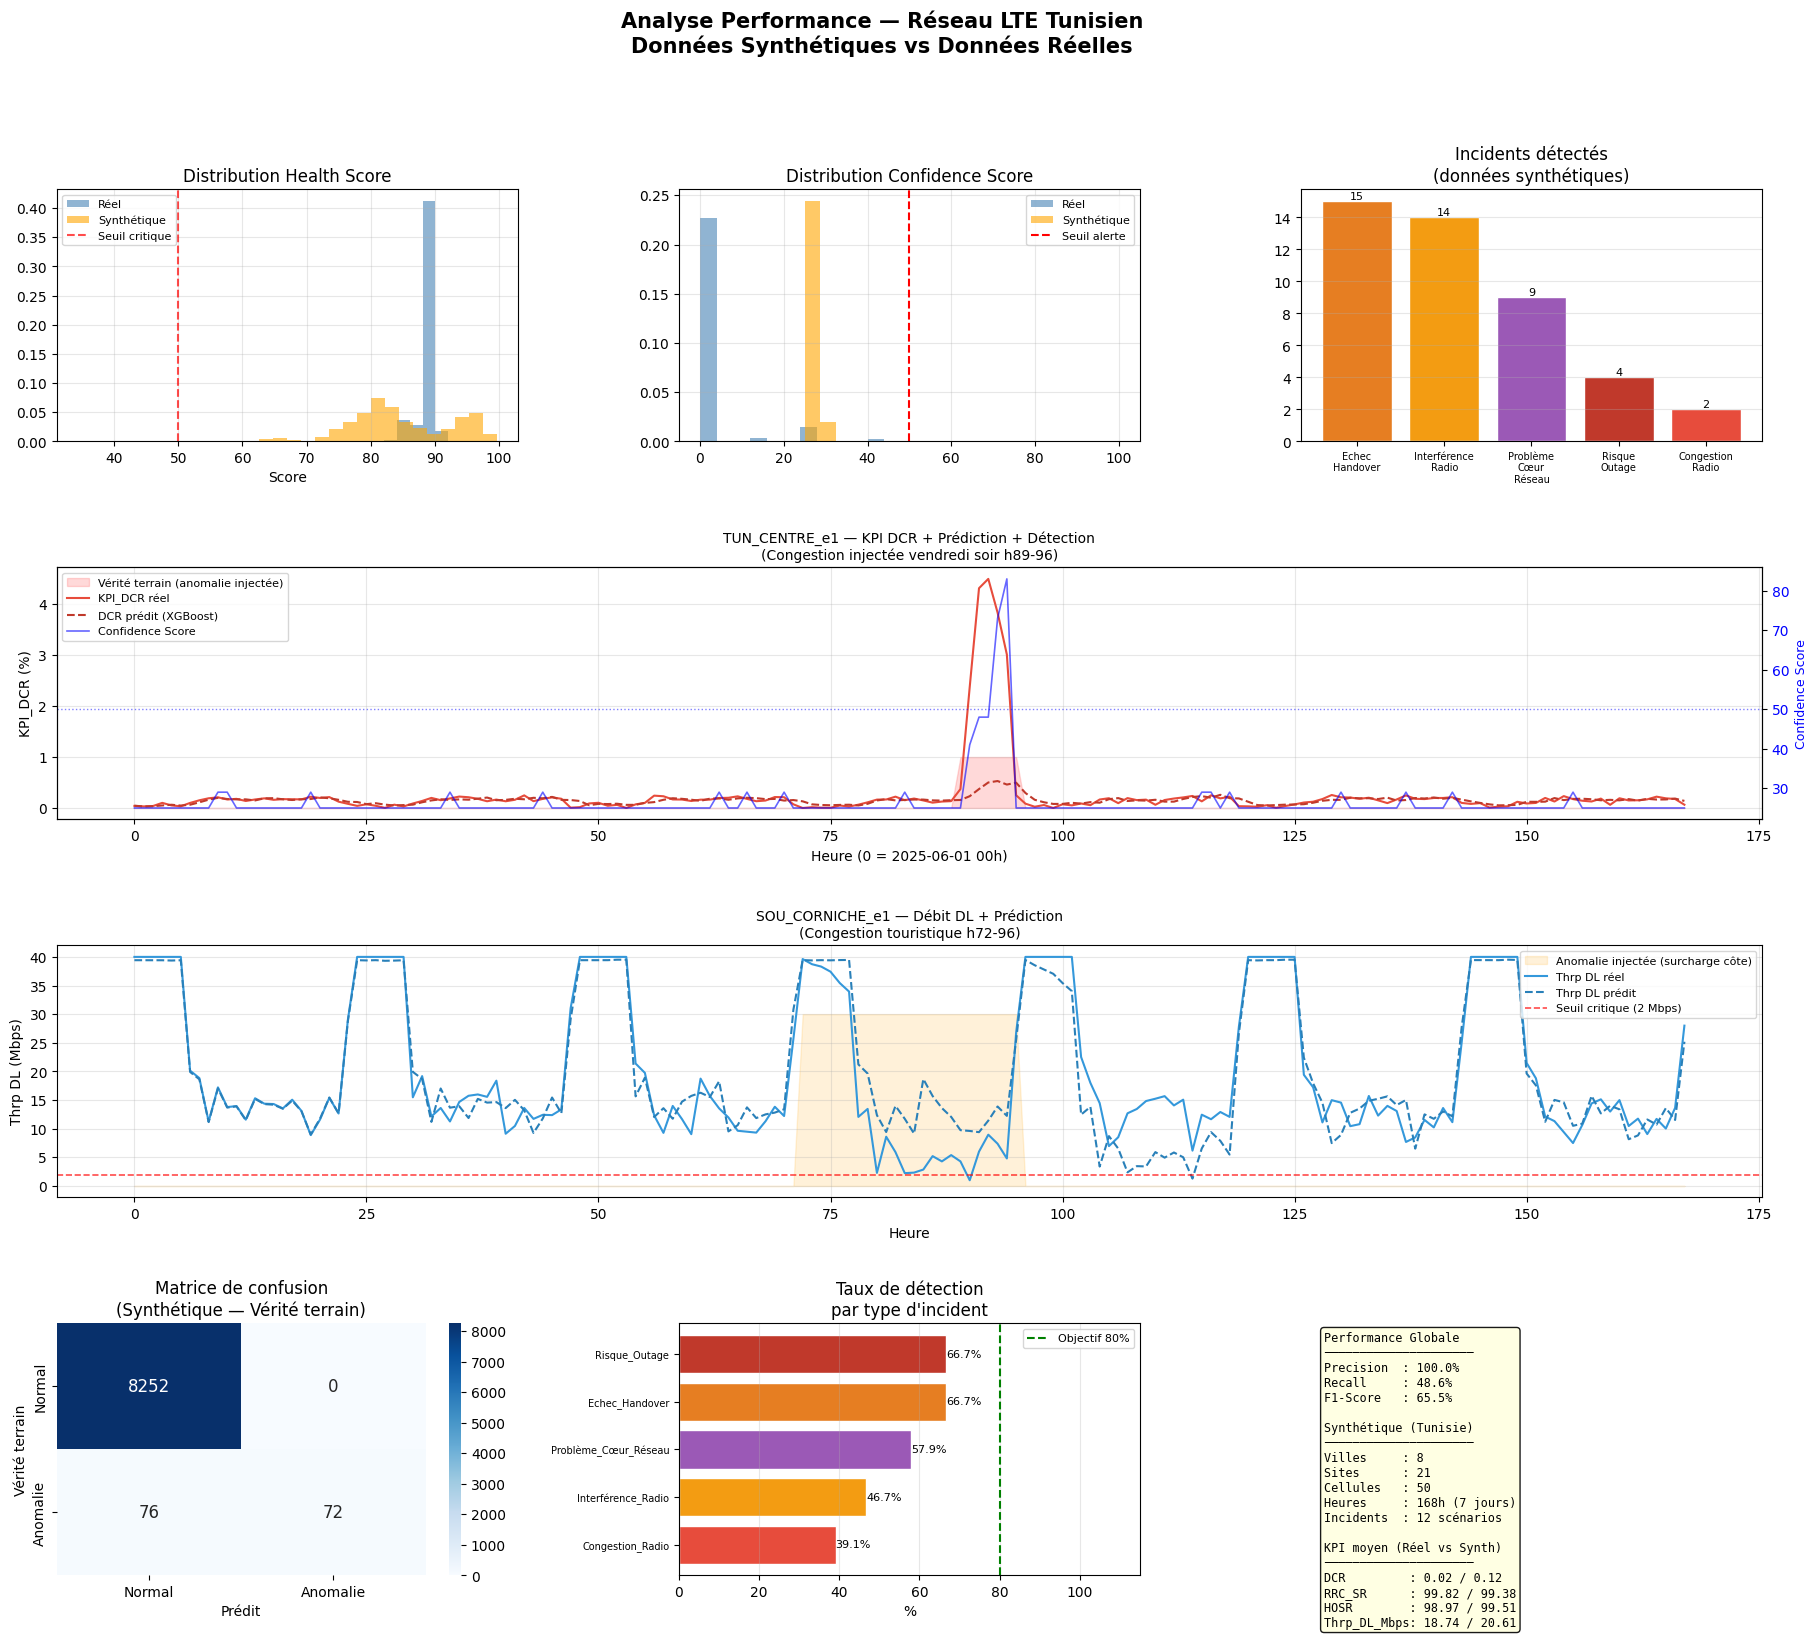

✅ SYN-5 terminé — graphique sauvegardé


In [ ]:
# ══════════════════════════════════════════════════════════════# CELL SYN-5 — COMPARAISON PERFORMANCE RÉEL vs SYNTHÉTIQUE
# ══════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import (precision_score, recall_score,
                             f1_score, confusion_matrix)

# ── Vérité terrain (ce qu'on a injecté) ──────────────────────
timestamps = pd.date_range(start=START_DATE, periods=N_HOURS, freq='h')
ground_truth = []

for ville, sites_ville in SITES.items():
    for (site_name, zone_type, n_cells) in sites_ville:
        for c_idx in range(1, n_cells + 1):
            cell_name = f'{site_name}_e{c_idx}'
            for h in range(N_HOURS):
                true_inc = 'Normal'
                for (site, cidx, h_s, h_e, inc_type, cause) in INCIDENTS:
                    if site == site_name and cidx == c_idx and h_s <= h < h_e:
                        true_inc = inc_type
                        break
                ground_truth.append({
                    'Time'          : timestamps[h],
                    'Cell_Name'     : cell_name,
                    'True_Incident' : true_inc,
                    'Is_Anomalie'   : 1 if true_inc != 'Normal' else 0,
                })

df_gt   = pd.DataFrame(ground_truth)
df_eval = df_s.merge(df_gt, on=['Time','Cell_Name'], how='left')
df_eval['Is_Anomalie'] = df_eval['Is_Anomalie'].fillna(0).astype(int)

# ── Métriques binaires ────────────────────────────────────────
y_true = df_eval['Is_Anomalie']
y_pred = (df_eval['Confidence_Score'] >= 50).astype(int)

precision = precision_score(y_true, y_pred, zero_division=0)
recall    = recall_score(y_true, y_pred, zero_division=0)
f1        = f1_score(y_true, y_pred, zero_division=0)
cm        = confusion_matrix(y_true, y_pred)

print("═" * 60)
print("  PERFORMANCE DÉTECTION — VÉRITÉ TERRAIN SYNTHÉTIQUE")
print("═" * 60)
print(f"  Precision  : {precision*100:.1f}%")
print(f"  Recall     : {recall*100:.1f}%")
print(f"  F1-Score   : {f1*100:.1f}%")
print(f"\n  Matrice de confusion :")
print(f"  TN={cm[0,0]:5d}  FP={cm[0,1]:5d}")
print(f"  FN={cm[1,0]:5d}  TP={cm[1,1]:5d}")

# Taux détection par type
detection_rates = {}
for inc in [i for i in df_eval['True_Incident'].unique() if i != 'Normal']:
    mask = df_eval['True_Incident'] == inc
    rate = (df_eval.loc[mask,'Confidence_Score'] >= 50).mean() * 100
    detection_rates[inc] = round(rate, 1)
    print(f"  {inc:28s} → {rate:.1f}%")

# ── Chargement données réelles ────────────────────────────────
df_real = pd.read_csv(
    '/content/drive/MyDrive/P2M_Models/Alerting/df_alerting_complet.csv'
)

# ── Visualisation ─────────────────────────────────────────────
COLORS_INC = {
    'Congestion_Radio'     : '#e74c3c',
    'Echec_Handover'       : '#e67e22',
    'Problème_Cœur_Réseau' : '#9b59b6',
    'Risque_Outage'        : '#c0392b',
    'Interférence_Radio'   : '#f39c12',
    'Normal'               : '#2ecc71',
}

fig = plt.figure(figsize=(22, 18))
gs  = gridspec.GridSpec(4, 3, figure=fig,
                        hspace=0.5, wspace=0.35)
fig.suptitle(
    'Analyse Performance — Réseau LTE Tunisien\n'
    'Données Synthétiques vs Données Réelles',
    fontsize=15, fontweight='bold'
)

# ── 1. Health Score : réel vs synthétique ────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(df_real['Health_Score'].dropna(), bins=30,
         alpha=0.6, color='steelblue', label='Réel', density=True)
ax1.hist(df_s['Health_Score'], bins=30,
         alpha=0.6, color='orange', label='Synthétique', density=True)
ax1.axvline(50, color='red', ls='--', lw=1.5, alpha=0.7,
            label='Seuil critique')
ax1.set_title('Distribution Health Score')
ax1.set_xlabel('Score'); ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# ── 2. Confidence Score : réel vs synthétique ────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(df_real['Confidence_Score'].dropna(), bins=20,
         alpha=0.6, color='steelblue', label='Réel', density=True)
ax2.hist(df_s['Confidence_Score'], bins=20,
         alpha=0.6, color='orange', label='Synthétique', density=True)
ax2.axvline(50, color='red', ls='--', lw=1.5, label='Seuil alerte')
ax2.set_title('Distribution Confidence Score')
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

# ── 3. Incidents synthétiques ─────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
inc_c  = df_s[df_s['Type_Incident']!='Normal']['Type_Incident'].value_counts()
colors = [COLORS_INC.get(i,'grey') for i in inc_c.index]
bars   = ax3.bar(range(len(inc_c)), inc_c.values,
                 color=colors, edgecolor='white')
ax3.set_xticks(range(len(inc_c)))
ax3.set_xticklabels([i.replace('_','\n') for i in inc_c.index],
                     fontsize=7)
ax3.bar_label(bars, fmt='%d', fontsize=8)
ax3.set_title('Incidents détectés\n(données synthétiques)')
ax3.grid(True, alpha=0.3, axis='y')

# ── 4. Timeline KPI_DCR — cellule avec congestion ─────────────
ax4 = fig.add_subplot(gs[1, :])
cell_demo = df_eval[df_eval['Cell_Name']=='TUN_CENTRE_e1'].sort_values('Time')
ax4_twin  = ax4.twinx()

ax4.fill_between(
    range(len(cell_demo)),
    cell_demo['Is_Anomalie'].values,
    alpha=0.15, color='red', label='Vérité terrain (anomalie injectée)'
)
ax4.plot(
    cell_demo['KPI_DCR'].values,
    color='#e74c3c', lw=1.5, label='KPI_DCR réel'
)
if 'DCR_Predit' in cell_demo.columns and cell_demo['DCR_Predit'].notna().any():
    ax4.plot(
        cell_demo['DCR_Predit'].values,
        color='#c0392b', lw=1.5, ls='--', label='DCR prédit (XGBoost)'
    )
ax4_twin.plot(
    cell_demo['Confidence_Score'].values,
    color='blue', lw=1.2, alpha=0.6, label='Confidence Score'
)
ax4_twin.axhline(50, color='blue', ls=':', lw=1, alpha=0.5)
ax4_twin.set_ylabel('Confidence Score', color='blue', fontsize=9)
ax4_twin.tick_params(axis='y', labelcolor='blue')
ax4.set_title('TUN_CENTRE_e1 — KPI DCR + Prédiction + Détection\n'
              '(Congestion injectée vendredi soir h89-96)',
              fontsize=10)
ax4.set_xlabel('Heure (0 = 2025-06-01 00h)')
ax4.set_ylabel('KPI_DCR (%)')
lines1, labels1 = ax4.get_legend_handles_labels()
lines2, labels2 = ax4_twin.get_legend_handles_labels()
ax4.legend(lines1+lines2, labels1+labels2, fontsize=8, loc='upper left')
ax4.grid(True, alpha=0.3)

# ── 5. Timeline Thrp DL — SOU_CORNICHE ───────────────────────
ax5 = fig.add_subplot(gs[2, :])
cell_sou = df_eval[df_eval['Cell_Name']=='SOU_CORNICHE_e1'].sort_values('Time')
ax5.fill_between(
    range(len(cell_sou)),
    cell_sou['Is_Anomalie'].values * 30,
    alpha=0.15, color='orange', label='Anomalie injectée (surcharge côte)'
)
ax5.plot(cell_sou['KPI_Thrp_DL_Mbps'].values,
         color='#3498db', lw=1.5, label='Thrp DL réel')
if 'ThrpDL_Predit' in cell_sou.columns and cell_sou['ThrpDL_Predit'].notna().any():
    ax5.plot(cell_sou['ThrpDL_Predit'].values,
             color='#2980b9', lw=1.5, ls='--', label='Thrp DL prédit')
ax5.axhline(2, color='red', ls='--', lw=1.2, alpha=0.7,
            label='Seuil critique (2 Mbps)')
ax5.set_title('SOU_CORNICHE_e1 — Débit DL + Prédiction\n'
              '(Congestion touristique h72-96)',
              fontsize=10)
ax5.set_xlabel('Heure'); ax5.set_ylabel('Thrp DL (Mbps)')
ax5.legend(fontsize=8, loc='upper right'); ax5.grid(True, alpha=0.3)

# ── 6. Matrice de confusion ───────────────────────────────────
ax6 = fig.add_subplot(gs[3, 0])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax6,
            xticklabels=['Normal','Anomalie'],
            yticklabels=['Normal','Anomalie'],
            annot_kws={'size':12})
ax6.set_title('Matrice de confusion\n(Synthétique — Vérité terrain)')
ax6.set_ylabel('Vérité terrain'); ax6.set_xlabel('Prédit')

# ── 7. Taux détection par type ────────────────────────────────
ax7 = fig.add_subplot(gs[3, 1])
if detection_rates:
    dr  = pd.Series(detection_rates).sort_values()
    col = [COLORS_INC.get(i,'grey') for i in dr.index]
    bars= ax7.barh(dr.index, dr.values, color=col, edgecolor='white')
    ax7.bar_label(bars, fmt='%.1f%%', fontsize=8)
    ax7.axvline(80, color='green', ls='--', lw=1.5,
                label='Objectif 80%')
    ax7.set_title('Taux de détection\npar type d\'incident')
    ax7.set_xlabel('%'); ax7.set_xlim(0, 115)
    ax7.legend(fontsize=8); ax7.tick_params(axis='y', labelsize=7)
    ax7.grid(True, alpha=0.3, axis='x')

# ── 8. Carte performance résumé ───────────────────────────────
ax8 = fig.add_subplot(gs[3, 2])
ax8.axis('off')

# Comparaison KPIs réel vs synthétique
kpi_comp = {}
for kpi in ['KPI_DCR','KPI_RRC_SR','KPI_HOSR','KPI_Thrp_DL_Mbps']:
    if kpi in df_real.columns and kpi in df_s.columns:
        kpi_comp[kpi] = {
            'réel'  : df_real[kpi].mean(),
            'synth' : df_s[kpi].mean(),
        }

resume = f"""Performance Globale
─────────────────────
Precision  : {precision*100:.1f}%
Recall     : {recall*100:.1f}%
F1-Score   : {f1*100:.1f}%

Synthétique (Tunisie)
─────────────────────
Villes     : {df_s['Ville'].nunique() if 'Ville' in df_s.columns else 'N/A'}
Sites      : {df_s['eNodeB_Name'].nunique()}
Cellules   : {df_s['Cell_Name'].nunique()}
Heures     : {N_HOURS}h (7 jours)
Incidents  : {len(INCIDENTS)} scénarios

KPI moyen (Réel vs Synth)
─────────────────────"""
for kpi, vals in kpi_comp.items():
    resume += f"\n{kpi.replace('KPI_',''):12s}: {vals['réel']:.2f} / {vals['synth']:.2f}"

ax8.text(0.05, 0.97, resume, transform=ax8.transAxes,
         fontsize=8.5, verticalalignment='top',
         fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

plt.savefig(
    '/content/drive/MyDrive/P2M_Models/Synthetic/performance_tunisie.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("✅ SYN-5 terminé — graphique sauvegardé")

In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL SYN-6 — EXPORT FINAL POUR STREAMLIT
# ══════════════════════════════════════════════════════════════
import os, json, shutil

SAVE_SYNTH = '/content/drive/MyDrive/P2M_Models/Synthetic'
os.makedirs(SAVE_SYNTH, exist_ok=True)

# ── 1. Dataset synthétique complet (avec toutes les colonnes) ─
cols_export = [
    'Time', 'eNodeB_Name', 'Cell_Name', 'eNodeB_Function_Name',
    'Ville', 'Zone_Type',
    'Health_Score', 'Health_Category',
    'IF_Anomalie', 'AE_Anomalie', 'RF_Prediction', 'Anomalie_Confirmee',
    'Type_Incident', 'Confidence_Score', 'Niveau_Alerte',
    'Action_Immediate', 'Action_Court_Terme', 'Escalade', 'Urgence',
    'KPI_RRC_SR', 'KPI_DCR', 'KPI_ERAB_SR',
    'KPI_Thrp_DL_Mbps', 'KPI_Thrp_UL_Mbps',
    'KPI_HOSR', 'KPI_HOSR_InterFreq', 'KPI_HOSR_InterRAT',
    'Cell_Availability', 'CSFB_SR',
    'DCR_Predit', 'RRC_Predit', 'ThrpDL_Predit', 'ThrpUL_Predit',
]
cols_ok = [c for c in cols_export if c in df_s.columns]
df_s[cols_ok].to_csv(
    f'{SAVE_SYNTH}/df_synthetic_alerting.csv', index=False
)

# ── 2. Résumé par cellule ─────────────────────────────────────
cell_summary_s = (
    df_s.groupby(['eNodeB_Name', 'Cell_Name'])
    .agg(
        Ville                = ('Ville',            'first') if 'Ville' in df_s.columns else ('Cell_Name','count'),
        Zone_Type            = ('Zone_Type',         'first') if 'Zone_Type' in df_s.columns else ('Cell_Name','count'),
        Nb_Total_Obs         = ('Confidence_Score',  'count'),
        Nb_Alertes_Critiques = ('Confidence_Score',  lambda x: (x>=70).sum()),
        Nb_Alertes_Reelles   = ('Confidence_Score',  lambda x: (x>=50).sum()),
        Confidence_Max       = ('Confidence_Score',  'max'),
        Health_Score_Moyen   = ('Health_Score',      'mean'),
        Incident_Dominant    = ('Type_Incident',
                                lambda x: x[x!='Normal'].mode()[0]
                                if (x!='Normal').any() else 'Normal'),
    )
    .reset_index()
    .round(2)
)
cell_summary_s.to_csv(
    f'{SAVE_SYNTH}/cell_summary_synthetic.csv', index=False
)

# ── 3. Vérité terrain ─────────────────────────────────────────
df_gt.to_csv(f'{SAVE_SYNTH}/ground_truth.csv', index=False)

# ── 4. Métriques de performance JSON ─────────────────────────
perf_metrics = {
    'precision'             : round(float(precision), 4),
    'recall'                : round(float(recall),    4),
    'f1_score'              : round(float(f1),        4),
    'confusion_matrix'      : cm.tolist(),
    'detection_par_type'    : detection_rates,
    'nb_incidents_injectes' : len(INCIDENTS),
    'nb_villes'             : int(df_s['Ville'].nunique()) if 'Ville' in df_s.columns else 0,
    'nb_sites'              : int(df_s['eNodeB_Name'].nunique()),
    'nb_cellules'           : int(df_s['Cell_Name'].nunique()),
    'nb_heures'             : N_HOURS,
    'nb_alertes_reelles'    : int((df_s['Confidence_Score']>=50).sum()),
    'nb_alertes_critiques'  : int((df_s['Confidence_Score']>=70).sum()),
    'health_score_moyen'    : round(float(df_s['Health_Score'].mean()), 2),
    'kpi_moyennes'          : {
        kpi: round(float(df_s[kpi].mean()), 4)
        for kpi in ['KPI_DCR','KPI_RRC_SR','KPI_HOSR',
                    'KPI_Thrp_DL_Mbps','KPI_Thrp_UL_Mbps']
        if kpi in df_s.columns
    },
    'incidents_injectes'    : [
        {'site': s, 'cellule': f'e{c}', 'h_debut': hs,
         'h_fin': he, 'type': inc, 'cause': cause}
        for s, c, hs, he, inc, cause in INCIDENTS
    ],
}
with open(f'{SAVE_SYNTH}/performance_metrics.json', 'w',
          encoding='utf-8') as f:
    json.dump(perf_metrics, f, indent=2, ensure_ascii=False)

# ── 5. Copier vers data/ de l'app Streamlit ──────────────────
APP_DATA = '/content/p2m_network_app/data'
os.makedirs(APP_DATA, exist_ok=True)

for fname in ['df_synthetic_alerting.csv',
              'cell_summary_synthetic.csv',
              'ground_truth.csv',
              'performance_metrics.json']:
    src = f'{SAVE_SYNTH}/{fname}'
    if os.path.exists(src):
        shutil.copy(src, f'{APP_DATA}/{fname}')
        size = os.path.getsize(f'{APP_DATA}/{fname}') / 1024
        print(f"  ✅ {fname:40s} ({size:.0f} Ko)")

# ── Résumé final ──────────────────────────────────────────────
print(f"\n{'═'*55}")
print(f"  RÉSUMÉ EXPORT SYN-6")
print(f"{'═'*55}")
print(f"  Drive  : {SAVE_SYNTH}/")
print(f"  App    : {APP_DATA}/")
print(f"\n  Fichiers générés :")
for f in os.listdir(SAVE_SYNTH):
    sz = os.path.getsize(f'{SAVE_SYNTH}/{f}') / 1024
    print(f"  📄 {f:45s} {sz:7.1f} Ko")
print(f"\n  Dataset synthétique : {df_s.shape[0]:,} lignes × {len(cols_ok)} colonnes")
print(f"  Villes              : Tunis, Sfax, Sousse, Monastir, Nabeul, Bizerte, Gabès, Kairouan")
print(f"  Performance F1      : {f1*100:.1f}%")
print(f"\n✅ Pipeline synthétique complet terminé !")

  ✅ df_synthetic_alerting.csv                (2322 Ko)
  ✅ cell_summary_synthetic.csv               (3 Ko)
  ✅ ground_truth.csv                         (357 Ko)
  ✅ performance_metrics.json                 (3 Ko)

═══════════════════════════════════════════════════════
  RÉSUMÉ EXPORT SYN-6
═══════════════════════════════════════════════════════
  Drive  : /content/drive/MyDrive/P2M_Models/Synthetic/
  App    : /content/p2m_network_app/data/

  Fichiers générés :
  📄 dataset_synthetique_tunisien.csv               1393.8 Ko
  📄 performance_tunisie.png                         536.5 Ko
  📄 cell_summary_synthetic.csv                        3.5 Ko
  📄 performance_metrics.json                          2.8 Ko
  📄 df_synthetic_alerting.csv                      2321.9 Ko
  📄 ground_truth.csv                                356.8 Ko

  Dataset synthétique : 8,400 lignes × 29 colonnes
  Villes              : Tunis, Sfax, Sousse, Monastir, Nabeul, Bizerte, Gabès, Kairouan
  Performance F1      : 65

In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL CARTO-1 — CARTOGRAPHIE RÉSEAU TUNISIEN SYNTHÉTIQUE
# ══════════════════════════════════════════════════════════════
!pip install folium -q

import folium
import pandas as pd
import numpy as np
import json
from folium.plugins import MarkerCluster, HeatMap

# ── Coordonnées GPS réelles des sites ─────────────────────────
# Format : site_name → (lat, lon, ville)
SITES_GPS = {
    # Tunis
    'TUN_CENTRE'    : (36.8190,  10.1658, 'Tunis'),
    'TUN_BARDO'     : (36.8090,  10.1340, 'Tunis'),
    'TUN_LAC2'      : (36.8330,  10.2300, 'Tunis'),
    'TUN_ARIANA'    : (36.8625,  10.1956, 'Tunis'),
    'TUN_MENZAH'    : (36.8450,  10.1750, 'Tunis'),
    # Sfax
    'SFX_CENTRE'    : (34.7400,  10.7600, 'Sfax'),
    'SFX_SAKIET'    : (34.7600,  10.7400, 'Sfax'),
    'SFX_ROUTE_TUNIS': (35.0500, 10.5000, 'Sfax'),
    # Sousse
    'SOU_CENTRE'    : (35.8245,  10.6346, 'Sousse'),
    'SOU_CORNICHE'  : (35.8350,  10.6100, 'Sousse'),
    'SOU_KHEZAMA'   : (35.8100,  10.6500, 'Sousse'),
    # Monastir
    'MON_AEROPORT'  : (35.7581,  10.7547, 'Monastir'),
    'MON_CENTRE'    : (35.7643,  10.8113, 'Monastir'),
    # Nabeul
    'NAB_HAMMAMET'  : (36.4000,  10.6167, 'Nabeul'),
    'NAB_CENTRE'    : (36.4561,  10.7376, 'Nabeul'),
    # Bizerte
    'BIZ_CENTRE'    : (37.2744,  9.8739,  'Bizerte'),
    'BIZ_PORT'      : (37.2700,  9.8650,  'Bizerte'),
    # Gabès
    'GAB_CENTRE'    : (33.8881,  10.0975, 'Gabès'),
    'GAB_ZONE_IND'  : (33.8700,  10.1200, 'Gabès'),
    # Kairouan
    'KAI_CENTRE'    : (35.6781,  10.0963, 'Kairouan'),
    'KAI_NORD'      : (35.6950,  10.0900, 'Kairouan'),
}

print(f"✅ {len(SITES_GPS)} sites configurés avec coordonnées GPS")
print("\nAperçu :")
for site, (lat, lon, ville) in list(SITES_GPS.items())[:5]:
    print(f"  {site:20s} → ({lat:.4f}, {lon:.4f}) — {ville}")

✅ 21 sites configurés avec coordonnées GPS

Aperçu :
  TUN_CENTRE           → (36.8190, 10.1658) — Tunis
  TUN_BARDO            → (36.8090, 10.1340) — Tunis
  TUN_LAC2             → (36.8330, 10.2300) — Tunis
  TUN_ARIANA           → (36.8625, 10.1956) — Tunis
  TUN_MENZAH           → (36.8450, 10.1750) — Tunis


In [ ]:
# ══════════════════════════════════════════════════════════════
# SETUP — Créer la structure de l'app Streamlit
# ══════════════════════════════════════════════════════════════
import os

BASE = '/content/p2m_network_app'
os.makedirs(f'{BASE}/pages', exist_ok=True)
os.makedirs(f'{BASE}/data',  exist_ok=True)

print("✅ Structure créée :")
print(f"  {BASE}/")
print(f"  {BASE}/pages/")
print(f"  {BASE}/data/")

✅ Structure créée :
  /content/p2m_network_app/
  /content/p2m_network_app/pages/
  /content/p2m_network_app/data/


In [ ]:
%%writefile /content/p2m_network_app/requirements.txt
streamlit>=1.32.0
pandas>=2.0.0
numpy>=1.24.0
plotly>=5.18.0
scikit-learn>=1.3.0
xgboost>=2.0.0
pyarrow>=14.0.0
openpyxl>=3.1.0
folium>=0.14.0

Overwriting /content/p2m_network_app/requirements.txt


In [ ]:
%%writefile /content/p2m_network_app/config.py
import os

# ══════════════════════════════════════════════════════════════
# CHEMINS DRIVE — noms exacts vérifiés sur Drive
# ══════════════════════════════════════════════════════════════
DRIVE_ROOT = '/content/drive/MyDrive'
DRIVE_P2M  = '/content/drive/MyDrive/P2M_Models'

DATA_DIR   = './data'

# ── Modèles ML ─────────────────────────────────────────────────
MODEL_PATHS = {
    # Racine Mon Drive
    'xgboost_dcr'          : f'{DRIVE_ROOT}/xgboost_dcr.pkl',
    'xgboost_dcr_features' : f'{DRIVE_ROOT}/xgboost_dcr_features.pkl',
    'xgboost_dcr_v3_json'  : f'{DRIVE_ROOT}/xgboost_dcr_v3.json',
    'xgboost_dcr_v3_feat'  : f'{DRIVE_ROOT}/xgboost_dcr_v3_features.pkl',
    'lightgbm_rrc'         : f'{DRIVE_ROOT}/lightgbm_rrc_sr_v2.pkl',
    'lightgbm_rrc_features': f'{DRIVE_ROOT}/lightgbm_rrc_sr_v2_features.pkl',

    # P2M_Models racine
    'isolation_forest'     : f'{DRIVE_P2M}/isolation_forest.pkl',
    'random_forest'        : f'{DRIVE_P2M}/random_forest.pkl',
    'rf_feature_importance': f'{DRIVE_P2M}/rf_feature_importance.csv',

    # Autoencoder_LSTM/
    'lstm_ae'              : f'{DRIVE_P2M}/Autoencoder_LSTM/lstm_ae.pth',
    'config_ae'            : f'{DRIVE_P2M}/Autoencoder_LSTM/config_ae.json',

    # Thrp_DLUL_v2/ — NHiTS
    'nhits_DL'             : f'{DRIVE_P2M}/Thrp_DLUL_v2/nhits_DL.pth',
    'thrp_dir'             : f'{DRIVE_P2M}/Thrp_DLUL_v2',
    'nhits_UL'             : f'{DRIVE_P2M}/Thrp_DLUL_v2/nhits_UL.pth',
    # Thrp_DLUL_v2/ — XGBoost Thrp
    'xgb_DL_json'          : f'{DRIVE_P2M}/Thrp_DLUL_v2/xgb_DL.json',
    'xgb_UL_json'          : f'{DRIVE_P2M}/Thrp_DLUL_v2/xgb_UL.json',
    # Thrp_DLUL_v2/ — Scalers
    'scaler_X_DL'          : f'{DRIVE_P2M}/Thrp_DLUL_v2/scaler_X_DL.pkl',
    'scaler_X_UL'          : f'{DRIVE_P2M}/Thrp_DLUL_v2/scaler_X_UL.pkl',
    'scaler_y_DL'          : f'{DRIVE_P2M}/Thrp_DLUL_v2/scaler_y_DL.pkl',
    'scaler_y_UL'          : f'{DRIVE_P2M}/Thrp_DLUL_v2/scaler_y_UL.pkl',
    'sc_meta_DL'           : f'{DRIVE_P2M}/Thrp_DLUL_v2/sc_meta_DL.pkl',
    'sc_meta_UL'           : f'{DRIVE_P2M}/Thrp_DLUL_v2/sc_meta_UL.pkl',
    'meta_mlp_DL'          : f'{DRIVE_P2M}/Thrp_DLUL_v2/meta_mlp_DL.pkl',
    'meta_mlp_UL'          : f'{DRIVE_P2M}/Thrp_DLUL_v2/meta_mlp_UL.pkl',
}

# ── Données ────────────────────────────────────────────────────
DATA_PATHS = {
    # Alerting/
    'df_alerting_complet'  : f'{DRIVE_P2M}/Alerting/df_alerting_complet.csv',
    'alertes_reelles'      : f'{DRIVE_P2M}/Alerting/alertes_reelles.csv',
    'cell_alert_summary'   : f'{DRIVE_P2M}/Alerting/cell_alert_summary.csv',
    'alerting_summary_json': f'{DRIVE_P2M}/Alerting/alerting_summary.json',

    # HealthScore/
    'cell_health_scores'       : f'{DRIVE_P2M}/HealthScore/cell_health_scores.csv',
    'df_health_scores_complet' : f'{DRIVE_P2M}/HealthScore/df_health_scores_complet.csv',
    'health_summary_json'      : f'{DRIVE_P2M}/HealthScore/health_summary.json',

    # Autoencoder_LSTM/
    'df_ml_avec_AE'        : f'{DRIVE_P2M}/Autoencoder_LSTM/df_ml_avec_AE.csv',

    # Granger/
    'granger_stabilite'         : f'{DRIVE_P2M}/Granger/granger_stabilite.csv',
    'granger_resultats_complets': f'{DRIVE_P2M}/Granger/granger_resultats_complets.csv',
    'interpretations_causales'  : f'{DRIVE_P2M}/Granger/interpretations_causales.json',

    # P2M_Models racine
    'dataset_ml'           : f'{DRIVE_P2M}/df_ml_avec_statut.csv',
}

# ══════════════════════════════════════════════════════════════
# COULEURS & LABELS (inchangés)
# ══════════════════════════════════════════════════════════════
COLORS = {
    '🔴 CRITIQUE' : '#e74c3c',
    '🟠 MAJEURE'  : '#e67e22',
    '🟡 MINEURE'  : '#f1c40f',
    '⚪ BRUIT'    : '#bdc3c7',
    'Normal'      : '#2ecc71',
}
COLORS_INCIDENT = {
    'Congestion_Radio'      : '#e74c3c',
    'Echec_Handover'        : '#e67e22',
    'Problème_Cœur_Réseau'  : '#9b59b6',
    'Risque_Outage'         : '#c0392b',
    'Interférence_Radio'    : '#f39c12',
    'Normal'                : '#2ecc71',
}
KPI_LABELS = {
    'KPI_DCR'           : 'Drop Call Rate (%)',
    'KPI_RRC_SR'        : 'RRC Setup SR (%)',
    'KPI_ERAB_SR'       : 'E-RAB SR (%)',
    'KPI_HOSR'          : 'Handover SR (%)',
    'KPI_HOSR_InterFreq': 'HO Inter-Freq SR (%)',
    'KPI_Thrp_DL_Mbps'  : 'Débit DL (Mbps)',
    'KPI_Thrp_UL_Mbps'  : 'Débit UL (Mbps)',
}
SEUILS_CRITIQUE = {
    'KPI_DCR'           : 2.0,
    'KPI_RRC_SR'        : 95.0,
    'KPI_ERAB_SR'       : 95.0,
    'KPI_HOSR'          : 90.0,
    'KPI_HOSR_InterFreq': 85.0,
    'KPI_Thrp_DL_Mbps'  : 2.0,
    'KPI_Thrp_UL_Mbps'  : 1.0,
}
RECOMMANDATIONS = {
    'Congestion_Radio': {
        'immediate'   : 'Activer load balancing inter-fréquences (A5/A4)',
        'court_terme' : 'Planifier Carrier Aggregation ou porteuse additionnelle',
        'escalade'    : 'Équipe Radio Planning',
        'urgence'     : '< 2h',
    },
    'Echec_Handover': {
        'immediate'   : 'Vérifier paramètres X2 avec cellules voisines (A3 offset, TTT)',
        'court_terme' : 'Audit ANR et recalibration seuils HO',
        'escalade'    : 'Équipe Optimisation Radio',
        'urgence'     : '< 4h',
    },
    'Problème_Cœur_Réseau': {
        'immediate'   : 'Vérifier état lien S1-U (MME/SGW) et compteurs S1AP',
        'court_terme' : 'Analyse logs MME + vérification pools SGW',
        'escalade'    : 'NOC Core Network',
        'urgence'     : '< 1h',
    },
    'Risque_Outage': {
        'immediate'   : 'Vérifier alimentation eNodeB + lien transmission',
        'court_terme' : 'Intervention terrain (VSWR, AISG)',
        'escalade'    : 'Maintenance Terrain + NOC',
        'urgence'     : 'IMMÉDIAT',
    },
    'Interférence_Radio': {
        'immediate'   : 'Analyser spectre UL + vérifier ICIC/eICIC',
        'court_terme' : 'Audit niveaux puissance voisins, ajustement tilt/azimut',
        'escalade'    : 'Équipe Optimisation RF',
        'urgence'     : '< 6h',
    },
}

Overwriting /content/p2m_network_app/config.py


In [ ]:
%%writefile /content/p2m_network_app/design.py
"""P2M Network Monitor — Design System"""

import streamlit as st

_CSS = """
<link rel="preconnect" href="https://fonts.googleapis.com">
<link href="https://fonts.googleapis.com/css2?family=DM+Sans:ital,opsz,wght@0,9..40,300;0,9..40,400;0,9..40,500;0,9..40,600;0,9..40,700;1,9..40,400&family=DM+Mono:wght@400;500&display=swap" rel="stylesheet">
<style>
:root{
  --bg:        #0d1017;
  --surface:   #141824;
  --raised:    #1a1f2e;
  --overlay:   #20263a;
  --accent:    #f5a623;
  --acc-dim:   rgba(245,166,35,.10);
  --acc-bdr:   rgba(245,166,35,.30);
  --red:       #e05252;
  --orange:    #e07c52;
  --green:     #52b788;
  --blue:      #5b8dee;
  --purple:    #8b72d8;
  --gold:      #d4a84b;
  --txt:       #e2e8f4;
  --txt2:      #8b94aa;
  --txt3:      #4e5668;
  --bdr:       rgba(255,255,255,.065);
  --r:         10px;
  --rlg:       16px;
}
html,body,[data-testid="stApp"]{
  background:var(--bg)!important;
  color:var(--txt)!important;
  font-family:'DM Sans',system-ui,sans-serif!important;
  font-size:14px;line-height:1.6;
}
/* ─ Sidebar ─ */
[data-testid="stSidebar"]{
  background:var(--surface)!important;
  border-right:1px solid var(--bdr)!important;
}
[data-testid="stSidebar"] *{font-family:'DM Sans',sans-serif!important;color:var(--txt)!important}
/* ─ Main ─ */
.main .block-container{max-width:1280px!important;padding:2rem 2.5rem!important}
/* ─ Typography ─ */
h1{font-family:'DM Sans',sans-serif!important;font-weight:700!important;
   font-size:1.7rem!important;letter-spacing:-.03em!important;
   color:var(--txt)!important;margin-bottom:.2rem!important;padding-bottom:0!important;border:none!important}
h2{font-weight:600!important;font-size:1rem!important;color:var(--txt2)!important;
   letter-spacing:-.01em!important;margin-top:1.75rem!important;
   padding-bottom:.5rem!important;border-bottom:1px solid var(--bdr)!important}
h3{font-weight:500!important;font-size:.9rem!important;color:var(--txt2)!important}
/* ─ Metrics ─ */
[data-testid="stMetric"]{
  background:var(--raised)!important;border:1px solid var(--bdr)!important;
  border-radius:var(--r)!important;padding:1rem 1.25rem!important;
  transition:border-color .2s;
}
[data-testid="stMetric"]:hover{border-color:var(--acc-bdr)!important}
[data-testid="stMetricLabel"] p{
  font-size:10px!important;font-weight:700!important;
  text-transform:uppercase!important;letter-spacing:.08em!important;color:var(--txt3)!important;
}
[data-testid="stMetricValue"]{
  font-family:'DM Mono',monospace!important;font-size:1.75rem!important;
  font-weight:500!important;color:var(--txt)!important;letter-spacing:-.03em!important;
}
/* ─ HR ─ */
hr{border:none!important;border-top:1px solid var(--bdr)!important;margin:1.5rem 0!important}
/* ─ Alerts ─ */
[data-testid="stAlert"]{border-radius:var(--r)!important;background:var(--raised)!important;
  border-left-width:3px!important}
/* ─ Buttons ─ */
.stButton>button{
  background:transparent!important;border:1px solid var(--acc-bdr)!important;
  color:var(--accent)!important;font-family:'DM Sans',sans-serif!important;
  font-size:13px!important;font-weight:500!important;border-radius:var(--r)!important;
  padding:.4rem 1.1rem!important;transition:all .18s ease!important;
}
.stButton>button:hover{
  background:var(--acc-dim)!important;border-color:var(--accent)!important;
  transform:translateY(-1px);box-shadow:0 4px 12px rgba(245,166,35,.18)!important;
}
.stButton>button[kind="primary"]{
  background:var(--accent)!important;color:#0d1017!important;
  border-color:var(--accent)!important;font-weight:700!important;
}
/* ─ Inputs ─ */
.stSelectbox>div>div,.stMultiSelect>div>div{
  background:var(--raised)!important;border-color:var(--bdr)!important;
  border-radius:var(--r)!important;color:var(--txt)!important;
}
.stSlider>div>div>div{background:var(--accent)!important}
/* ─ DataFrames ─ */
[data-testid="stDataFrame"]{border:1px solid var(--bdr)!important;border-radius:var(--r)!important;overflow:hidden}
/* ─ Tabs ─ */
.stTabs [data-baseweb="tab-list"]{background:var(--surface)!important;border-radius:var(--r)!important;padding:2px!important;gap:4px}
.stTabs [data-baseweb="tab"]{font-family:'DM Sans',sans-serif!important;font-size:13px!important;
  color:var(--txt2)!important;border-radius:8px!important;padding:6px 14px!important}
.stTabs [aria-selected="true"]{background:var(--raised)!important;color:var(--accent)!important}
/* ─ Expanders ─ */
[data-testid="stExpander"]{background:var(--raised)!important;border:1px solid var(--bdr)!important;border-radius:var(--r)!important}
/* ─ Sidebar nav ─ */
[data-testid="stSidebarNavLink"]{border-radius:8px!important;margin:2px 0!important;padding:6px 12px!important;transition:background .15s}
[data-testid="stSidebarNavLink"]:hover{background:var(--acc-dim)!important}
[data-testid="stSidebarNavLink"][aria-current="page"]{background:var(--acc-dim)!important;border-left:3px solid var(--accent)!important;color:var(--accent)!important}
/* ─ Caption ─ */
.stCaption,small{color:var(--txt3)!important;font-size:11.5px!important}
/* ─ Radio ─ */
.stRadio>div>label{font-size:13px!important;color:var(--txt2)!important}
/* ─ Scrollbar ─ */
::-webkit-scrollbar{width:5px;height:5px}
::-webkit-scrollbar-track{background:var(--bg)}
::-webkit-scrollbar-thumb{background:var(--overlay);border-radius:3px}
::-webkit-scrollbar-thumb:hover{background:var(--txt3)}
/* ─ Custom components ─ */
.p2m-header{display:flex;align-items:center;gap:12px;margin-bottom:1.5rem;
  padding-bottom:1rem;border-bottom:1px solid var(--bdr)}
.p2m-badge{display:inline-block;font-family:'DM Mono',monospace;font-size:10px;
  font-weight:500;padding:2px 9px;border-radius:20px;letter-spacing:.05em;vertical-align:middle;margin-left:8px}
.p2m-badge-live{background:rgba(82,183,136,.12);border:1px solid rgba(82,183,136,.35);color:#52b788}
.p2m-badge-synth{background:rgba(91,141,238,.12);border:1px solid rgba(91,141,238,.35);color:#5b8dee}
.p2m-city-grid{display:flex;flex-wrap:wrap;gap:8px;margin-top:.75rem}
.p2m-city-card{background:var(--raised);border:1px solid var(--bdr);
  border-radius:var(--r);padding:10px 14px;min-width:110px;transition:border-color .2s}
.p2m-city-card:hover{border-color:var(--acc-bdr)}
.p2m-city-card.critical{border-color:rgba(224,82,82,.35)}
.p2m-city-name{font-weight:600;font-size:12px;color:var(--txt);margin-bottom:4px}
.p2m-city-stats{font-family:'DM Mono',monospace;font-size:11px;color:var(--txt3);line-height:1.8}
.p2m-notice{background:var(--raised);border:1px solid var(--bdr);
  border-left:3px solid var(--accent);border-radius:var(--r);
  padding:12px 16px;font-size:13px;color:var(--txt2);margin-top:1.5rem}
.p2m-reco{border-radius:var(--r);padding:12px 16px;margin:6px 0;font-size:13px}
.p2m-reco.critical{background:rgba(224,82,82,.07);border:1px solid rgba(224,82,82,.25);border-left:3px solid #e05252;color:var(--txt)}
.p2m-reco.warning{background:rgba(212,168,75,.07);border:1px solid rgba(212,168,75,.25);border-left:3px solid #d4a84b;color:var(--txt2)}
.p2m-reco.info{background:rgba(91,141,238,.07);border:1px solid rgba(91,141,238,.25);border-left:3px solid #5b8dee;color:var(--txt2)}
</style>
"""

PLOTLY_THEME = dict(
    paper_bgcolor='rgba(0,0,0,0)',
    plot_bgcolor='rgba(0,0,0,0)',
    font=dict(family='DM Sans, sans-serif', color='#8b94aa', size=12),
    xaxis=dict(
        gridcolor='rgba(255,255,255,0.04)',
        linecolor='rgba(255,255,255,0.07)',
        tickfont=dict(size=11, color='#4e5668'),
    ),
    yaxis=dict(
        gridcolor='rgba(255,255,255,0.04)',
        linecolor='rgba(255,255,255,0.07)',
        tickfont=dict(size=11, color='#4e5668'),
    ),
    legend=dict(
        bgcolor='rgba(26,31,46,0.92)',
        bordercolor='rgba(255,255,255,0.07)',
        borderwidth=1,
        font=dict(size=11, color='#8b94aa'),
        orientation='h',
        yanchor='bottom',
        y=1.02,
    ),
    margin=dict(l=0, r=0, t=36, b=0),
)

# Helper: apply theme + optional title to a figure
def apply_theme(fig, title=None, height=None, **kwargs):
    update = dict(**PLOTLY_THEME)
    if title:
        update['title'] = dict(
            text=title,
            font=dict(size=13, color='#8b94aa', family='DM Sans'),
            x=0, pad=dict(l=0, t=4)
        )
    if height:
        update['height'] = height
    update.update(kwargs)
    fig.update_layout(**update)
    return fig

def inject_css():
    st.markdown(_CSS, unsafe_allow_html=True)

def page_header(title, subtitle=None, badge=None, badge_type="live"):
    bc = "p2m-badge-synth" if badge_type == "synth" else "p2m-badge-live"
    b  = f"<span class='p2m-badge {bc}'>{badge}</span>" if badge else ""
    s  = f"<p style='color:var(--txt3,#4e5668);font-size:12.5px;margin:2px 0 0'>{subtitle}</p>" if subtitle else ""
    st.markdown(
        f"<div class='p2m-header'><div><h1 style='margin:0;padding:0;border:none'>{title}{b}</h1>{s}</div></div>",
        unsafe_allow_html=True
    )

def notice(text):
    st.markdown(f"<div class='p2m-notice'>{text}</div>", unsafe_allow_html=True)

def reco_block(level, label, text):
    css_class = {"critical":"critical","warning":"warning","info":"info"}.get(level,"info")
    st.markdown(f"<div class='p2m-reco {css_class}'><strong>{label}</strong> — {text}</div>",
                unsafe_allow_html=True)


Overwriting /content/p2m_network_app/design.py


In [ ]:
%%writefile /content/p2m_network_app/app.py
import streamlit as st
import pandas as pd
import os
from config import DATA_PATHS, COLORS
from design import inject_css, page_header, notice

st.set_page_config(
    page_title="P2M — Network Health Monitor",
    page_icon="📡",
    layout="wide",
    initial_sidebar_state="expanded",
)
inject_css()

# ══════════════════════════════════════════════════════════════
# RECALCUL CONFIDENCE SCORE (si colonnes ML absentes/vides)
# ══════════════════════════════════════════════════════════════
def recompute_scores(df):
    ML_COLS = ['IF_Anomalie','AE_Anomalie','RF_Prediction','Anomalie_Confirmee']
    has_ml  = all(c in df.columns and df[c].sum() > 0 for c in ML_COLS)
    if has_ml:
        return df  # modèles ML présents → pas besoin de recalculer

    SEUILS_KPI = {
        'KPI_DCR'          : ('>', 2),
        'KPI_RRC_SR'       : ('<', 95),
        'KPI_ERAB_SR'      : ('<', 95),
        'KPI_HOSR'         : ('<', 90),
        'KPI_Thrp_DL_Mbps' : ('<', 2),
        'Cell_Availability': ('<', 95),
    }

    def _score(row):
        score = 0
        for kpi, (op, thr) in SEUILS_KPI.items():
            if kpi not in row or pd.isna(row[kpi]): continue
            if (op == '>' and row[kpi] > thr) or (op == '<' and row[kpi] < thr):
                ratio  = min(abs(row[kpi] - thr) / (thr + 1e-8), 2)
                score += 15 + int(ratio * 20)
        score = min(score, 35)  # cap contribution KPI
        if row.get('Type_Incident', 'Normal') != 'Normal': score += 15
        hs = row.get('Health_Score', 100)
        if hs < 40:    score += 15
        elif hs < 60:  score += 8
        elif hs < 75:  score += 4
        return min(score, 100)

    def _niveau(s):
        if s >= 70:   return '🔴 CRITIQUE'
        elif s >= 50: return '🟠 MAJEURE'
        elif s >= 35: return '🟡 MINEURE'
        else:         return '⚪ BRUIT'

    df = df.copy()
    df['Confidence_Score'] = df.apply(_score,   axis=1)
    df['Niveau_Alerte']    = df['Confidence_Score'].apply(_niveau)
    return df

# ══════════════════════════════════════════════════════════════
# CHARGEMENT DONNÉES
# ══════════════════════════════════════════════════════════════
@st.cache_data(show_spinner="Chargement des données...")
def load_data(source_type):
    df = None; summary = None; source = ""

    if source_type == 'Synthétique':
        p = './data/df_synthetic_alerting.csv'
        if os.path.exists(p):
            df = pd.read_csv(p); source = "Synthétique — Tunisie (7 jours)"
        s = './data/cell_summary_synthetic.csv'
        if os.path.exists(s): summary = pd.read_csv(s)
    else:
        for path, label in [
            ('./data/df_alerting_complet.csv',        'Alerting/df_alerting_complet.csv'),
            (DATA_PATHS['df_alerting_complet'],        'Alerting/df_alerting_complet.csv'),
        ]:
            if os.path.exists(path): df = pd.read_csv(path); source = label; break
        for path in ['./data/cell_alert_summary.csv', DATA_PATHS['cell_alert_summary']]:
            if os.path.exists(path): summary = pd.read_csv(path); break

    if df is None:
        raise FileNotFoundError(f"Aucune donnée trouvée pour la source : {source_type}")

    # ── Colonne datetime ──────────────────────────────────────
    dt_c   = [c for c in df.columns
               if any(k in c.lower() for k in ['time','date','heure','ts','period'])]
    dt_col = dt_c[0] if dt_c else df.columns[0]
    df['datetime'] = pd.to_datetime(df[dt_col], errors='coerce')
    df = df.dropna(subset=['datetime'])

    # ── eNodeB_Name ───────────────────────────────────────────
    if 'eNodeB_Name' not in df.columns and 'Cell_Name' in df.columns:
        df['eNodeB_Name'] = df['Cell_Name'].str.rsplit('_', n=1).str[0]

    # ── Colonnes par défaut ───────────────────────────────────
    for col, default in [
        ('Confidence_Score', 0), ('Health_Score',    50),
        ('Niveau_Alerte', '⚪ BRUIT'), ('Type_Incident', 'Normal'),
        ('Anomalie_Confirmee', 0),    ('RF_Prediction',  0),
    ]:
        if col not in df.columns: df[col] = default

    # ── Recalcul Confidence Score si ML absent ────────────────
    df = recompute_scores(df)

    # ── Summary ───────────────────────────────────────────────
    if summary is None:
        summary = (df.groupby(['eNodeB_Name','Cell_Name'])
            .agg(
                Nb_Total_Obs        =('Confidence_Score', 'count'),
                Nb_Alertes_Reelles  =('Confidence_Score', lambda x: (x >= 35).sum()),
                Nb_Alertes_Critiques=('Confidence_Score', lambda x: (x >= 70).sum()),
                Confidence_Max      =('Confidence_Score', 'max'),
                Health_Score_Moyen  =('Health_Score',     'mean'),
            )
            .reset_index())
    if 'eNodeB_Name' not in summary.columns and 'Cell_Name' in summary.columns:
        summary['eNodeB_Name'] = summary['Cell_Name'].str.rsplit('_', n=1).str[0]

    return df, summary, dt_col, source

# ══════════════════════════════════════════════════════════════
# SIDEBAR
# ══════════════════════════════════════════════════════════════
sb = st.sidebar
sb.markdown("""
<div style='padding:.6rem 0 1rem;border-bottom:1px solid rgba(255,255,255,.06);margin-bottom:1rem'>
  <div style='font-size:15px;font-weight:700;color:#e2e8f4;letter-spacing:-.02em'>P2M Monitor</div>
  <div style='font-size:11px;color:#4e5668;margin-top:2px;font-family:DM Mono,monospace'>Ooredoo Tunisie · LTE</div>
</div>
""", unsafe_allow_html=True)

sb.markdown("<div style='font-size:10px;font-weight:700;text-transform:uppercase;"
            "letter-spacing:.1em;color:#4e5668;margin-bottom:8px'>Source</div>",
            unsafe_allow_html=True)
source_type = sb.radio("", ['Données Réelles','Synthétique'], index=0)

if source_type == 'Synthétique':
    sb.markdown("<div style='background:rgba(91,141,238,.08);border:1px solid rgba(91,141,238,.25);"
                "border-radius:8px;padding:8px 12px;font-size:11.5px;color:#8b94aa;margin-top:6px'>"
                "Réseau synthétique tunisien<br>Tunis · Sfax · Sousse · Monastir<br>"
                "<span style=\"font-family:DM Mono,monospace;color:#5b8dee\">7j · 12 scénarios</span>"
                "</div>", unsafe_allow_html=True)
else:
    sb.markdown("<div style='background:rgba(82,183,136,.08);border:1px solid rgba(82,183,136,.25);"
                "border-radius:8px;padding:8px 12px;font-size:11.5px;color:#8b94aa;margin-top:6px'>"
                "<span style=\"font-family:DM Mono,monospace;color:#52b788\">LIVE</span>"
                " · Données réelles réseau</div>", unsafe_allow_html=True)

sb.markdown("<div style='margin-top:1.25rem'></div>", unsafe_allow_html=True)

try:
    df, summary, dt_col, source = load_data(source_type)
    st.session_state.update({'df': df, 'summary': summary,
                              'dt_col': dt_col, 'source_type': source_type})
except FileNotFoundError as e:
    st.error(str(e))
    st.info("Lance les cellules SYN-1→SYN-6 ou vérifie ./data/df_alerting_complet.csv")
    st.stop()

# ── Filtres ────────────────────────────────────────────────────
enodebs    = sorted(df['eNodeB_Name'].unique())
sb.markdown("<div style='font-size:10px;font-weight:700;text-transform:uppercase;"
            "letter-spacing:.1em;color:#4e5668;margin-bottom:6px'>Filtres</div>",
            unsafe_allow_html=True)
sel_enodeb  = sb.multiselect("eNodeB / Site",  enodebs, default=enodebs[:5])
cells_dispo = sorted(df[df['eNodeB_Name'].isin(sel_enodeb)]['Cell_Name'].unique())
sel_cells   = sb.multiselect("Cellules", cells_dispo, default=cells_dispo)
date_min    = df['datetime'].min().date()
date_max    = df['datetime'].max().date()
sel_dates   = sb.date_input("Période", value=(date_min, date_max),
                             min_value=date_min, max_value=date_max)

# ── Seuil Confidence — défaut 35 ──────────────────────────────
seuil_confidence = sb.slider(
    "Seuil Confidence", 0, 100, 35, 5,      # ← défaut 35 au lieu de 50
    help="35 = équilibré  |  50 = conservateur  |  20 = très sensible"
)
# Indicateur visuel du niveau choisi
seuil_label = ("🔴 Très sensible"  if seuil_confidence <= 25 else
               "🟠 Sensible"       if seuil_confidence <= 35 else
               "🟡 Équilibré"      if seuil_confidence <= 50 else
               "⚪ Conservateur")
sb.caption(seuil_label)

sb.markdown("<div style='margin-top:1rem;border-top:1px solid rgba(255,255,255,.06);"
            "padding-top:1rem'></div>", unsafe_allow_html=True)
LEGEND = {'CRITIQUE':'#e05252','MAJEURE':'#e07c52',
          'MINEURE' :'#d4a84b','BRUIT'  :'#4e5668','Normal':'#52b788'}
leg = "<div class='p2m-city-grid' style='display:flex;flex-wrap:wrap;gap:5px'>"
for lbl, col in LEGEND.items():
    leg += (f"<span style='background:rgba(255,255,255,.03);"
            f"border:1px solid {col}40;border-left:3px solid {col};"
            f"border-radius:4px;padding:2px 7px;font-size:10px;"
            f"color:{col};font-weight:600'>{lbl}</span>")
leg += "</div>"
sb.markdown(leg, unsafe_allow_html=True)

# ══════════════════════════════════════════════════════════════
# FILTRAGE
# ══════════════════════════════════════════════════════════════
if isinstance(sel_dates, (list, tuple)) and len(sel_dates) == 2:
    mask = (
        df['eNodeB_Name'].isin(sel_enodeb) &
        df['Cell_Name'].isin(sel_cells) &
        (df['datetime'].dt.date >= sel_dates[0]) &
        (df['datetime'].dt.date <= sel_dates[1])
    )
else:
    mask = df['eNodeB_Name'].isin(sel_enodeb) & df['Cell_Name'].isin(sel_cells)

df_filtered = df[mask].copy()

st.session_state.update({
    'df_filtered'      : df_filtered,
    'seuil_confidence' : seuil_confidence,
    'sel_cells'        : sel_cells,
    'sel_enodeb'       : sel_enodeb,
})

# ══════════════════════════════════════════════════════════════
# PAGE PRINCIPALE
# ══════════════════════════════════════════════════════════════
bt = "synth" if source_type == 'Synthétique' else "live"
bl = "Synthétique" if source_type == 'Synthétique' else "Live"
page_header("Network Health Monitor", subtitle=f"Source : {source}",
            badge=bl, badge_type=bt)

alertes_reelles  = df_filtered[df_filtered['Confidence_Score'] >= seuil_confidence]
c1,c2,c3,c4,c5  = st.columns(5)
c1.metric("Observations",       f"{len(df_filtered):,}")
c2.metric("Alertes Critiques",  f"{(df_filtered['Confidence_Score']>=70).sum():,}")
c3.metric("Alertes Réelles",    f"{len(alertes_reelles):,}")
c4.metric("Health Score Moyen", f"{df_filtered['Health_Score'].mean():.1f}")
c5.metric("Cellules",           f"{df_filtered['Cell_Name'].nunique()}")

if source_type == 'Synthétique' and 'Ville' in df_filtered.columns:
    villes = sorted(df_filtered['Ville'].unique())
    cards  = "<div class='p2m-city-grid'>"
    for v in villes:
        dv = df_filtered[df_filtered['Ville'] == v]
        nc = int((dv['Confidence_Score'] >= 70).sum())
        hs = dv['Health_Score'].mean()
        hc = "#e05252" if hs < 60 else "#d4a84b" if hs < 80 else "#52b788"
        cc = " critical" if nc > 0 else ""
        cards += (f"<div class='p2m-city-card{cc}'>"
                  f"<div class='p2m-city-name'>{v}</div>"
                  f"<div class='p2m-city-stats'>"
                  f"{dv['Cell_Name'].nunique()} cellules<br>"
                  f"HS <span style='color:{hc};font-weight:600'>{hs:.0f}</span>"
                  + (f"&nbsp;&nbsp;<span style='color:#e05252'>⬤ {nc}</span>" if nc > 0 else "")
                  + "</div></div>")
    cards += "</div>"
    st.markdown(cards, unsafe_allow_html=True)

notice("Utilise le menu latéral pour naviguer entre les modules d'analyse.")


Overwriting /content/p2m_network_app/app.py


In [ ]:
%%writefile /content/p2m_network_app/pages/1_Vue_Globale.py
import streamlit as st
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from config import KPI_LABELS, SEUILS_CRITIQUE
from design import inject_css, page_header, apply_theme

inject_css()
page_header("Vue Globale", subtitle="Santé du réseau par eNodeB")

df_f  = st.session_state.get('df_filtered', pd.DataFrame())
seuil = st.session_state.get('seuil_confidence', 50)

if df_f.empty:
    st.warning("Aucune donnée. Retourne sur la page d'accueil.")
    st.stop()

enodeb_summary = df_f.groupby('eNodeB_Name').agg(
    Nb_Cellules          = ('Cell_Name',       'nunique'),
    Health_Score_Moyen   = ('Health_Score',     'mean'),
    Nb_Alertes_Critiques = ('Confidence_Score', lambda x: (x>=70).sum()),
    Nb_Alertes_Reelles   = ('Confidence_Score', lambda x: (x>=seuil).sum()),
    Incident_Dominant    = ('Type_Incident',
                            lambda x: x[x!='Normal'].mode()[0]
                            if (x!='Normal').any() else 'Normal'),
).reset_index().round(2)

col1, col2 = st.columns([2, 1])
with col1:
    st.subheader("Health Score par eNodeB")
    fig = px.bar(
        enodeb_summary.sort_values('Health_Score_Moyen'),
        x='Health_Score_Moyen', y='eNodeB_Name', orientation='h',
        color='Health_Score_Moyen', color_continuous_scale='RdYlGn',
        range_color=[0,100], text='Health_Score_Moyen',
    )
    fig.update_traces(texttemplate='%{text:.1f}', textposition='outside', marker_line_width=0)
    apply_theme(fig, height=max(300, len(enodeb_summary)*35), coloraxis_showscale=False)
    st.plotly_chart(fig, use_container_width=True)

with col2:
    st.subheader("Répartition alertes")
    fig2 = px.pie(
        enodeb_summary, values='Nb_Alertes_Critiques', names='eNodeB_Name', hole=0.55,
        color_discrete_sequence=['#e05252','#e07c52','#5b8dee','#52b788','#8b72d8','#d4a84b','#1abc9c'],
    )
    fig2.update_traces(textinfo='percent+label', textfont_size=9)
    apply_theme(fig2, showlegend=False, height=max(300, len(enodeb_summary)*35))
    st.plotly_chart(fig2, use_container_width=True)

st.subheader("Tableau de scoring")
st.dataframe(
    enodeb_summary.style
    .background_gradient(subset=['Health_Score_Moyen'],   cmap='RdYlGn', vmin=0, vmax=100)
    .background_gradient(subset=['Nb_Alertes_Critiques'], cmap='Reds')
    .format({'Health_Score_Moyen':'{:.1f}'}),
    use_container_width=True, height=280
)

st.subheader("Évolution temporelle du Health Score")
sel_eb = st.multiselect(
    "eNodeBs à afficher",
    enodeb_summary['eNodeB_Name'].tolist(),
    default=enodeb_summary.nsmallest(3,'Health_Score_Moyen')['eNodeB_Name'].tolist()
)
if sel_eb and 'datetime' in df_f.columns:
    df_ts = (df_f[df_f['eNodeB_Name'].isin(sel_eb)]
             .groupby(['datetime','eNodeB_Name'])['Health_Score'].mean().reset_index())
    PAL = ['#5b8dee','#e05252','#52b788','#d4a84b','#8b72d8','#e07c52']
    fig3 = go.Figure()
    for i, eb in enumerate(sel_eb):
        de = df_ts[df_ts['eNodeB_Name']==eb]
        fig3.add_trace(go.Scatter(x=de['datetime'], y=de['Health_Score'], name=eb,
                                  mode='lines', line=dict(color=PAL[i%len(PAL)], width=2)))
    fig3.add_hline(y=50, line_dash='dash', line_color='#e05252',
                   annotation_text='Critique', annotation_font_color='#e05252')
    fig3.add_hline(y=70, line_dash='dash', line_color='#d4a84b',
                   annotation_text='Dégradé',  annotation_font_color='#d4a84b')
    apply_theme(fig3, title='Health Score dans le temps', height=380)
    st.plotly_chart(fig3, use_container_width=True)

st.subheader("Heatmap KPIs par cellule")
kpis_dispo = [k for k in KPI_LABELS if k in df_f.columns]
if kpis_dispo:
    cell_kpi = df_f.groupby('Cell_Name')[kpis_dispo].mean().round(3)
    fig4 = px.imshow(cell_kpi.T, color_continuous_scale='RdYlGn',
                     labels={'x':'Cellule','y':'KPI','color':'Valeur'}, aspect='auto')
    apply_theme(fig4, height=320)
    fig4.update_xaxes(tickangle=45, tickfont_size=8)
    st.plotly_chart(fig4, use_container_width=True)


Overwriting /content/p2m_network_app/pages/1_Vue_Globale.py


In [ ]:
%%writefile /content/p2m_network_app/pages/2_Alerting.py
import streamlit as st
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from config import RECOMMANDATIONS
from design import inject_css, page_header, apply_theme, reco_block

inject_css()
page_header("Alerting", subtitle="Détection intelligente des incidents réseau")

df_f  = st.session_state.get('df_filtered', pd.DataFrame())
seuil = st.session_state.get('seuil_confidence', 50)
if df_f.empty:
    st.warning("Aucune donnée. Retourne sur la page d'accueil.")
    st.stop()

# ══════════════════════════════════════════════════════════════
# RECALCUL CONFIDENCE SCORE si colonnes ML absentes
# ══════════════════════════════════════════════════════════════
ML_COLS = ['IF_Anomalie', 'AE_Anomalie', 'RF_Prediction',
           'Anomalie_Confirmee']
missing_ml = [c for c in ML_COLS if c not in df_f.columns
              or df_f[c].sum() == 0]

if missing_ml:
    st.info(f"ℹ️ Colonnes ML absentes/vides ({missing_ml}) — "
            f"Confidence Score recalculé sur règles KPI uniquement.")

    SEUILS = {
        'KPI_DCR'          : ('>', 2),
        'KPI_RRC_SR'       : ('<', 95),
        'KPI_ERAB_SR'      : ('<', 95),
        'KPI_HOSR'         : ('<', 90),
        'KPI_Thrp_DL_Mbps' : ('<', 2),
        'KPI_Thrp_UL_Mbps' : ('<', 1),
        'Cell_Availability': ('<', 95),
    }

    def compute_confidence_kpi(row):
        score = 0
        violations = 0
        for kpi, (op, thr) in SEUILS.items():
            if kpi not in row: continue
            v = row[kpi]
            if pd.isna(v): continue
            degraded = (v > thr) if op == '>' else (v < thr)
            if degraded:
                violations += 1
                # Sévérité proportionnelle à l'écart
                if op == '>':
                    ratio = min((v - thr) / (thr + 1e-8), 2)
                else:
                    ratio = min((thr - v) / (thr + 1e-8), 2)
                score += 15 + int(ratio * 20)

        if row.get('Type_Incident', 'Normal') != 'Normal':
            score += 15
        if row.get('Health_Score', 100) < 50:
            score += 10
        if row.get('Health_Score', 100) < 30:
            score += 10
        return min(score, 100)

    def niveau_alerte(score):
        if score >= 70:   return '🔴 CRITIQUE'
        elif score >= 50: return '🟠 MAJEURE'
        elif score >= 30: return '🟡 MINEURE'
        else:             return '⚪ BRUIT'

    df_f = df_f.copy()
    df_f['Confidence_Score'] = df_f.apply(compute_confidence_kpi, axis=1)
    df_f['Niveau_Alerte']    = df_f['Confidence_Score'].apply(niveau_alerte)

    # Mettre à jour session_state
    st.session_state['df_filtered'] = df_f

# ══════════════════════════════════════════════════════════════
# MÉTRIQUES
# ══════════════════════════════════════════════════════════════
c1,c2,c3,c4 = st.columns(4)
c1.metric("Critiques ≥ 70",   f"{(df_f['Confidence_Score']>=70).sum():,}")
c2.metric("Majeures 50–70",   f"{((df_f['Confidence_Score']>=50)&(df_f['Confidence_Score']<70)).sum():,}")
c3.metric("Mineures 30–50",   f"{((df_f['Confidence_Score']>=30)&(df_f['Confidence_Score']<50)).sum():,}")
c4.metric("Bruit < 30",       f"{(df_f['Confidence_Score']<30).sum():,}")

st.markdown("<div style='margin-top:1rem'></div>", unsafe_allow_html=True)

# ══════════════════════════════════════════════════════════════
# FILTRES — défaut adaptatif selon niveaux présents
# ══════════════════════════════════════════════════════════════
niveaux_presents = df_f['Niveau_Alerte'].unique().tolist()
ORDRE_NIVEAUX    = ['🔴 CRITIQUE','🟠 MAJEURE','🟡 MINEURE','⚪ BRUIT']

# Prendre les 2 niveaux les plus sévères présents comme défaut
default_niveaux = [n for n in ORDRE_NIVEAUX if n in niveaux_presents][:2]
if not default_niveaux:
    default_niveaux = niveaux_presents[:2]

col_f1, col_f2 = st.columns(2)
with col_f1:
    filtre_niveau = st.multiselect(
        "Niveau", ORDRE_NIVEAUX,
        default=default_niveaux
    )
with col_f2:
    types_dispo = df_f['Type_Incident'].unique().tolist()
    filtre_type = st.multiselect(
        "Type d'incident", types_dispo,
        default=[t for t in types_dispo if t != 'Normal']
    )

df_alertes = df_f[
    df_f['Niveau_Alerte'].isin(filtre_niveau) &
    df_f['Type_Incident'].isin(filtre_type)
].sort_values('Confidence_Score', ascending=False)

# ══════════════════════════════════════════════════════════════
# GRAPHIQUES
# ══════════════════════════════════════════════════════════════
ICOLORS = {'Congestion_Radio'     :'#e05252',
           'Echec_Handover'       :'#e07c52',
           'Problème_Cœur_Réseau' :'#8b72d8',
           'Risque_Outage'        :'#b33a3a',
           'Interférence_Radio'   :'#d4a84b',
           'Normal'               :'#52b788'}
NCOLORS = {'🔴 CRITIQUE':'#e05252','🟠 MAJEURE':'#e07c52',
           '🟡 MINEURE' :'#d4a84b','⚪ BRUIT'  :'#4e5668'}

col_g1, col_g2 = st.columns(2)
with col_g1:
    ic = df_alertes['Type_Incident'].value_counts().reset_index()
    ic.columns = ['Type','Count']
    if ic.empty:
        st.info("Aucun incident pour ces filtres.")
    else:
        fig1 = px.bar(ic, x='Count', y='Type', orientation='h',
                      color='Type', color_discrete_map=ICOLORS)
        fig1.update_traces(marker_line_width=0)
        apply_theme(fig1, title='Incidents par type',
                    height=300, showlegend=False)
        st.plotly_chart(fig1, use_container_width=True)

with col_g2:
    fig2 = px.histogram(
        df_f, x='Confidence_Score', nbins=25,
        color='Niveau_Alerte', color_discrete_map=NCOLORS,
        category_orders={'Niveau_Alerte': ORDRE_NIVEAUX}
    )
    fig2.update_traces(marker_line_width=0)
    apply_theme(fig2, title='Distribution Confidence Score',
                height=300)
    st.plotly_chart(fig2, use_container_width=True)

# ══════════════════════════════════════════════════════════════
# TOP CELLULES
# ══════════════════════════════════════════════════════════════
st.subheader("Top cellules alertées")

# Utiliser df_f entier (pas seulement filtré) pour le top
df_top_src = df_f[df_f['Type_Incident'] != 'Normal'] \
             if (df_f['Type_Incident'] != 'Normal').any() \
             else df_f

top_cells = (df_top_src
    .groupby(['eNodeB_Name','Cell_Name'])
    .agg(
        Nb_Alertes      =('Confidence_Score','count'),
        Conf_Max        =('Confidence_Score','max'),
        Conf_Moyen      =('Confidence_Score','mean'),
        Health_Moyen    =('Health_Score',    'mean'),
        Incident_Dominant=('Type_Incident', lambda x: x.mode()[0])
    )
    .reset_index()
    .sort_values('Conf_Max', ascending=False)
    .head(20)
)

if top_cells.empty:
    st.info("Aucune cellule à afficher.")
else:
    st.dataframe(
        top_cells.style
        .background_gradient(subset=['Conf_Max'],      cmap='Reds')
        .background_gradient(subset=['Health_Moyen'],  cmap='RdYlGn',
                             vmin=0, vmax=100)
        .format({'Conf_Max'   :'{:.0f}',
                 'Conf_Moyen' :'{:.1f}',
                 'Health_Moyen':'{:.1f}'}),
        use_container_width=True, height=320
    )

# ══════════════════════════════════════════════════════════════
# FICHE DÉTAILLÉE
# ══════════════════════════════════════════════════════════════
st.subheader("Fiche détaillée — Cellule critique")
cell_list = top_cells['Cell_Name'].tolist() if not top_cells.empty else []
sel_cell  = st.selectbox("Cellule", cell_list)

if sel_cell:
    df_detail = df_f[df_f['Cell_Name'] == sel_cell].copy()
    last_row  = df_detail.sort_values(
        'Confidence_Score', ascending=False).iloc[0]
    incident  = last_row.get('Type_Incident', 'Normal')
    reco      = RECOMMANDATIONS.get(incident, {})

    cd1, cd2, cd3 = st.columns(3)
    cd1.metric("Health Score",     f"{last_row.get('Health_Score', 0):.1f}")
    cd2.metric("Confidence Score", f"{last_row.get('Confidence_Score', 0):.0f} / 100")
    cd3.metric("Type Incident",    incident)

    if reco:
        reco_block("critical",
                   f"Action immédiate ({reco.get('urgence','')})",
                   reco.get('immediate',''))
        reco_block("warning", "Court terme",  reco.get('court_terme',''))
        reco_block("info",    "Escalade vers", reco.get('escalade',''))

    kpis_disp = [k for k in
                 ['KPI_DCR','KPI_RRC_SR','KPI_ERAB_SR',
                  'KPI_HOSR','KPI_Thrp_DL_Mbps']
                 if k in df_detail.columns]

    if kpis_disp and 'datetime' in df_detail.columns:
        PAL  = ['#e05252','#5b8dee','#52b788','#d4a84b','#8b72d8']
        fig3 = go.Figure()
        dds  = df_detail.sort_values('datetime')
        for i, k in enumerate(kpis_disp):
            fig3.add_trace(go.Scatter(
                x=dds['datetime'], y=dds[k],
                name=k.replace('KPI_',''), mode='lines',
                line=dict(color=PAL[i % len(PAL)], width=1.8)
            ))
        apply_theme(fig3, title=f'KPIs — {sel_cell}', height=350)
        st.plotly_chart(fig3, use_container_width=True)

Overwriting /content/p2m_network_app/pages/2_Alerting.py


In [ ]:
%%writefile /content/p2m_network_app/pages/3_Prediction.py
import streamlit as st
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import pickle, os, json
import xgboost as xgb
import torch
import torch.nn as nn
from config import MODEL_PATHS, KPI_LABELS, SEUILS_CRITIQUE

from design import inject_css, page_header, PLOTLY_THEME, notice
inject_css()
st.title("🔮 Prédiction des KPIs Réseau")

df_f = st.session_state.get('df_filtered', pd.DataFrame())
if df_f.empty:
    st.warning("Aucune donnée. Retourne sur la page d'accueil.")
    st.stop()

# ══════════════════════════════════════════════════════════════
# ARCHITECTURE NHiTS
# ══════════════════════════════════════════════════════════════
class NHiTSBlock(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, n_pool):
        super().__init__()
        self.pool    = nn.AvgPool1d(n_pool, stride=1, padding=n_pool//2)
        self.fc      = nn.Sequential(
            nn.Linear(input_size, hidden_size), nn.ReLU(),
            nn.Linear(hidden_size, hidden_size), nn.ReLU(),
        )
        self.backcast = nn.Linear(hidden_size, input_size)
        self.forecast = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h = self.fc(x)
        return self.backcast(h), self.forecast(h)

class NHiTSModel(nn.Module):
    def __init__(self, input_size, output_size, hidden_size=64, n_blocks=3, n_pool=2):
        super().__init__()
        self.blocks = nn.ModuleList([
            NHiTSBlock(input_size, hidden_size, output_size, n_pool)
            for _ in range(n_blocks)
        ])

    def forward(self, x):
        residual  = x
        forecasts = []
        for block in self.blocks:
            backcast, forecast = block(residual)
            residual  = residual - backcast
            forecasts.append(forecast)
        return sum(forecasts)

# ══════════════════════════════════════════════════════════════
# BUILDERS DÉDIÉS DCR + RRC  ← NOUVEAUX
# ══════════════════════════════════════════════════════════════
def _tc(df):
    return 'datetime' if 'datetime' in df.columns else 'Time'

def build_dcr_features_st(df_cell):
    """36 features exactes XGBoost DCR v3."""
    df = df_cell.copy().sort_values(_tc(df_cell)).reset_index(drop=True)
    dt = pd.to_datetime(df[_tc(df)])
    h, d = dt.dt.hour, dt.dt.dayofweek

    # ── Lags ──────────────────────────────────────────────────
    for lag in [1,2,3,6]:
        df[f'HOSR_lag{lag}'] = df['KPI_HOSR'].shift(lag).fillna(df['KPI_HOSR']).astype('float32')
    for lag in [1,2]:
        df[f'HOSR_InterFreq_lag{lag}'] = df['KPI_HOSR_InterFreq'].shift(lag).fillna(df['KPI_HOSR_InterFreq']).astype('float32')
        df[f'HOSR_InterRAT_lag{lag}']  = df['KPI_HOSR_InterRAT'].shift(lag).fillna(df['KPI_HOSR_InterRAT']).astype('float32')
        df[f'ERAB_SR_lag{lag}']        = df['KPI_ERAB_SR'].shift(lag).fillna(df['KPI_ERAB_SR']).astype('float32')
    for lag in [1,2,3]:
        df[f'RRC_SR_lag{lag}'] = df['KPI_RRC_SR'].shift(lag).fillna(df['KPI_RRC_SR']).astype('float32')
    for lag in [1,2,3,6,12,24]:
        df[f'DCR_lag{lag}'] = df['KPI_DCR'].shift(lag).fillna(df['KPI_DCR']).astype('float32')

    # ── Delta & dispo ─────────────────────────────────────────
    df['Delta_ERAB'] = (df['KPI_ERAB_SR'] - df['KPI_RRC_SR']).astype('float32')
    if 'Cell_Availability' not in df.columns:
        df['Cell_Availability'] = np.float32(99.9)
    if 'CSFB_SR' not in df.columns:
        df['CSFB_SR'] = np.float32(100.0)

    # ── Rolling HOSR ──────────────────────────────────────────
    hosr = df['KPI_HOSR']
    df['HOSR_roll3_mean'] = hosr.shift(1).rolling(3, min_periods=1).mean().fillna(hosr).astype('float32')
    df['HOSR_roll6_min']  = hosr.shift(1).rolling(6, min_periods=1).min().fillna(hosr).astype('float32')
    df['HOSR_roll3_std']  = hosr.shift(1).rolling(3, min_periods=1).std().fillna(0).astype('float32')

    # ── Deltas ────────────────────────────────────────────────
    df['HOSR_delta1'] = hosr.diff(1).fillna(0).astype('float32')
    df['HOSR_delta2'] = hosr.diff(2).fillna(0).astype('float32')

    # ── Temporelles ───────────────────────────────────────────
    df['hour_sin'] = np.sin(2*np.pi*h/24).astype('float32')
    df['hour_cos'] = np.cos(2*np.pi*h/24).astype('float32')
    df['dow_sin']  = np.sin(2*np.pi*d/7).astype('float32')
    df['dow_cos']  = np.cos(2*np.pi*d/7).astype('float32')
    df['is_peak']  = ((h >= 7) & (h <= 21)).astype('float32')

    # ── Features avancées ─────────────────────────────────────
    df['HOSR_trend3']            = (hosr.shift(1) - hosr.shift(3)).fillna(0).astype('float32')
    hosr_max6                    = hosr.shift(1).rolling(6, min_periods=1).max().fillna(hosr)
    df['HOSR_drop_depth']        = (hosr_max6 - hosr).clip(lower=0).astype('float32')
    df['HOSR_below_90_duration'] = (hosr < 90).astype(int).rolling(6, min_periods=1).sum().astype('float32')
    df['Avail_drop']             = (df['Cell_Availability'].shift(1).fillna(df['Cell_Availability']) - df['Cell_Availability']).clip(lower=0).astype('float32')

    FEAT_ORDER = [
        'HOSR_lag1','HOSR_lag2','HOSR_lag3','HOSR_lag6',
        'HOSR_InterFreq_lag1','HOSR_InterFreq_lag2',
        'HOSR_InterRAT_lag1','HOSR_InterRAT_lag2',
        'RRC_SR_lag1','RRC_SR_lag2','RRC_SR_lag3',
        'ERAB_SR_lag1','ERAB_SR_lag2',
        'Delta_ERAB','Cell_Availability','CSFB_SR',
        'DCR_lag1','DCR_lag2','DCR_lag3','DCR_lag6','DCR_lag12','DCR_lag24',
        'HOSR_roll3_mean','HOSR_roll6_min','HOSR_roll3_std',
        'HOSR_delta1','HOSR_delta2',
        'hour_sin','hour_cos','dow_sin','dow_cos','is_peak',
        'HOSR_trend3','HOSR_drop_depth','HOSR_below_90_duration','Avail_drop',
    ]
    return df[FEAT_ORDER].fillna(0)


def build_rrc_features_st(df_cell):
    """17 features exactes LightGBM RRC_SR."""
    df = df_cell.copy().sort_values(_tc(df_cell)).reset_index(drop=True)
    dt = pd.to_datetime(df[_tc(df)])
    h, d = dt.dt.hour, dt.dt.dayofweek

    df['hour_sin'] = np.sin(2*np.pi*h/24).astype('float32')
    df['hour_cos'] = np.cos(2*np.pi*h/24).astype('float32')
    df['dow_sin']  = np.sin(2*np.pi*d/7).astype('float32')
    df['dow_cos']  = np.cos(2*np.pi*d/7).astype('float32')

    df['KPI_ERAB_SR_lag1'] = df['KPI_ERAB_SR'].shift(1).fillna(df['KPI_ERAB_SR']).astype('float32')
    df['KPI_ERAB_SR_lag6'] = df['KPI_ERAB_SR'].shift(6).fillna(df['KPI_ERAB_SR']).astype('float32')
    df['KPI_HOSR_lag1']    = df['KPI_HOSR'].shift(1).fillna(df['KPI_HOSR']).astype('float32')
    df['KPI_HOSR_lag3']    = df['KPI_HOSR'].shift(3).fillna(df['KPI_HOSR']).astype('float32')
    df['KPI_DCR_lag1']     = df['KPI_DCR'].shift(1).fillna(df['KPI_DCR']).astype('float32')
    df['KPI_RRC_SR_lag1']  = df['KPI_RRC_SR'].shift(1).fillna(df['KPI_RRC_SR']).astype('float32')
    df['CSFB_SR_lag1']     = (df['CSFB_SR'].shift(1).fillna(df['CSFB_SR'])
                               if 'CSFB_SR' in df.columns
                               else pd.Series(np.float32(100.0), index=df.index))

    rrc  = df['KPI_RRC_SR']
    hosr = df['KPI_HOSR']
    df['RRC_roll6_mean']  = rrc.shift(1).rolling(6,  min_periods=1).mean().fillna(rrc).astype('float32')
    df['RRC_roll6_std']   = rrc.shift(1).rolling(6,  min_periods=1).std().fillna(0).astype('float32')
    df['HOSR_roll6_mean'] = hosr.shift(1).rolling(6, min_periods=1).mean().fillna(hosr).astype('float32')

    hosr_mean = hosr.rolling(24, min_periods=1).mean()
    hosr_std  = hosr.rolling(24, min_periods=1).std().fillna(1)
    df['HOSR_zscore']    = ((hosr - hosr_mean) / hosr_std).fillna(0).astype('float32')
    df['Delta_ERAB_RRC'] = (df['KPI_ERAB_SR'] - df['KPI_RRC_SR']).astype('float32')

    if 'Cell_Availability' not in df.columns:
        df['Cell_Availability'] = np.float32(99.9)

    FEAT_ORDER = [
        'KPI_ERAB_SR_lag1','KPI_ERAB_SR_lag6',
        'KPI_HOSR_lag1','KPI_HOSR_lag3',
        'KPI_DCR_lag1','KPI_RRC_SR_lag1',
        'CSFB_SR_lag1','Cell_Availability',
        'RRC_roll6_mean','RRC_roll6_std',
        'HOSR_roll6_mean','HOSR_zscore',
        'Delta_ERAB_RRC',
        'hour_sin','hour_cos','dow_sin','dow_cos',
    ]
    return df[FEAT_ORDER].fillna(0)

# ══════════════════════════════════════════════════════════════
# CHARGEMENT SÉCURISÉ
# ══════════════════════════════════════════════════════════════
def safe_pkl(path):
    if not os.path.exists(path): return None, "absent"
    try:
        with open(path, 'rb') as f: return pickle.load(f), "ok"
    except Exception as e: return None, str(e)

def safe_xgb_json(path):
    if not os.path.exists(path): return None, "absent"
    try:
        b = xgb.Booster(); b.load_model(path); return b, "ok"
    except Exception as e: return None, str(e)

def safe_nhits(path_pth, path_config, target):
    if not os.path.exists(path_pth): return None, "absent"
    try:
        cfg = {}
        if os.path.exists(path_config):
            with open(path_config) as f: cfg = json.load(f)
        input_size  = cfg.get(f'input_size_{target}', cfg.get('input_size', 24))
        output_size = cfg.get(f'output_size_{target}', cfg.get('output_size', 6))
        hidden_size = cfg.get('hidden_size', 64)
        n_blocks    = cfg.get('n_blocks', 3)
        model = NHiTSModel(input_size, output_size, hidden_size, n_blocks)
        state = torch.load(path_pth, map_location='cpu')
        if isinstance(state, dict) and 'model_state_dict' in state:
            state = state['model_state_dict']
        elif isinstance(state, dict) and 'state_dict' in state:
            state = state['state_dict']
        model.load_state_dict(state, strict=False)
        model.eval()
        return model, "ok"
    except Exception as e:
        return None, str(e)

def predict_xgb(model, X):
    if isinstance(model, xgb.Booster):
        return model.predict(xgb.DMatrix(X))
    return model.predict(X)

def predict_nhits(model, series, scaler_X, scaler_y, input_size):
    window = series[-input_size:] if len(series) >= input_size \
             else np.pad(series, (input_size - len(series), 0))
    if scaler_X is not None and hasattr(scaler_X, 'transform'):
        window_norm = scaler_X.transform(window.reshape(-1,1)).flatten()
    else:
        mu, sigma = window.mean(), window.std() + 1e-8
        window_norm = (window - mu) / sigma
    with torch.no_grad():
        x_tensor = torch.FloatTensor(window_norm).unsqueeze(0)
        y_pred   = model(x_tensor).numpy().flatten()
    if scaler_y is not None and hasattr(scaler_y, 'inverse_transform'):
        y_pred = scaler_y.inverse_transform(y_pred.reshape(-1,1)).flatten()
    else:
        y_pred = y_pred * (window.std() + 1e-8) + window.mean()
    return y_pred

@st.cache_resource(show_spinner="⏳ Chargement des modèles...")
def load_models():
    m, s = {}, {}
    THRP = MODEL_PATHS.get('thrp_dir', '/content/drive/MyDrive/P2M_Models/Thrp_DLUL_v2')
    CFG  = f'{THRP}/config.json'

    b, st_ = safe_xgb_json(MODEL_PATHS['xgboost_dcr_v3_json'])
    if b:   m['xgb_dcr'] = b; s['XGBoost DCR v3'] = '✅'
    else:
        s['XGBoost DCR v3'] = f'❌ {st_}'
        b2, st2 = safe_pkl(MODEL_PATHS['xgboost_dcr'])
        if b2:  m['xgb_dcr'] = b2; s['XGBoost DCR PKL'] = '✅'
        else:   s['XGBoost DCR PKL'] = f'❌ {st2}'

    for fkey in ['xgboost_dcr_v3_feat','xgboost_dcr_features']:
        obj, _ = safe_pkl(MODEL_PATHS[fkey])
        if obj is not None: m['xgb_dcr_feat'] = obj; break

    obj, st_ = safe_pkl(MODEL_PATHS['lightgbm_rrc'])
    if obj:  m['lgbm_rrc'] = obj;     s['LightGBM RRC_SR'] = '✅'
    else:    s['LightGBM RRC_SR'] = f'❌ {st_}'
    obj, _  = safe_pkl(MODEL_PATHS['lightgbm_rrc_features'])
    if obj:  m['lgbm_rrc_feat'] = obj

    for t in ['DL','UL']:
        b, st_ = safe_xgb_json(MODEL_PATHS[f'xgb_{t}_json'])
        if b:   m[f'xgb_{t}'] = b;  s[f'XGBoost Thrp {t}'] = '✅'
        else:   s[f'XGBoost Thrp {t}'] = f'❌ {st_}'
        for sc in [f'scaler_X_{t}',f'scaler_y_{t}',f'sc_meta_{t}',f'meta_mlp_{t}']:
            obj, _ = safe_pkl(MODEL_PATHS[sc])
            if obj is not None: m[sc] = obj

    for t in ['DL','UL']:
        pth = f'{THRP}/nhits_{t}.pth'
        model_n, st_ = safe_nhits(pth, CFG, t)
        if model_n:
            m[f'nhits_{t}'] = model_n
            s[f'NHiTS Thrp {t}'] = '✅'
            cfg = {}
            if os.path.exists(CFG):
                with open(CFG) as f: cfg = json.load(f)
            m[f'nhits_{t}_input_size']  = cfg.get(f'input_size_{t}',  cfg.get('input_size',  24))
            m[f'nhits_{t}_output_size'] = cfg.get(f'output_size_{t}', cfg.get('output_size',  6))
        else:
            s[f'NHiTS Thrp {t}'] = f'❌ {st_}'

    return m, s

models, statuts = load_models()

with st.expander("🔧 Statut des modèles chargés"):
    cols = st.columns(3)
    for i, (label, status) in enumerate(statuts.items()):
        cols[i%3].markdown(f"{status[:2]} `{label}`")

st.markdown("---")

modele_options = []
if 'xgb_dcr'  in models: modele_options.append('XGBoost — KPI_DCR')
if 'lgbm_rrc' in models: modele_options.append('LightGBM — KPI_RRC_SR')
if 'nhits_DL' in models: modele_options.append('NHiTS — Thrp DL ⭐')
if 'nhits_UL' in models: modele_options.append('NHiTS — Thrp UL ⭐')
if 'xgb_DL'   in models: modele_options.append('XGBoost — Thrp DL')
if 'xgb_UL'   in models: modele_options.append('XGBoost — Thrp UL')

if not modele_options:
    st.warning("⚠️ Aucun modèle chargé.")
    st.stop()

c1, c2, c3 = st.columns([2,1,1])
with c1: sel_cell   = st.selectbox("📶 Cellule", sorted(df_f['Cell_Name'].unique()))
with c2: horizon    = st.slider("⏱️ Horizon (h)", 1, 24, 6)
with c3: modele_sel = st.selectbox("🤖 Modèle", modele_options)

df_cell = (df_f[df_f['Cell_Name']==sel_cell]
           .sort_values('datetime').reset_index(drop=True))

if len(df_cell) < 10:
    st.warning("Historique insuffisant (< 10 points).")
    st.stop()

with st.expander("🔍 Debug colonnes df_cell", expanded=False):
    st.write(sorted(df_cell.columns.tolist()))

CONFIGS = {
    'XGBoost — KPI_DCR': {
        'kpi':'KPI_DCR', 'model_key':'xgb_dcr',
        'feat_key':'xgb_dcr_feat', 'type':'xgb_dcr',
        'seuil':SEUILS_CRITIQUE['KPI_DCR'], 'color':'#e74c3c',
        'alerte': lambda v,s: v>s,
        'msg_ok': lambda v:   f"DCR prédit stable ({v:.2f}%)",
        'msg_ko': lambda v,s: f"DCR prédit à **{v:.2f}%** → seuil ({s}%) franchi",
    },
    'LightGBM — KPI_RRC_SR': {
        'kpi':'KPI_RRC_SR', 'model_key':'lgbm_rrc',
        'feat_key':'lgbm_rrc_feat', 'type':'lgbm_rrc',
        'seuil':SEUILS_CRITIQUE['KPI_RRC_SR'], 'color':'#9b59b6',
        'alerte': lambda v,s: v<s,
        'msg_ok': lambda v:   f"RRC_SR prédit stable ({v:.2f}%)",
        'msg_ko': lambda v,s: f"RRC_SR prédit à **{v:.2f}%** → sous seuil ({s}%)",
    },
    'NHiTS — Thrp DL ⭐': {
        'kpi':'KPI_Thrp_DL_Mbps', 'model_key':'nhits_DL',
        'feat_key':None, 'type':'nhits', 'target':'DL',
        'seuil':SEUILS_CRITIQUE['KPI_Thrp_DL_Mbps'], 'color':'#3498db',
        'alerte': lambda v,s: v<s,
        'msg_ok': lambda v:   f"Débit DL prédit stable ({v:.2f} Mbps)",
        'msg_ko': lambda v,s: f"Débit DL prédit à **{v:.2f} Mbps** → sous seuil ({s})",
    },
    'NHiTS — Thrp UL ⭐': {
        'kpi':'KPI_Thrp_UL_Mbps', 'model_key':'nhits_UL',
        'feat_key':None, 'type':'nhits', 'target':'UL',
        'seuil':SEUILS_CRITIQUE['KPI_Thrp_UL_Mbps'], 'color':'#2ecc71',
        'alerte': lambda v,s: v<s,
        'msg_ok': lambda v:   f"Débit UL prédit stable ({v:.2f} Mbps)",
        'msg_ko': lambda v,s: f"Débit UL prédit à **{v:.2f} Mbps** → sous seuil ({s})",
    },
    'XGBoost — Thrp DL': {
        'kpi':'KPI_Thrp_DL_Mbps', 'model_key':'xgb_DL',
        'feat_key':'scaler_X_DL', 'type':'xgb_scaler', 'target':'DL',
        'seuil':SEUILS_CRITIQUE['KPI_Thrp_DL_Mbps'], 'color':'#2980b9',
        'alerte': lambda v,s: v<s,
        'msg_ok': lambda v:   f"Débit DL prédit stable ({v:.2f} Mbps)",
        'msg_ko': lambda v,s: f"Débit DL prédit à **{v:.2f} Mbps** → sous seuil ({s})",
    },
    'XGBoost — Thrp UL': {
        'kpi':'KPI_Thrp_UL_Mbps', 'model_key':'xgb_UL',
        'feat_key':'scaler_X_UL', 'type':'xgb_scaler', 'target':'UL',
        'seuil':SEUILS_CRITIQUE['KPI_Thrp_UL_Mbps'], 'color':'#27ae60',
        'alerte': lambda v,s: v<s,
        'msg_ok': lambda v:   f"Débit UL prédit stable ({v:.2f} Mbps)",
        'msg_ko': lambda v,s: f"Débit UL prédit à **{v:.2f} Mbps** → sous seuil ({s})",
    },
}

cfg = CONFIGS[modele_sel]

# ══════════════════════════════════════════════════════════════
# PRÉDICTION
# ══════════════════════════════════════════════════════════════
st.subheader(f"📈 Prédiction {cfg['kpi']} — {sel_cell}")

if cfg['model_key'] not in models:
    st.info(f"Modèle '{modele_sel}' non disponible.")
elif cfg['kpi'] not in df_cell.columns:
    st.info(f"KPI '{cfg['kpi']}' absent des données.")
else:
    model  = models[cfg['model_key']]
    y_pred = None

    # ── NHiTS ─────────────────────────────────────────────────
    if cfg['type'] == 'nhits':
        target     = cfg['target']
        input_size = models.get(f'nhits_{target}_input_size', 24)
        scaler_X   = models.get(f'scaler_X_{target}')
        scaler_y   = models.get(f'scaler_y_{target}')
        series     = df_cell[cfg['kpi']].ffill().values
        try:
            with st.spinner("Prédiction NHiTS..."):
                y_raw = predict_nhits(model, series, scaler_X, scaler_y, input_size)
            y_pred = y_raw[:horizon] if len(y_raw) >= horizon else \
                     np.concatenate([y_raw, np.full(horizon - len(y_raw), y_raw[-1])])
            st.caption(f"ℹ️ NHiTS — output natif : "
                       f"{models.get(f'nhits_{target}_output_size',6)}h, "
                       f"horizon demandé : {horizon}h")
        except Exception as e:
            st.error(f"Erreur NHiTS : {e}")

    # ── XGBoost DCR ← builder dédié ───────────────────────────
    elif cfg['type'] == 'xgb_dcr':
        with st.spinner("Calcul features DCR..."):
            X_full = build_dcr_features_st(df_cell)
        X = X_full.tail(horizon)
        try:
            y_pred = predict_xgb(model, X)
        except Exception as e:
            st.error(f"Erreur prédiction DCR : {e}")

    # ── LightGBM RRC ← builder dédié + correction échelle ─────
    elif cfg['type'] == 'lgbm_rrc':
        with st.spinner("Calcul features RRC..."):
            X_full = build_rrc_features_st(df_cell)
        X = X_full.tail(horizon)
        try:
            preds = predict_xgb(model, X)
            # Correction échelle : modèle entraîné sur valeurs /100
            if preds.mean() < 2.0:
                preds = preds * 100.0
            y_pred = preds
        except Exception as e:
            st.error(f"Erreur prédiction RRC : {e}")

    # ── XGBoost Thrp avec scaler ───────────────────────────────
    elif cfg['type'] == 'xgb_scaler':
        target   = cfg['target']
        scaler_X = models.get(f'scaler_X_{target}')
        scaler_y = models.get(f'scaler_y_{target}')
        feat_cols = [c for c in df_cell.select_dtypes(include='number').columns
                     if c.startswith('KPI_') and c != cfg['kpi']]
        X = df_cell[feat_cols].tail(horizon).fillna(0)
        try:
            if scaler_X and hasattr(scaler_X, 'transform'):
                n    = scaler_X.n_features_in_ if hasattr(scaler_X, 'n_features_in_') else len(feat_cols)
                X_sc = scaler_X.transform(X.iloc[:,:n])
            else:
                X_sc = X.values
            y_raw = predict_xgb(model, X_sc)
            if scaler_y and hasattr(scaler_y, 'inverse_transform'):
                y_pred = scaler_y.inverse_transform(y_raw.reshape(-1,1)).flatten()
            else:
                y_pred = y_raw
        except Exception as e:
            st.error(f"Erreur prédiction : {e}")

    # ── Affichage ──────────────────────────────────────────────
    if y_pred is not None:
        last_ts   = df_cell['datetime'].iloc[-1]
        future_ts = pd.date_range(start=last_ts, periods=len(y_pred)+1, freq='h')[1:]

        fig = go.Figure()
        fig.add_trace(go.Scatter(
            x=df_cell['datetime'].tail(48), y=df_cell[cfg['kpi']].tail(48),
            mode='lines', name='Historique',
            line=dict(color='steelblue', width=2)
        ))
        fig.add_trace(go.Scatter(
            x=future_ts, y=y_pred,
            mode='lines+markers',
            name=f'Prédiction ({modele_sel.replace(" ⭐","")})',
            line=dict(color=cfg['color'], width=2, dash='dot'),
            marker=dict(size=7)
        ))
        fig.add_hline(
            y=cfg['seuil'], line_dash='dash', line_color='red',
            annotation_text=f"Seuil critique ({cfg['seuil']})"
        )
        fig.update_layout(
            height=430, hovermode='x unified',
            title=f"{cfg['kpi']} — 48h historique + {len(y_pred)}h prédiction",
            legend=dict(orientation='h', yanchor='bottom', y=1.02)
        )
        st.plotly_chart(fig, use_container_width=True)

        val_test = float(y_pred.max() if 'DCR' in cfg['kpi'] else y_pred.min())
        if cfg['alerte'](val_test, cfg['seuil']):
            st.error(f"⚠️ **Alerte préventive** : {cfg['msg_ko'](val_test, cfg['seuil'])}")
        else:
            st.success(f"✅ {cfg['msg_ok'](val_test)}")

# ── Évolution multi-KPI ───────────────────────────────────────
st.markdown("---")
st.subheader("📊 Évolution Multi-KPI")
kpis_sel = st.multiselect(
    "KPIs à afficher",
    [k for k in KPI_LABELS if k in df_cell.columns],
    default=[k for k in ['KPI_DCR','KPI_RRC_SR','KPI_HOSR',
                          'KPI_Thrp_DL_Mbps','KPI_Thrp_UL_Mbps']
             if k in df_cell.columns]
)
if kpis_sel and 'datetime' in df_cell.columns:
    colors_kpi = ['#3498db','#e74c3c','#2ecc71','#f39c12','#9b59b6','#1abc9c']
    fig2 = go.Figure()
    for i, kpi in enumerate(kpis_sel):
        fig2.add_trace(go.Scatter(
            x=df_cell['datetime'], y=df_cell[kpi],
            mode='lines', name=KPI_LABELS.get(kpi, kpi),
            line=dict(color=colors_kpi[i%len(colors_kpi)], width=1.5)
        ))
        if kpi in SEUILS_CRITIQUE:
            fig2.add_hline(
                y=SEUILS_CRITIQUE[kpi], line_dash='dot',
                line_color=colors_kpi[i%len(colors_kpi)], opacity=0.4
            )
    fig2.update_layout(
        height=420, hovermode='x unified',
        legend=dict(orientation='h', yanchor='bottom', y=1.02)
    )
    st.plotly_chart(fig2, use_container_width=True)

# ── Scoring risque ────────────────────────────────────────────
st.markdown("---")
st.subheader("🎯 Scoring de Risque (6 dernières heures)")
recent     = df_cell.tail(6)
risk_score = 0
risk_items = []
for kpi, seuil_v in SEUILS_CRITIQUE.items():
    if kpi not in recent.columns: continue
    val = recent[kpi].mean()
    if kpi == 'KPI_DCR':
        if val > seuil_v*1.5:
            risk_score += 30
            risk_items.append(f"DCR critique ({val:.2f}%)")
        elif val > seuil_v:
            risk_score += 15
            risk_items.append(f"DCR élevé ({val:.2f}%)")
    else:
        if val < seuil_v*0.9:
            risk_score += 20
            risk_items.append(f"{kpi} dégradé ({val:.1f})")
        elif val < seuil_v:
            risk_score += 10

risk_score = min(risk_score, 100)
color_r = ('#e74c3c' if risk_score>=70 else '#e67e22' if risk_score>=40 else '#2ecc71')
label_r = ('CRITIQUE' if risk_score>=70 else 'MODÉRÉ' if risk_score>=40 else 'FAIBLE')

cr1, cr2 = st.columns([1,2])
with cr1:
    st.markdown(
        f"<div style='background:{color_r};padding:28px;"
        f"border-radius:14px;text-align:center;color:white;"
        f"font-size:1.8rem;font-weight:bold'>"
        f"{label_r}<br>{risk_score}/100</div>",
        unsafe_allow_html=True
    )
with cr2:
    if risk_items:
        st.markdown("**Facteurs de risque détectés :**")
        for item in risk_items:
            st.markdown(f"  ⚠️ {item}")
    else:
        st.success("✅ Aucun facteur de risque significatif.")

Overwriting /content/p2m_network_app/pages/3_Prediction.py


In [ ]:
%%writefile /content/p2m_network_app/pages/4_Rapport.py
import streamlit as st
import pandas as pd
from datetime import datetime
from config import RECOMMANDATIONS

from design import inject_css, page_header, PLOTLY_THEME, notice
inject_css()
st.title("📋 Rapport Automatique")

df_f  = st.session_state.get('df_filtered', pd.DataFrame())
seuil = st.session_state.get('seuil_confidence', 50)

if df_f.empty:
    st.warning("Aucune donnée. Retourne sur la page d'accueil.")
    st.stop()

col_p1, col_p2 = st.columns(2)
with col_p1:
    top_n = st.slider("Nb cellules critiques à inclure", 5, 30, 10)
with col_p2:
    include_reco = st.checkbox("Inclure les recommandations", value=True)

if st.button("📄 Générer le Rapport", type="primary"):
    now      = datetime.now().strftime("%Y-%m-%d %H:%M")
    alertes  = df_f[df_f['Confidence_Score'] >= seuil]
    critiques= df_f[df_f['Confidence_Score'] >= 70]

    top_cells = (alertes.groupby(['eNodeB_Name','Cell_Name'])
                 .agg(
                     Nb_Alertes        = ('Confidence_Score', 'count'),
                     Conf_Max          = ('Confidence_Score', 'max'),
                     Health_Moyen      = ('Health_Score',     'mean'),
                     Incident_Dominant = ('Type_Incident',    lambda x: x.mode()[0]),
                 )
                 .reset_index()
                 .sort_values('Conf_Max', ascending=False)
                 .head(top_n))

    rapport = f"""# 📡 Rapport d'Exploitation Réseau LTE
**Généré le** : {now}
**Période** : {df_f['datetime'].min().date()} → {df_f['datetime'].max().date()}
**eNodeBs** : {df_f['eNodeB_Name'].nunique()} | **Cellules** : {df_f['Cell_Name'].nunique()}

---

## 1. Résumé Exécutif

| Indicateur | Valeur |
|---|---|
| Total observations | {len(df_f):,} |
| Alertes réelles (≥{seuil}) | {len(alertes):,} ({len(alertes)/max(len(df_f),1)*100:.1f}%) |
| Alertes critiques (≥70) | {len(critiques):,} |
| Health Score moyen | {df_f['Health_Score'].mean():.1f}/100 |
| Cellules avec alertes critiques | {critiques['Cell_Name'].nunique()} |
| Incident dominant | {alertes['Type_Incident'].mode()[0] if not alertes.empty else 'N/A'} |

---

## 2. Top {top_n} Cellules Critiques

"""
    for _, row in top_cells.iterrows():
        incident = row['Incident_Dominant']
        reco     = RECOMMANDATIONS.get(incident, {})
        rapport += f"""### 📶 {row['Cell_Name']} (eNodeB : {row['eNodeB_Name']})
- **Confidence Score max** : {row['Conf_Max']:.0f}/100
- **Health Score moyen**   : {row['Health_Moyen']:.1f}/100
- **Nb alertes**           : {row['Nb_Alertes']}
- **Incident dominant**    : {incident}
"""
        if include_reco and reco:
            rapport += f"""- ⚡ **Action immédiate ({reco.get('urgence','')})** : {reco.get('immediate','')}
- 📅 **Court terme** : {reco.get('court_terme','')}
- 📞 **Escalade** : {reco.get('escalade','')}
"""
        rapport += "\n"

    rapport += """---
## 3. Recommandations Générales

1. Prioriser les cellules avec Confidence Score ≥ 70 pour intervention immédiate
2. Surveiller les cellules entre 50 et 70 pour détecter toute aggravation
3. Exploiter les résultats Granger pour anticiper les cascades de dégradation
4. Planifier les actions correctives dans les fenêtres de maintenance prévues

---
*Rapport généré automatiquement — P2M Network Health Monitor*
"""
    st.markdown(rapport)
    st.markdown("---")

    col_dl1, col_dl2 = st.columns(2)
    with col_dl1:
        st.download_button(
            "⬇️ Télécharger (.md)",
            rapport,
            file_name=f"rapport_{datetime.now().strftime('%Y%m%d_%H%M')}.md",
            mime="text/markdown"
        )
    with col_dl2:
        st.download_button(
            "⬇️ Exporter alertes (.csv)",
            alertes.to_csv(index=False),
            file_name=f"alertes_{datetime.now().strftime('%Y%m%d_%H%M')}.csv",
            mime="text/csv"
        )

Overwriting /content/p2m_network_app/pages/4_Rapport.py


In [ ]:
%%writefile /content/p2m_network_app/pages/5_Performance.py
# ══════════════════════════════════════════════════════════════
# Page 5 — Performance des modèles (données synthétiques)
# ══════════════════════════════════════════════════════════════
import streamlit as st
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
import json, os
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

from design import inject_css, page_header, PLOTLY_THEME, notice
inject_css()
st.title("📈 Performance des Modèles")
st.markdown("Évaluation sur données synthétiques tunisiennes "
            "avec vérité terrain connue.")

source_type = st.session_state.get('source_type', 'Données Réelles')

# ══════════════════════════════════════════════════════════════
# CHARGEMENT
# ══════════════════════════════════════════════════════════════
@st.cache_data
def load_perf():
    for path in ['./data/performance_metrics.json',
                 '/content/drive/MyDrive/P2M_Models/Synthetic/performance_metrics.json',
                 '/content/drive/MyDrive/P2M_Models/performance_metrics.json']:
        if os.path.exists(path):
            with open(path, encoding='utf-8') as f:
                return json.load(f)
    return None

@st.cache_data
def load_gt():
    for path in ['./data/ground_truth.csv',
                 '/content/drive/MyDrive/P2M_Models/Synthetic/ground_truth.csv',
                 '/content/drive/MyDrive/P2M_Models/ground_truth.csv']:
        if os.path.exists(path):
            return pd.read_csv(path)
    return None

@st.cache_data
def load_synth():
    for path in ['./data/df_synthetic_alerting.csv',
                 '/content/drive/MyDrive/P2M_Models/Synthetic/df_synthetic_alerting.csv',
                 '/content/drive/MyDrive/P2M_Models/df_synthetic_alerting.csv']:
        if os.path.exists(path):
            return pd.read_csv(path)
    return None

perf  = load_perf()
df_gt = load_gt()
df_s  = load_synth()

if perf is None:
    st.warning("⚠️ Métriques non disponibles. "
               "Lance les cellules SYN-1 à SYN-6 dans le notebook.")
    st.stop()

# ══════════════════════════════════════════════════════════════
# RECALCUL CONFIDENCE SCORE AMÉLIORÉ + SEUIL AJUSTABLE
# ══════════════════════════════════════════════════════════════
def compute_confidence_v2(row):
    """
    Version améliorée : intègre KPI directs pour réduire les FN.
    Ne dépend plus uniquement des modèles ML.
    """
    score = 0

    # ── Signaux ML (votes pondérés) ───────────────────────────
    if row.get('IF_Anomalie',        0) == 1: score += 20
    if row.get('AE_Anomalie',        0) == 1: score += 25
    if row.get('RF_Prediction',      0) == 1: score += 20
    if row.get('Anomalie_Confirmee', 0) == 1: score += 15  # bonus IF∩AE

    # ── Signaux KPI directs ───────────────────────────────────
    kpi_dcr   = row.get('KPI_DCR',            0)
    kpi_rrc   = row.get('KPI_RRC_SR',       100)
    kpi_erab  = row.get('KPI_ERAB_SR',      100)
    kpi_hosr  = row.get('KPI_HOSR',         100)
    kpi_thrp  = row.get('KPI_Thrp_DL_Mbps',  10)
    kpi_avail = row.get('Cell_Availability', 100)

    kpi_score = 0
    if kpi_dcr   >  3:    kpi_score += 15
    elif kpi_dcr >  2:    kpi_score += 8
    if kpi_rrc   < 93:    kpi_score += 15
    elif kpi_rrc < 95:    kpi_score += 8
    if kpi_erab  < 93:    kpi_score += 12
    elif kpi_erab < 95:   kpi_score += 6
    if kpi_hosr  < 88:    kpi_score += 12
    elif kpi_hosr < 90:   kpi_score += 6
    if kpi_thrp  <  1.5:  kpi_score += 10
    elif kpi_thrp <  2:   kpi_score += 5
    if kpi_avail < 95:    kpi_score += 15
    score += min(kpi_score, 35)  # cap à 35 pour éviter FP

    # ── Type incident détecté par règles ──────────────────────
    if row.get('Type_Incident', 'Normal') != 'Normal':
        score += 15

    # ── Health Score dégradé ──────────────────────────────────
    hs = row.get('Health_Score', 100)
    if hs < 40:    score += 15
    elif hs < 60:  score += 8
    elif hs < 75:  score += 4

    return min(score, 100)

# Recalculer si df_s disponible
if df_s is not None:
    ML_COLS = ['IF_Anomalie','AE_Anomalie','RF_Prediction','Anomalie_Confirmee']
    has_ml  = all(c in df_s.columns and df_s[c].sum() > 0 for c in ML_COLS)
    if not has_ml:
        df_s = df_s.copy()
        df_s['Confidence_Score'] = df_s.apply(compute_confidence_v2, axis=1)

# ══════════════════════════════════════════════════════════════
# SECTION 0 — Curseur seuil (interactif)
# ══════════════════════════════════════════════════════════════
st.sidebar.markdown("---")
st.sidebar.markdown("### ⚙️ Seuil de détection")
SEUIL = st.sidebar.slider(
    "Seuil Confidence Score",
    min_value=20, max_value=70, value=35, step=5,
    help="35 = meilleur recall | 50 = moins de fausses alarmes"
)
st.sidebar.caption(
    f"{'🔴 Agressif (+ recall, + FP)' if SEUIL<=30 else '🟢 Équilibré' if SEUIL<=40 else '🟡 Conservateur (+ precision, + FN)'}"
)

# ══════════════════════════════════════════════════════════════
# RECALCUL MÉTRIQUES LIVE selon seuil
# ══════════════════════════════════════════════════════════════
perf_live = dict(perf)  # copie pour ne pas modifier le cache

if df_s is not None and df_gt is not None:
    try:
        df_eval = df_s.merge(
            df_gt[['Time','Cell_Name','Is_Anomalie']],
            on=['Time','Cell_Name'], how='left'
        )
        df_eval['Is_Anomalie'] = df_eval['Is_Anomalie'].fillna(0).astype(int)
        y_true = df_eval['Is_Anomalie']
        y_pred = (df_eval['Confidence_Score'] >= SEUIL).astype(int)

        perf_live['precision']        = precision_score(y_true, y_pred, zero_division=0)
        perf_live['recall']           = recall_score(y_true, y_pred, zero_division=0)
        perf_live['f1_score']         = f1_score(y_true, y_pred, zero_division=0)
        perf_live['nb_alertes_reelles'] = int(y_pred.sum())
        cm_live                       = confusion_matrix(y_true, y_pred)
        perf_live['confusion_matrix'] = cm_live.tolist()

        # Taux détection par type
        if 'True_Incident' in df_eval.columns or 'Type_Incident' in df_eval.columns:
            inc_col = 'True_Incident' if 'True_Incident' in df_eval.columns else 'Type_Incident'
            det = {}
            for inc in df_eval[inc_col].unique():
                if inc == 'Normal': continue
                mask = df_eval[inc_col] == inc
                rate = (df_eval.loc[mask, 'Confidence_Score'] >= SEUIL).mean() * 100
                det[inc] = round(rate, 1)
            if det:
                perf_live['detection_par_type'] = det
    except Exception as e:
        st.sidebar.warning(f"Recalcul métriques : {e}")

# ══════════════════════════════════════════════════════════════
# SECTION 1 — Métriques globales
# ══════════════════════════════════════════════════════════════
st.subheader("🎯 Métriques Globales de Détection")
st.caption(f"Calculées avec seuil = **{SEUIL}** (ajustable dans la sidebar)")

c1, c2, c3, c4 = st.columns(4)
c1.metric("Precision",
          f"{perf_live['precision']*100:.1f}%",
          help="Parmi les alertes déclenchées, combien sont réelles ?")
c2.metric("Recall",
          f"{perf_live['recall']*100:.1f}%",
          help="Parmi les vraies anomalies, combien détectées ?")
c3.metric("F1-Score",
          f"{perf_live['f1_score']*100:.1f}%",
          help="Moyenne harmonique Precision/Recall")
c4.metric("Alertes déclenchées",
          f"{perf_live['nb_alertes_reelles']:,}")

# Courbe Precision / Recall / F1 selon seuil
if df_s is not None and df_gt is not None:
    try:
        seuils   = list(range(20, 75, 5))
        precs, recs, f1s = [], [], []
        for s in seuils:
            yp = (df_eval['Confidence_Score'] >= s).astype(int)
            precs.append(precision_score(y_true, yp, zero_division=0) * 100)
            recs.append(recall_score(y_true, yp, zero_division=0) * 100)
            f1s.append(f1_score(y_true, yp, zero_division=0) * 100)

        fig_curve = go.Figure()
        fig_curve.add_trace(go.Scatter(x=seuils, y=precs, name='Precision',
                            line=dict(color='#3498db', width=2)))
        fig_curve.add_trace(go.Scatter(x=seuils, y=recs, name='Recall',
                            line=dict(color='#e74c3c', width=2)))
        fig_curve.add_trace(go.Scatter(x=seuils, y=f1s, name='F1-Score',
                            line=dict(color='#2ecc71', width=2.5)))
        fig_curve.add_vline(x=SEUIL, line_dash='dash', line_color='orange',
                            annotation_text=f'Seuil actuel ({SEUIL})',
                            annotation_position='top left')
        fig_curve.update_layout(
            height=280, title='Precision / Recall / F1 selon le seuil',
            xaxis_title='Seuil Confidence Score', yaxis_title='%',
            hovermode='x unified',
            legend=dict(orientation='h', yanchor='bottom', y=1.02)
        )
        st.plotly_chart(fig_curve, use_container_width=True)
    except Exception:
        pass

# Jauge F1
fig_gauge = go.Figure(go.Indicator(
    mode  = "gauge+number+delta",
    value = perf_live['f1_score'] * 100,
    title = {'text': f"F1-Score @ seuil {SEUIL} (%)", 'font': {'size': 14}},
    delta = {'reference': 80, 'suffix': '%'},
    gauge = {
        'axis'  : {'range': [0, 100]},
        'bar'   : {'color': '#2ecc71' if perf_live['f1_score']>=0.8
                   else '#e67e22' if perf_live['f1_score']>=0.6
                   else '#e74c3c'},
        'steps' : [
            {'range': [0,  60], 'color': '#fadbd8'},
            {'range': [60, 80], 'color': '#fdebd0'},
            {'range': [80,100], 'color': '#d5f5e3'},
        ],
        'threshold': {
            'line' : {'color': 'green', 'width': 3},
            'thickness': 0.8, 'value': 80
        }
    }
))
fig_gauge.update_layout(height=250)
st.plotly_chart(fig_gauge, use_container_width=True)

st.markdown("---")

# ══════════════════════════════════════════════════════════════
# SECTION 2 — Détection par type d'incident
# ══════════════════════════════════════════════════════════════
st.subheader("🔍 Taux de Détection par Type d'Incident")

COLORS_INC = {
    'Congestion_Radio'     : '#e74c3c',
    'Echec_Handover'       : '#e67e22',
    'Problème_Cœur_Réseau' : '#9b59b6',
    'Risque_Outage'        : '#c0392b',
    'Interférence_Radio'   : '#f39c12',
}

if perf_live.get('detection_par_type'):
    dr  = pd.Series(perf_live['detection_par_type']).sort_values(ascending=True)
    col = [COLORS_INC.get(i,'grey') for i in dr.index]

    fig_dr = go.Figure()
    fig_dr.add_trace(go.Bar(
        x=dr.values, y=dr.index,
        orientation='h', marker_color=col,
        text=[f"{v:.1f}%" for v in dr.values],
        textposition='outside',
    ))
    fig_dr.add_vline(x=80, line_dash='dash', line_color='green',
                     annotation_text='Objectif 80%',
                     annotation_position='top right')
    fig_dr.add_vline(x=60, line_dash='dot', line_color='orange',
                     annotation_text='Seuil acceptable 60%',
                     annotation_position='bottom right')
    fig_dr.update_layout(
        height=320, xaxis_range=[0,115],
        title=f"Taux de détection par type d'incident (seuil={SEUIL})",
        xaxis_title='%', showlegend=False
    )
    st.plotly_chart(fig_dr, use_container_width=True)

    df_dr = pd.DataFrame([
        {'Type d\'incident': k,
         'Taux détection'  : f"{v:.1f}%",
         'Statut'          : '✅ Excellent'   if v>=80
                             else '⚠️ Acceptable' if v>=60
                             else '❌ Insuffisant'}
        for k, v in perf_live['detection_par_type'].items()
    ])
    st.dataframe(df_dr, use_container_width=True, hide_index=True)

st.markdown("---")

# ══════════════════════════════════════════════════════════════
# SECTION 3 — Matrice de confusion
# ══════════════════════════════════════════════════════════════
st.subheader("🔢 Matrice de Confusion")

if perf_live.get('confusion_matrix'):
    cm   = np.array(perf_live['confusion_matrix'])
    col1, col2 = st.columns([1, 1])

    with col1:
        fig_cm = px.imshow(
            cm,
            labels=dict(x='Prédit', y='Vérité terrain', color='Nb'),
            x=['Normal','Anomalie'],
            y=['Normal','Anomalie'],
            color_continuous_scale='Blues',
            text_auto=True,
            title=f'Matrice de confusion (seuil={SEUIL})'
        )
        fig_cm.update_layout(height=320)
        st.plotly_chart(fig_cm, use_container_width=True)

    with col2:
        tn, fp = int(cm[0,0]), int(cm[0,1])
        fn, tp = int(cm[1,0]), int(cm[1,1])
        total  = tn + fp + fn + tp
        acc    = (tp + tn) / total * 100 if total > 0 else 0
        fpr    = fp / (fp + tn) * 100    if (fp+tn) > 0 else 0
        recall_val = tp / (tp + fn) * 100 if (tp+fn) > 0 else 0

        st.markdown("**Interprétation :**")
        st.markdown(f"- **Vrais Positifs (TP)** : `{tp:,}` anomalies correctement détectées")
        st.markdown(f"- **Vrais Négatifs (TN)** : `{tn:,}` situations normales correctement ignorées")
        st.markdown(f"- **Faux Positifs (FP)**  : `{fp:,}` fausses alarmes déclenchées inutilement")
        st.markdown(f"- **Faux Négatifs (FN)**  : `{fn:,}` anomalies manquées par le système")
        st.markdown("---")

        col_m1, col_m2 = st.columns(2)
        col_m1.metric("Accuracy globale",     f"{acc:.1f}%")
        col_m2.metric("Recall anomalies",     f"{recall_val:.1f}%")
        col_m1.metric("Taux fausses alarmes", f"{fpr:.1f}%",
                      delta=f"{-fpr:.1f}% vs objectif 0%",
                      delta_color="inverse")
        col_m2.metric("Anomalies manquées",   f"{fn:,}",
                      delta=f"{fn} FN",
                      delta_color="inverse")

        # Conseil automatique
        if recall_val < 60:
            st.warning(f"⬇️ Baisse le seuil (actuellement {SEUIL}) pour détecter plus d'anomalies.")
        elif fpr > 20:
            st.warning(f"⬆️ Monte le seuil (actuellement {SEUIL}) pour réduire les fausses alarmes.")
        else:
            st.success(f"✅ Bon équilibre Precision/Recall à seuil={SEUIL}.")

st.markdown("---")

# ══════════════════════════════════════════════════════════════
# SECTION 4 — Comparaison KPIs réel vs synthétique
# ══════════════════════════════════════════════════════════════
st.subheader("📊 Comparaison KPIs — Réel vs Synthétique")

df_real = None
for path in ['./data/df_alerting_complet.csv',
             '/content/drive/MyDrive/P2M_Models/Alerting/df_alerting_complet.csv']:
    if os.path.exists(path):
        df_real = pd.read_csv(path, usecols=lambda c: c.startswith('KPI_'))
        break

if df_real is not None and df_s is not None:
    kpis_communs = [k for k in
                    ['KPI_DCR','KPI_RRC_SR','KPI_ERAB_SR',
                     'KPI_HOSR','KPI_Thrp_DL_Mbps','KPI_Thrp_UL_Mbps']
                    if k in df_real.columns and k in df_s.columns]

    comp_data = []
    for kpi in kpis_communs:
        comp_data.append({
            'KPI'         : kpi.replace('KPI_',''),
            'Réel (moy)'  : round(df_real[kpi].mean(), 3),
            'Synth (moy)' : round(df_s[kpi].mean(),   3),
            'Réel (std)'  : round(df_real[kpi].std(),  3),
            'Synth (std)' : round(df_s[kpi].std(),     3),
            'Écart (%)'   : round(abs(df_real[kpi].mean() -
                                      df_s[kpi].mean()) /
                                  max(df_real[kpi].mean(), 0.001) * 100, 1),
        })
    df_comp = pd.DataFrame(comp_data)

    fig_comp = go.Figure()
    fig_comp.add_trace(go.Bar(
        name='Données Réelles',
        x=df_comp['KPI'], y=df_comp['Réel (moy)'],
        error_y=dict(type='data', array=df_comp['Réel (std)'].tolist()),
        marker_color='steelblue'
    ))
    fig_comp.add_trace(go.Bar(
        name='Données Synthétiques',
        x=df_comp['KPI'], y=df_comp['Synth (moy)'],
        error_y=dict(type='data', array=df_comp['Synth (std)'].tolist()),
        marker_color='orange'
    ))
    fig_comp.update_layout(
        barmode='group', height=380,
        title='Valeurs moyennes KPIs — Réel vs Synthétique',
        yaxis_title='Valeur moyenne',
        legend=dict(orientation='h', yanchor='bottom', y=1.02)
    )
    st.plotly_chart(fig_comp, use_container_width=True)

    st.dataframe(
        df_comp.style
        .background_gradient(subset=['Écart (%)'], cmap='RdYlGn_r')
        .format({'Réel (moy)':'{:.3f}','Synth (moy)':'{:.3f}',
                 'Écart (%)':'{:.1f}%'}),
        use_container_width=True, hide_index=True
    )

st.markdown("---")

# ══════════════════════════════════════════════════════════════
# SECTION 5 — Timeline détection sur cellule critique
# ══════════════════════════════════════════════════════════════
st.subheader("⏱️ Timeline Détection — Cellule Critique")

if df_s is not None and df_gt is not None:
    df_s  = df_s.copy()
    df_s['datetime']  = pd.to_datetime(df_s['Time'],  errors='coerce')
    df_gt['datetime'] = pd.to_datetime(df_gt['Time'], errors='coerce')

    cells_inc = (df_s[df_s['Type_Incident'] != 'Normal']
                 ['Cell_Name'].value_counts().head(10).index.tolist())

    sel_cell = st.selectbox(
        "Sélectionner une cellule avec incident",
        cells_inc if cells_inc else df_s['Cell_Name'].unique()[:10]
    )

    df_cell = df_s[df_s['Cell_Name'] == sel_cell].sort_values('datetime')
    df_gt_c = df_gt[df_gt['Cell_Name'] == sel_cell].sort_values('datetime')

    inc_info = next(
        ((s,c,hs,he,inc,cause) for s,c,hs,he,inc,cause in
         perf.get('incidents_injectes',[])
         if f"{s}_e{c}" == sel_cell),
        None
    )
    if inc_info:
        s,c,hs,he,inc,cause = inc_info
        st.info(f"📍 **Incident injecté** : `{inc}` | **Cause** : {cause} | **Heures** : {hs}h → {he}h")

    if len(df_cell) > 0:
        kpi_map  = {
            'Congestion_Radio'     : 'KPI_DCR',
            'Echec_Handover'       : 'KPI_HOSR',
            'Problème_Cœur_Réseau' : 'KPI_ERAB_SR',
            'Risque_Outage'        : 'KPI_RRC_SR',
            'Interférence_Radio'   : 'KPI_RRC_SR',
        }
        inc_dominant = (df_cell[df_cell['Type_Incident'] != 'Normal']
                        ['Type_Incident'].mode())
        kpi_show = (kpi_map.get(inc_dominant.iloc[0], 'KPI_DCR')
                    if len(inc_dominant) > 0 else 'KPI_DCR')
        kpi_pred = {
            'KPI_DCR'         : 'DCR_Predit',
            'KPI_HOSR'        : None,
            'KPI_ERAB_SR'     : None,
            'KPI_RRC_SR'      : 'RRC_Predit',
            'KPI_Thrp_DL_Mbps': 'ThrpDL_Predit',
        }.get(kpi_show)

        fig_tl = go.Figure()

        if 'Is_Anomalie' in df_gt_c.columns and len(df_gt_c) == len(df_cell):
            fig_tl.add_trace(go.Scatter(
                x=df_cell['datetime'],
                y=df_gt_c['Is_Anomalie'].values * df_cell[kpi_show].max(),
                fill='tozeroy', fillcolor='rgba(231,76,60,0.1)',
                line=dict(color='rgba(0,0,0,0)'),
                name='Vérité terrain (anomalie injectée)'
            ))

        fig_tl.add_trace(go.Scatter(
            x=df_cell['datetime'], y=df_cell[kpi_show],
            mode='lines', name=f'{kpi_show} (réel)',
            line=dict(color='steelblue', width=2)
        ))

        if kpi_pred and kpi_pred in df_cell.columns and df_cell[kpi_pred].notna().any():
            fig_tl.add_trace(go.Scatter(
                x=df_cell['datetime'], y=df_cell[kpi_pred],
                mode='lines', name=f'{kpi_pred} (prédit)',
                line=dict(color='red', width=2, dash='dot')
            ))

        fig_tl.add_trace(go.Scatter(
            x=df_cell['datetime'], y=df_cell['Confidence_Score'],
            mode='lines', name='Confidence Score',
            line=dict(color='purple', width=1.5),
            yaxis='y2', opacity=0.7
        ))

        # Ligne seuil dynamique
        fig_tl.add_hline(
            y=SEUIL, line_dash='dot', line_color='orange', opacity=0.7,
            annotation_text=f'Seuil actuel ({SEUIL})',
            annotation_position='right', yref='y2'
        )
        # Ligne seuil original 50 pour comparaison
        fig_tl.add_hline(
            y=50, line_dash='dot', line_color='purple', opacity=0.3,
            annotation_text='Seuil original (50)',
            annotation_position='left', yref='y2'
        )

        fig_tl.update_layout(
            height=430, hovermode='x unified',
            title=f'{sel_cell} — KPI + Confidence Score (seuil={SEUIL})',
            yaxis =dict(title=kpi_show, side='left'),
            yaxis2=dict(title='Confidence Score',
                        overlaying='y', side='right', range=[0,110]),
            legend=dict(orientation='h', yanchor='bottom', y=1.02)
        )
        st.plotly_chart(fig_tl, use_container_width=True)

st.markdown("---")

# ══════════════════════════════════════════════════════════════
# SECTION 6 — Résumé scénarios injectés
# ══════════════════════════════════════════════════════════════
st.subheader("🗺️ Scénarios Injectés — Réseau Tunisien")

if perf.get('incidents_injectes'):
    df_inc = pd.DataFrame(perf['incidents_injectes'])
    df_inc['Cellule']   = df_inc['site'] + '_e' + df_inc['cellule'].astype(str)
    df_inc['Durée (h)'] = (df_inc['h_fin'] - df_inc['h_debut']).astype(str) + 'h'
    df_inc['Taux détection'] = df_inc['type'].map(
        lambda t: f"{perf_live['detection_par_type'].get(t, 0):.1f}%"
    )
    st.dataframe(
        df_inc[['Cellule','type','cause','h_debut','h_fin',
                'Durée (h)','Taux détection']]
        .rename(columns={
            'type'   : 'Type incident',
            'cause'  : 'Cause (contexte tunisien)',
            'h_debut': 'Heure début',
            'h_fin'  : 'Heure fin',
        }),
        use_container_width=True, hide_index=True
    )

Overwriting /content/p2m_network_app/pages/5_Performance.py


In [ ]:
# ══════════════════════════════════════════════════════════════
# VÉRIFICATION FINALE + SAUVEGARDE DRIVE
# ══════════════════════════════════════════════════════════════
import os, shutil

BASE      = '/content/p2m_network_app'
DRIVE_APP = '/content/drive/MyDrive/P2M_Models/p2m_network_app'
os.makedirs(DRIVE_APP,              exist_ok=True)
os.makedirs(f'{DRIVE_APP}/pages',   exist_ok=True)

expected = [
    'requirements.txt', 'config.py', 'app.py',
    'pages/1_Vue_Globale.py',
    'pages/2_Alerting.py',
    'pages/3_Prediction.py',
    'pages/4_Rapport.py',
    'pages/5_Performance.py',
]

print("📁 Vérification fichiers app :")
all_ok = True
for f in expected:
    path = f'{BASE}/{f}'
    ok   = os.path.exists(path)
    size = os.path.getsize(path) if ok else 0
    print(f"  {'✅' if ok else '❌'} {f:45s} ({size:,} bytes)")
    if not ok: all_ok = False
    else: shutil.copy(path, f'{DRIVE_APP}/{f}')

print(f"\n{'✅ App sauvegardée sur Drive !' if all_ok else '❌ Fichiers manquants'}")

print("\n📁 Vérification données :")
data_files = [
    'df_alerting_complet.csv',
    'cell_alert_summary.csv',
    'cell_health_scores.csv',
    'df_synthetic_alerting.csv',
    'cell_summary_synthetic.csv',
    'performance_metrics.json',
    'ground_truth.csv',
]
for f in data_files:
    path = f'{APP_DATA}/{f}'
    ok   = os.path.exists(path)
    size = os.path.getsize(path)/1024/1024 if ok else 0
    print(f"  {'✅' if ok else '⚠️ manquant'} {f:45s} ({size:.1f} Mo)")

📁 Vérification fichiers app :
  ✅ requirements.txt                              (143 bytes)
  ✅ config.py                                     (6,681 bytes)
  ✅ app.py                                        (13,471 bytes)
  ✅ pages/1_Vue_Globale.py                        (4,070 bytes)
  ✅ pages/2_Alerting.py                           (10,565 bytes)
  ✅ pages/3_Prediction.py                         (26,193 bytes)
  ✅ pages/4_Rapport.py                            (3,897 bytes)
  ✅ pages/5_Performance.py                        (25,091 bytes)

✅ App sauvegardée sur Drive !

📁 Vérification données :
  ✅ df_alerting_complet.csv                       (420.5 Mo)
  ✅ cell_alert_summary.csv                        (1.3 Mo)
  ✅ cell_health_scores.csv                        (3.2 Mo)
  ✅ df_synthetic_alerting.csv                     (2.3 Mo)
  ✅ cell_summary_synthetic.csv                    (0.0 Mo)
  ✅ performance_metrics.json                      (0.0 Mo)
  ✅ ground_truth.csv                       

In [ ]:
%%writefile /content/p2m_network_app/pages/6_Cartographie.py
import streamlit as st
import pandas as pd
import numpy as np
import folium
from folium.plugins import HeatMap, MiniMap
import streamlit.components.v1 as components

from design import inject_css, page_header
inject_css()
page_header("Cartographie", subtitle="Visualisation géographique du réseau LTE tunisien")

# ══════════════════════════════════════════════════════════════
# DONNÉES
# ══════════════════════════════════════════════════════════════
df_f        = st.session_state.get('df_filtered', pd.DataFrame())
source_type = st.session_state.get('source_type', 'Données Réelles')
seuil       = st.session_state.get('seuil_confidence', 35)

if df_f.empty:
    st.warning("Aucune donnée. Retourne sur la page d'accueil.")
    st.stop()

if source_type != 'Synthétique':
    st.info("🗺️ La cartographie est disponible uniquement en mode "
            "**Données Synthétiques** (coordonnées GPS connues).")
    st.stop()

# ══════════════════════════════════════════════════════════════
# COORDONNÉES GPS
# ══════════════════════════════════════════════════════════════
SITES_GPS = {
    'TUN_CENTRE'     : (36.8190, 10.1658, 'Tunis'),
    'TUN_BARDO'      : (36.8090, 10.1340, 'Tunis'),
    'TUN_LAC2'       : (36.8330, 10.2300, 'Tunis'),
    'TUN_ARIANA'     : (36.8625, 10.1956, 'Tunis'),
    'TUN_MENZAH'     : (36.8450, 10.1750, 'Tunis'),
    'SFX_CENTRE'     : (34.7400, 10.7600, 'Sfax'),
    'SFX_SAKIET'     : (34.7600, 10.7400, 'Sfax'),
    'SFX_ROUTE_TUNIS': (35.0500, 10.5000, 'Sfax'),
    'SOU_CENTRE'     : (35.8245, 10.6346, 'Sousse'),
    'SOU_CORNICHE'   : (35.8350, 10.6100, 'Sousse'),
    'SOU_KHEZAMA'    : (35.8100, 10.6500, 'Sousse'),
    'MON_AEROPORT'   : (35.7581, 10.7547, 'Monastir'),
    'MON_CENTRE'     : (35.7643, 10.8113, 'Monastir'),
    'NAB_HAMMAMET'   : (36.4000, 10.6167, 'Nabeul'),
    'NAB_CENTRE'     : (36.4561, 10.7376, 'Nabeul'),
    'BIZ_CENTRE'     : (37.2744,  9.8739, 'Bizerte'),
    'BIZ_PORT'       : (37.2700,  9.8650, 'Bizerte'),
    'GAB_CENTRE'     : (33.8881, 10.0975, 'Gabès'),
    'GAB_ZONE_IND'   : (33.8700, 10.1200, 'Gabès'),
    'KAI_CENTRE'     : (35.6781, 10.0963, 'Kairouan'),
    'KAI_NORD'       : (35.6950, 10.0900, 'Kairouan'),
}

# ══════════════════════════════════════════════════════════════
# CONTRÔLES
# ══════════════════════════════════════════════════════════════
col1, col2, col3 = st.columns(3)
with col1:
    mode_carte = st.selectbox("🗺️ Mode", [
        "Statut anomalies",
        "Type d'incident",
        "Health Score",
        "Heatmap intensité",
    ])
with col2:
    afficher_cellules = st.checkbox("Cellules individuelles", value=False)
with col3:
    afficher_heatmap  = st.checkbox("Heatmap anomalies",      value=True)

# ══════════════════════════════════════════════════════════════
# AGRÉGAT PAR SITE
# ══════════════════════════════════════════════════════════════
site_stats = (
    df_f.groupby('eNodeB_Name')
    .agg(
        Health_Score_Moyen   =('Health_Score',       'mean'),
        Nb_Alertes_Critiques =('Confidence_Score',   lambda x: (x>=70).sum()),
        Nb_Alertes_Reelles   =('Confidence_Score',   lambda x: (x>=seuil).sum()),
        Nb_Anomalies_Conf    =('Anomalie_Confirmee', 'sum'),
        Incident_Dominant    =('Type_Incident',
                               lambda x: x[x!='Normal'].mode()[0]
                               if (x!='Normal').any() else 'Normal'),
        Confidence_Max       =('Confidence_Score',   'max'),
        Total_Obs            =('Confidence_Score',   'count'),
        Nb_Cellules          =('Cell_Name',          'nunique'),
    )
    .reset_index().round(2)
)
site_stats['Taux_Anomalie'] = (
    site_stats['Nb_Anomalies_Conf'] /
    site_stats['Total_Obs'] * 100
).round(2)
site_stats['Lat']   = site_stats['eNodeB_Name'].map(
    lambda x: SITES_GPS.get(x,(None,None,None))[0])
site_stats['Lon']   = site_stats['eNodeB_Name'].map(
    lambda x: SITES_GPS.get(x,(None,None,None))[1])
site_stats['Ville'] = site_stats['eNodeB_Name'].map(
    lambda x: SITES_GPS.get(x,(None,None,'?'))[2])
site_stats = site_stats.dropna(subset=['Lat','Lon'])

# ══════════════════════════════════════════════════════════════
# KPIs résumé
# ══════════════════════════════════════════════════════════════
n_total  = len(site_stats)
n_crit   = (site_stats['Nb_Alertes_Critiques'] > 0).sum()
n_alerte = (site_stats['Confidence_Max'] >= seuil).sum()
n_normal = n_total - n_alerte

mc1,mc2,mc3,mc4 = st.columns(4)
mc1.metric("Sites cartographiés", f"{n_total}")
mc2.metric("🔴 Sites critiques",  f"{n_crit}",
           delta=f"{n_crit/max(n_total,1)*100:.0f}%",
           delta_color="inverse")
mc3.metric("⚠️ Sites en alerte",  f"{n_alerte}",
           delta=f"{n_alerte/max(n_total,1)*100:.0f}%",
           delta_color="inverse")
mc4.metric("✅ Sites normaux",     f"{n_normal}")

st.markdown("---")

# ══════════════════════════════════════════════════════════════
# COULEURS
# ══════════════════════════════════════════════════════════════
INC_FOLIUM = {
    'Congestion_Radio'     : 'red',
    'Echec_Handover'       : 'orange',
    'Problème_Cœur_Réseau' : 'purple',
    'Risque_Outage'        : 'darkred',
    'Interférence_Radio'   : 'cadetblue',
    'Normal'               : 'green',
}

def color_statut(score, seuil):
    if score >= 70:    return 'red'
    elif score >= seuil: return 'orange'
    elif score >= 35:  return 'beige'
    else:              return 'green'

def color_hs(hs):
    if hs < 50:   return 'red'
    elif hs < 70: return 'orange'
    elif hs < 85: return 'lightgreen'
    else:         return 'green'

# ══════════════════════════════════════════════════════════════
# CONSTRUCTION CARTE
# ══════════════════════════════════════════════════════════════
m = folium.Map(
    location=[35.0, 9.5],
    zoom_start=7,
    tiles='CartoDB positron',
)
MiniMap(toggle_display=True, position='bottomleft').add_to(m)

# ── Heatmap ───────────────────────────────────────────────────
if afficher_heatmap:
    heat = [
        [r['Lat'], r['Lon'], min(r['Confidence_Max']/100, 1.0)]
        for _, r in site_stats.iterrows()
    ]
    if heat:
        HeatMap(
            heat, radius=45, blur=30,
            gradient={
                '0.2': 'blue', '0.5': 'yellow',
                '0.7': 'orange', '1.0': 'red'
            }
        ).add_to(m)

# ── Markers sites ─────────────────────────────────────────────
for _, row in site_stats.iterrows():
    score = row['Confidence_Max']
    hs    = row['Health_Score_Moyen']
    inc   = row['Incident_Dominant']
    n_c   = int(row['Nb_Alertes_Critiques'])
    n_r   = int(row['Nb_Alertes_Reelles'])

    # Couleur selon mode
    if mode_carte == "Statut anomalies":
        color = color_statut(score, seuil)
    elif mode_carte == "Type d'incident":
        color = INC_FOLIUM.get(inc, 'green')
    elif mode_carte == "Health Score":
        color = color_hs(hs)
    else:
        color = 'blue'

    # Cercle de couverture
    circle_color = (
        'red' if n_c > 0
        else 'orange' if score >= seuil
        else 'green'
    )
    folium.Circle(
        [row['Lat'], row['Lon']],
        radius=max(8000, score * 500),
        color=circle_color,
        fill=True,
        fill_opacity=0.10,
        weight=1.5,
    ).add_to(m)

    # Popup
    hs_col  = 'green' if hs>=80 else 'orange' if hs>=60 else 'red'
    inc_col = 'red' if inc!='Normal' else 'green'
    popup_html = f"""
    <div style='font-family:Arial;font-size:13px;min-width:220px'>
        <b style='font-size:14px'>📡 {row['eNodeB_Name']}</b>
        <span style='color:#666;font-size:11px'> — {row['Ville']}</span>
        <hr style='margin:5px 0'>
        <table style='width:100%;font-size:12px'>
        <tr><td>Health Score</td>
            <td><b style='color:{hs_col}'>{hs:.1f}/100</b></td></tr>
        <tr><td>Confidence Max</td>
            <td><b>{score:.0f}/100</b></td></tr>
        <tr><td>Incident dominant</td>
            <td style='color:{inc_col}'><b>{inc}</b></td></tr>
        <tr><td>Alertes critiques</td>
            <td style='color:{"red" if n_c>0 else "green"}'><b>{n_c}</b></td></tr>
        <tr><td>Alertes (≥{seuil})</td>
            <td><b>{n_r}</b></td></tr>
        <tr><td>Taux anomalie</td>
            <td>{row['Taux_Anomalie']:.1f}%</td></tr>
        <tr><td>Nb cellules</td>
            <td>{int(row['Nb_Cellules'])}</td></tr>
        </table>
    </div>"""

    emoji = '🔴' if n_c > 0 else '🟠' if score >= seuil else '🟢'
    folium.Marker(
        [row['Lat'], row['Lon']],
        popup=folium.Popup(popup_html, max_width=260),
        tooltip=f"{emoji} {row['eNodeB_Name']} | HS:{hs:.0f} | {inc}",
        icon=folium.Icon(color=color, icon='signal', prefix='glyphicon')
    ).add_to(m)

# ── Cellules individuelles ────────────────────────────────────
if afficher_cellules:
    cell_s = (
        df_f.groupby('Cell_Name')
        .agg(
            eNodeB=('eNodeB_Name', 'first'),
            HS    =('Health_Score', 'mean'),
            Score =('Confidence_Score', 'max'),
            Inc   =('Type_Incident',
                    lambda x: x[x!='Normal'].mode()[0]
                    if (x!='Normal').any() else 'Normal'),
        )
        .reset_index()
    )
    for _, r in cell_s.iterrows():
        if r['eNodeB'] not in SITES_GPS: continue
        blat, blon, _ = SITES_GPS[r['eNodeB']]
        try:
            idx = int(r['Cell_Name'].split('_e')[-1]) - 1
        except Exception:
            idx = 0
        angles = [0, 120, 240, 60, 180, 300]
        lat = blat + 0.007 * np.sin(np.radians(angles[idx % 6]))
        lon = blon + 0.007 * np.cos(np.radians(angles[idx % 6]))

        c_color = ('red'    if r['Score'] >= 70
                   else 'orange' if r['Score'] >= seuil
                   else 'green')
        folium.CircleMarker(
            [lat, lon], radius=7,
            color='white', weight=1,
            fill=True, fill_color=c_color, fill_opacity=0.85,
            tooltip=(f"📶 {r['Cell_Name']} | "
                     f"HS:{r['HS']:.0f} | Score:{r['Score']:.0f} | {r['Inc']}"),
            popup=folium.Popup(
                f"<b>{r['Cell_Name']}</b><br>"
                f"Health Score : {r['HS']:.1f}<br>"
                f"Confidence   : {r['Score']:.0f}<br>"
                f"Incident     : {r['Inc']}",
                max_width=200
            )
        ).add_to(m)

# ── Légende ───────────────────────────────────────────────────
if mode_carte == "Statut anomalies":
    leg_items = [
        ('red',    f'Critique (≥70)'),
        ('orange', f'Alerte (≥{seuil})'),
        ('#d4a84b','Mineure (35–50)'),
        ('green',  'Normal'),
    ]
elif mode_carte == "Type d'incident":
    leg_items = [
        ('red',       'Congestion Radio'),
        ('orange',    'Echec Handover'),
        ('purple',    'Cœur Réseau'),
        ('darkred',   'Risque Outage'),
        ('cadetblue', 'Interférence Radio'),
        ('green',     'Normal'),
    ]
elif mode_carte == "Health Score":
    leg_items = [
        ('red',        'HS < 50'),
        ('orange',     'HS 50–70'),
        ('lightgreen', 'HS 70–85'),
        ('green',      'HS > 85'),
    ]
else:
    leg_items = []

if leg_items:
    leg_html = """
    <div style='position:fixed;bottom:30px;right:10px;z-index:9999;
                background:white;border:1px solid #ccc;
                border-radius:8px;padding:12px 16px;
                font-family:Arial;font-size:12px;
                box-shadow:2px 2px 6px rgba(0,0,0,.2)'>
        <b style='font-size:12px'>Légende</b><br><br>
    """
    for col, txt in leg_items:
        leg_html += (
            f"<div style='display:flex;align-items:center;"
            f"gap:8px;margin-bottom:4px'>"
            f"<div style='width:12px;height:12px;"
            f"border-radius:50%;background:{col};border:1px solid #999'>"
            f"</div><span>{txt}</span></div>"
        )
    leg_html += "</div>"
    m.get_root().html.add_child(folium.Element(leg_html))

# ══════════════════════════════════════════════════════════════
# AFFICHAGE
# ══════════════════════════════════════════════════════════════
map_html = m._repr_html_()
components.html(map_html, height=580, scrolling=False)

# ══════════════════════════════════════════════════════════════
# TABLEAU RÉSUMÉ PAR VILLE
# ══════════════════════════════════════════════════════════════
st.markdown("---")
st.subheader("📊 Résumé par Ville")

ville_stats = (
    site_stats.groupby('Ville')
    .agg(
        Nb_Sites    =('eNodeB_Name',         'count'),
        HS_Moyen    =('Health_Score_Moyen',  'mean'),
        Score_Max   =('Confidence_Max',       'max'),
        Nb_Critiques=('Nb_Alertes_Critiques', 'sum'),
        Inc_Dominant=('Incident_Dominant',
                      lambda x: x[x!='Normal'].mode()[0]
                      if (x!='Normal').any() else 'Normal'),
    )
    .reset_index()
    .sort_values('Score_Max', ascending=False)
)
ville_stats['Statut'] = ville_stats['Score_Max'].apply(
    lambda s: '🔴 CRITIQUE' if s>=70
              else '🟠 ALERTE'  if s>=seuil
              else '✅ NORMAL'
)

st.dataframe(
    ville_stats.style
    .background_gradient(subset=['Score_Max'], cmap='Reds',   vmin=0, vmax=100)
    .background_gradient(subset=['HS_Moyen'],  cmap='RdYlGn', vmin=0, vmax=100)
    .format({'Score_Max':'{:.0f}','HS_Moyen':'{:.1f}'}),
    use_container_width=True, hide_index=True,
)

# ══════════════════════════════════════════════════════════════
# TOP SITES CRITIQUES
# ══════════════════════════════════════════════════════════════
st.markdown("---")
st.subheader("🚨 Top sites en alerte")

top = (site_stats[site_stats['Confidence_Max'] >= seuil]
       [['eNodeB_Name','Ville','Confidence_Max',
         'Health_Score_Moyen','Nb_Alertes_Critiques',
         'Incident_Dominant','Taux_Anomalie']]
       .sort_values('Confidence_Max', ascending=False)
       .head(10))

if top.empty:
    st.success(f"✅ Aucun site en alerte (seuil={seuil})")
else:
    st.dataframe(
        top.style
        .background_gradient(subset=['Confidence_Max'],
                             cmap='Reds', vmin=0, vmax=100)
        .background_gradient(subset=['Health_Score_Moyen'],
                             cmap='RdYlGn', vmin=0, vmax=100)
        .format({'Confidence_Max':'{:.0f}',
                 'Health_Score_Moyen':'{:.1f}',
                 'Taux_Anomalie':'{:.1f}%'}),
        use_container_width=True, hide_index=True,
    )

Overwriting /content/p2m_network_app/pages/6_Cartographie.py


In [ ]:
# CARTO-5 — Sauvegarde Drive + redémarrage
import shutil, os, time
from pyngrok import ngrok

DRIVE_APP = '/content/drive/MyDrive/P2M_Models/p2m_network_app'
os.makedirs(f'{DRIVE_APP}/pages', exist_ok=True)

shutil.copy(
    '/content/p2m_network_app/pages/6_Cartographie.py',
    f'{DRIVE_APP}/pages/6_Cartographie.py'
)
shutil.copy(
    '/content/p2m_network_app/requirements.txt',
    f'{DRIVE_APP}/requirements.txt'
)
print("✅ Page sauvegardée sur Drive")



✅ Page sauvegardée sur Drive


In [ ]:
import os, shutil

DRIVE_P2M = '/content/drive/MyDrive/P2M_Models'

# Créer les sous-dossiers s'ils n'existent pas
os.makedirs(f'{DRIVE_P2M}/Alerting',    exist_ok=True)
os.makedirs(f'{DRIVE_P2M}/HealthScore', exist_ok=True)

# ── Copier vers Alerting/ ──────────────────────────────────────
alerting_files = [
    'df_alerting_complet.csv',
    'alertes_reelles.csv',
    'cell_alert_summary.csv',
    'alerting_summary.json',
]
for f in alerting_files:
    src = f'{DRIVE_P2M}/{f}'
    dst = f'{DRIVE_P2M}/Alerting/{f}'
    if os.path.exists(src) and not os.path.exists(dst):
        shutil.copy2(src, dst)
        print(f'✅ Copié → Alerting/{f}')
    elif os.path.exists(dst):
        print(f'✅ Déjà présent : Alerting/{f}')
    else:
        print(f'❌ Source manquante : {f}')

# ── Copier vers HealthScore/ ───────────────────────────────────
health_files = [
    'cell_health_scores.csv',
    'df_health_scores_complet.csv',
    'health_summary.json',
]
for f in health_files:
    src = f'{DRIVE_P2M}/{f}'
    dst = f'{DRIVE_P2M}/HealthScore/{f}'
    if os.path.exists(src) and not os.path.exists(dst):
        shutil.copy2(src, dst)
        print(f'✅ Copié → HealthScore/{f}')
    elif os.path.exists(dst):
        print(f'✅ Déjà présent : HealthScore/{f}')
    else:
        print(f'❌ Source manquante : {f}')

print('\n✅ Restructuration Drive terminée')

✅ Déjà présent : Alerting/df_alerting_complet.csv
✅ Déjà présent : Alerting/alertes_reelles.csv
✅ Déjà présent : Alerting/cell_alert_summary.csv
✅ Déjà présent : Alerting/alerting_summary.json
✅ Déjà présent : HealthScore/cell_health_scores.csv
✅ Déjà présent : HealthScore/df_health_scores_complet.csv
✅ Déjà présent : HealthScore/health_summary.json

✅ Restructuration Drive terminée


In [ ]:
import os, shutil, time
from pyngrok import ngrok

# ── Copier données depuis Drive ────────────────────────────────
COPIES = [
    # Données réelles
    (f'{DRIVE_P2M}/Alerting/df_alerting_complet.csv',
     f'{APP_DATA}/df_alerting_complet.csv'),
    (f'{DRIVE_P2M}/Alerting/cell_alert_summary.csv',
     f'{APP_DATA}/cell_alert_summary.csv'),
    (f'{DRIVE_P2M}/Alerting/alerting_summary.json',
     f'{APP_DATA}/alerting_summary.json'),
    (f'{DRIVE_P2M}/HealthScore/cell_health_scores.csv',
     f'{APP_DATA}/cell_health_scores.csv'),
    (f'{DRIVE_P2M}/Granger/granger_stabilite.csv',
     f'{APP_DATA}/granger_stabilite.csv'),
    (f'{DRIVE_P2M}/Granger/interpretations_causales.json',
     f'{APP_DATA}/interpretations_causales.json'),
    # Données synthétiques
    (f'{DRIVE_SYNTH}/df_synthetic_alerting.csv',
     f'{APP_DATA}/df_synthetic_alerting.csv'),
    (f'{DRIVE_SYNTH}/cell_summary_synthetic.csv',
     f'{APP_DATA}/cell_summary_synthetic.csv'),
    (f'{DRIVE_SYNTH}/performance_metrics.json',
     f'{APP_DATA}/performance_metrics.json'),
    (f'{DRIVE_SYNTH}/ground_truth.csv',
     f'{APP_DATA}/ground_truth.csv'),
]

print("├─ Copie données :")
for src, dst in COPIES:
    if os.path.exists(src):
        shutil.copy(src, dst)
        size = os.path.getsize(dst)/1024/1024
        print(f"  ✅ {os.path.basename(src):45s} ({size:.1f} Mo)")
    else:
        print(f"  ⚠️ {os.path.basename(src):45s} non trouvé")

# ── Copier page Cartographie depuis Drive ──────────────────────
DRIVE_APP  = f'{DRIVE_P2M}/p2m_network_app'
CARTO_SRC  = f'{DRIVE_APP}/pages/6_Cartographie.py'
CARTO_DST  = f'{APP_BASE}/pages/6_Cartographie.py'

print("\n├─ Copie page Cartographie :")
if os.path.exists(CARTO_SRC):
    shutil.copy(CARTO_SRC, CARTO_DST)
    size = os.path.getsize(CARTO_DST)
    print(f"  ✅ 6_Cartographie.py ({size:,} bytes)")
elif os.path.exists(CARTO_DST):
    print(f"  ✅ 6_Cartographie.py déjà présente localement")
else:
    print(f"  ⚠️ 6_Cartographie.py non trouvée — relance la cellule %%writefile")

# ── Vérification pages ─────────────────────────────────────────
print("\n├─ Pages disponibles :")
for p in sorted(os.listdir(f'{APP_BASE}/pages/')):
    print(f"  • {p}")

# ── Installer folium ───────────────────────────────────────────
try:
    import folium
    print(f"\n  ✅ folium {folium.__version__}")
except ImportError:
    print("\n  ⏳ Installation folium...")
    os.system("pip install folium -q")
    print("  ✅ folium installé")

# ── Lancer Streamlit ───────────────────────────────────────────
os.system("pkill -f streamlit")
time.sleep(2)
os.chdir(APP_BASE)

get_ipython().system_raw(
    'streamlit run app.py --server.port 8501 --server.headless true &'
)
time.sleep(6)

# ── Tunnel ngrok ───────────────────────────────────────────────
NGROK_TOKEN = "3DSLRMdidKb4oxYvU1nAanect8k_2yg4Po19in1t66zcqEzEJ"
ngrok.set_auth_token(NGROK_TOKEN)
ngrok.kill()
time.sleep(1)

url = ngrok.connect(8501)
print(f"\n🚀 Application disponible ici :")
print(f"   {url}")

├─ Copie données :
  ✅ df_alerting_complet.csv                       (420.5 Mo)
  ✅ cell_alert_summary.csv                        (1.3 Mo)
  ✅ alerting_summary.json                         (0.0 Mo)
  ✅ cell_health_scores.csv                        (3.2 Mo)
  ✅ granger_stabilite.csv                         (0.0 Mo)
  ✅ interpretations_causales.json                 (0.0 Mo)
  ✅ df_synthetic_alerting.csv                     (2.3 Mo)
  ✅ cell_summary_synthetic.csv                    (0.0 Mo)
  ✅ performance_metrics.json                      (0.0 Mo)
  ✅ ground_truth.csv                              (0.3 Mo)

├─ Copie page Cartographie :
  ✅ 6_Cartographie.py (17,360 bytes)

├─ Pages disponibles :
  • 1_Vue_Globale.py
  • 2_Alerting.py
  • 3_Prediction.py
  • 4_Rapport.py
  • 5_Performance.py
  • 6_Cartographie.py

  ✅ folium 0.20.0



🚀 Application disponible ici :
   NgrokTunnel: "https://overpass-exile-keenness.ngrok-free.dev" -> "http://localhost:8501"
